In [ ]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 9.7 MB/s eta 0:00:00


# Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import bambi as bmb
import arviz as az
import re
import os
import glob
import pymc as pm
from scipy.stats import norm
from math import sqrt
from sklearn.linear_model import LogisticRegression
from tabulate import tabulate
import imageio.v2 as imageio
import geopandas as gpd
from matplotlib.ticker import FuncFormatter

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/Data/ndd_df.csv", delimiter=',', index_col=False)
df.fillna(0, inplace=True)

df.head()

,id,registry_year,birth_date,diagnosis_date,age_at_diag_final,age_exam_reported,age_diagnosis,sex,city,location_type,...,specialist_group,comorbidities,date_quality,region_std,core_ndd_code,comorbid_codes_list,core_ndd_in_comorbid,sex_std,ethnicity_std,ses_std
0,25,2014,1949-05-04 00:00:00,1963-07-31 00:00:00,14.24,65,14,Male,Turkestan G.A.,city,...,nurse_midlevel,0,ok,Turkistan,True,[],False,Male,Russian,Homeless
1,26,2014,1949-05-05 00:00:00,1965-09-28 00:00:00,16.40,65,16,Female,Ridder G.A.,city,...,public_health,0,ok,East Kazakhstan,True,[],False,Female,Other / unknown,Other / unspecified
2,39,2014,1953-01-01 00:00:00,1970-09-04 00:00:00,17.67,61,17,Male,Ridder G.A.,city,...,public_health,0,ok,East Kazakhstan,True,[],False,Male,Russian,Homeless
3,43,2014,1954-03-15 00:00:00,1970-12-22 00:00:00,16.77,60,16,Female,Turkestan G.A.,city,...,other_physician,0,ok,Turkistan,True,[],False,Female,Kazakh,Homeless
4,56,2014,1956-06-17 00:00:00,1966-10-27 00:00:00,10.36,58,10,Male,Kurmangazinskii raion,rural,...,psychiatrist,0,ok,Atyrau,True,[],False,Male,Kazakh,Other / unspecified


In [ ]:
df["disorder_category"] = df["disorder_category"].replace({
    "tic_disorder": "developmental_disorder"
})


# Descriptive

In [ ]:
df = df.loc[df["age_exam_reported"].notna() & (df["age_exam_reported"] < 16)].copy()

# Total N per year (any NDD) — children <15
year_counts = (
    df.groupby("registry_year", observed=True)
            .size()
            .rename("n_total")
            .reset_index()
)

# Cases by disorder category per year — children <15
disorder_counts = (
    df.groupby(["registry_year", "disorder_category"], observed=True)
            .size()
            .rename("n_disorder")
            .reset_index()
)

# Sex counts per year — children <15
sex_counts = (
    df.groupby(["registry_year", "sex_std"], observed=True)
            .size()
            .rename("n_sex")
            .reset_index()
)

# Ethnicity counts per year — children <15
ethnicity_counts = (
    df.groupby(["registry_year", "ethnicity_std"], observed=True)
            .size()
            .rename("n_ethnicity")
            .reset_index()
)

# Citizenship counts per year — children <15
citizenship_counts = (
    df.groupby(["registry_year", "citizenship_clean"], observed=True)
            .size()
            .rename("n_citizenship")
            .reset_index()
)

# Region counts per year — children <15
region_counts = (
    df.groupby(["registry_year", "region_std"], observed=True)
            .size()
            .rename("n_region")
            .reset_index()
)

# Urban/rural counts per year — children <15
urban_rural_counts = (
    df.groupby(["registry_year", "location_type"], observed=True)
            .size()
            .rename("n_location")
            .reset_index()
)

# Specialist group counts per year — children <15
clinician_counts = (
    df.groupby(["registry_year", "specialist_group"], observed=True)
            .size()
            .rename("n_clinician")
            .reset_index()
)

# Age at diagnosis summary (restrict to non-missing, sensible range)
age_summary = (
    df.loc[df["age_at_diag_final"].notna(), :]
            .groupby("registry_year")["age_at_diag_final"]
            .describe()
            .reset_index()
)

# Age distribution (binned) — children <15, non-missing age_at_diag_final
age_bins = (
    df.loc[df["age_at_diag_final"].notna(), :]
            .groupby("registry_year")["age_at_diag_final"]
            .value_counts(bins=10)
            .rename("n")
            .reset_index()
)

# =============================
# SES
# =============================
ses_map_child = {
    # Child-specific
    "Children home care": "Home care",
    "Preschool": "Preschool",
    "Student": "School-age student",
    "Full-time student": "School-age student",
    "Children OOHC": "Out-of-home care",

    # Everything else → Other (adult or not meaningful for <15)
    "Employed": "Other",
    "Self-employed": "Other",
    "Farmer": "Other",
    "Military": "Other",
    "Registered unemployed": "Other",
    "Unemployed": "Other",
    "Unregistered unemployed": "Other",
    "Housewife": "Other",
    "Homeless": "Other",
    "Inmate / convicted felon": "Other",
    "Cult acolyte": "Other",
    "Pensioner / retired": "Other",
    "Other / unspecified": "Other",
}

df["SES_group"] = (
    df["ses"]
    .map(ses_map_child)
    .fillna("Other")
)


# SES counts per year — children <15
ses_counts = (
    df.groupby(["registry_year", "SES_group"], observed=True)
            .size()
            .rename("n_ses")
            .reset_index()
)

# Bundle results (same keys as before)
results = {
    "year_counts": year_counts,
    "disorder_counts": disorder_counts,
    "sex_counts": sex_counts,
    "ethnicity_counts": ethnicity_counts,
    "citizenship_counts": citizenship_counts,
    "region_counts": region_counts,
    "urban_rural_counts": urban_rural_counts,
    "clinician_counts": clinician_counts,
    "age_summary": age_summary,
    "age_bins": age_bins,
    "ses_counts": ses_counts,
}


In [ ]:
df["SES_group"].unique()

array(['Other', 'School-age student', 'Out-of-home care', 'Home care',
       'Preschool'], dtype=object)

# GovStat

In [ ]:
# -----------------------------
# Paths / inputs
# -----------------------------
stat_path = "/Data/govstat"
files = sorted(glob.glob(os.path.join(stat_path, "statgov_*.csv")))


# -----------------------------
# Region mapping
# -----------------------------
ru_to_std = {
    # Country
    "Республика Казахстан": "Kazakhstan",
    "Республика      Казахстан": "Kazakhstan",

    # Old regions (pre-2018 structure)
    "Акмолинская": "Akmola",
    "Актюбинская": "Aktobe",
    "Алматинская": "Almaty Region",
    "Атырауская": "Atyrau",
    "Западно-Казахстанская": "West Kazakhstan",
    "Жамбылская": "Zhambyl",
    "Карагандинская": "Karagandy",
    "Костанайская": "Kostanay",
    "Кызылординская": "Kyzylorda",
    "Мангистауская": "Mangystau",
    "Павлодарская": "Pavlodar",
    "Северо-Казахстанская": "North Kazakhstan",
    "Восточно-Казахстанская": "East Kazakhstan",
    "Южно-Казахстанская": "South Kazakhstan",

    # Turkistan region (2018+)
    "Туркестанская": "Turkistan",
    "Түркістан": "Turkistan",
    "Түркістанская": "Turkistan",
    "Туркестан": "Turkistan",
    "Түркістан облысы": "Turkistan",

    # New 2022 regions
    "Абай": "Abai",
    "Область Абай": "Abai",
    "Жетісу": "Jetisu",
    "Область Жетісу": "Jetisu",
    "Ұлытау": "Ulytau",
    "Область Ұлытау": "Ulytau",

    # Shymkent City
    "г.Шымкент": "Shymkent City",
    "г. Шымкент": "Shymkent City",
    "Шымкент": "Shymkent City",
    "Шымкент қаласы": "Shymkent City",

    # Almaty City
    "г.Алматы": "Almaty City",
    "г. Алматы": "Almaty City",
    "Алматы қаласы": "Almaty City",

    # Astana City (various renamings)
    "г.Астана": "Astana City",
    "г. Астана": "Astana City",
    "Астана": "Astana City",
    "Астана қаласы": "Astana City",
    "Нұр-Сұлтан": "Astana City",
    "г.Астана *": "Astana City",
}

ru_to_std.update({
    "Акмолинская область": "Akmola",
    "Актюбинская область": "Aktobe",
    "Алматинская область": "Almaty Region",
    "Атырауская область": "Atyrau",
    "Западно-Казахстанская область": "West Kazakhstan",
    "Жамбылская область": "Zhambyl",
    "Карагандинская область": "Karagandy",
    "Костанайская область": "Kostanay",
    "Кызылординская область": "Kyzylorda",
    "Мангистауская область": "Mangystau",
    "Павлодарская область": "Pavlodar",
    "Северо-Казахстанская область": "North Kazakhstan",
    "Восточно-Казахстанская область": "East Kazakhstan",
})

ru_to_std.update({
    # --- Kazakh spellings ---
    "Ақмола": "Akmola",
    "Ақтөбе": "Aktobe",
    "Алматы": "Almaty Region",       # region; city mapped separately above
    "Алматы қаласы": "Almaty City",
    "Атырау": "Atyrau",
    "Батыс Қазақстан": "West Kazakhstan",
    "Жамбыл": "Zhambyl",
    "Қарағанды": "Karagandy",
    "Қостанай": "Kostanay",
    "Қызылорда": "Kyzylorda",
    "Маңғыстау": "Mangystau",
    "Павлодар": "Pavlodar",
    "Солтүстік Қазақстан": "North Kazakhstan",
    "Шығыс Қазақстан": "East Kazakhstan",
    "Қазақстан Республикасы": "Kazakhstan",
    "Нұр-Сұлтан қаласы": "Astana City",
})


# -----------------------------
# Helpers
# -----------------------------
_LETTERS_RE = re.compile(r"[A-Za-zА-Яа-яЁёӘәҢңҒғҮүҰұҚқӨөІі]")

def to_int(x) -> int:
    """Robust number cleaner for strings like '6,215,159' or '4 682 089' or '—'."""
    if x is None:
        return 0
    s = str(x).strip()
    if s in {"", "-", "–", "—", "NaN", "nan", "None"}:
        return 0
    s = re.sub(r"[^0-9]", "", s)
    return int(s) if s else 0


def _normalize_colname(c: str) -> str:
    """Lower + collapse whitespace/newlines; remove quotes."""
    c = str(c).strip().strip('"').lower()
    c = re.sub(r"\s+", " ", c)
    return c


def _pick_first_matching(cols, patterns):
    """Return first column name whose normalized name matches any regex in patterns."""
    for c in cols:
        nc = _normalize_colname(c)
        for pat in patterns:
            if re.search(pat, nc):
                return c
    return None


def _standardize_region(region_raw: str) -> str:
    """Map raw region name to df-style region_std, with fallbacks for common variants."""
    if region_raw is None:
        return None
    s = str(region_raw).strip()

    # direct dictionary match (including exact RU/KZ spellings)
    if s in ru_to_std:
        return ru_to_std[s]

    # soft fallbacks
    s_low = s.lower()
    if ("астана" in s_low) or ("нур" in s_low) or ("нұр" in s_low) or ("султан" in s_low) or ("сұлтан" in s_low):
        return "Astana City"
    if "шымкент" in s_low or "ымкент" in s_low:
        return "Shymkent City"
    if ("алматы" in s_low) and ("қ." in s_low or "г." in s_low or "город" in s_low or "қаласы" in s_low):
        return "Almaty City"

    # last attempt: replace exact keys inside strings
    # (useful when region names have suffixes/extra spaces)
    s_clean = re.sub(r"\s+", " ", s)
    if s_clean in ru_to_std:
        return ru_to_std[s_clean]

    return None


def read_statgov_year(path: str) -> pd.DataFrame:
    """
    Read one statgov_YYYY.csv with flexible handling.

    Expected outputs per region:
      - total, male, female
      - optional urban, rural if present (otherwise 0)
      - region_raw
    """
    df0 = pd.read_csv(path, encoding="utf-8-sig")

    if df0.shape[1] < 2:
        df0 = pd.read_csv(path, encoding="utf-8-sig", header=None)

    df0 = df0.dropna(how="all").copy()

    if isinstance(df0.columns[0], int):
        df0 = df0[df0[0].astype(str).str.contains(_LETTERS_RE)]
        cols = df0.columns.tolist()
        if len(cols) >= 4:
            df0 = df0.iloc[:, :4]
            df0.columns = ["region_raw", "total", "male", "female"]
        elif len(cols) == 3:
            df0 = df0.iloc[:, :3]
            df0.columns = ["region_raw", "total", "male"]
            df0["female"] = 0
        else:
            df0 = df0.iloc[:, :2]
            df0.columns = ["region_raw", "total"]
            df0["male"] = 0
            df0["female"] = 0

        df0["urban"] = 0
        df0["rural"] = 0

        for c in ["total", "male", "female", "urban", "rural"]:
            df0[c] = df0[c].apply(to_int)

        return df0[["region_raw", "total", "male", "female", "urban", "rural"]].copy()

    # Header-based format
    cols = df0.columns.tolist()

    region_col = _pick_first_matching(cols, patterns=[
        r"^регион$",
        r"^region$",
        r"^область$",
        r"^аудан$",
    ])
    # Many files have first col unnamed region
    if region_col is None:
        region_col = cols[0]

    total_col = _pick_first_matching(cols, patterns=[
        r"\bвсего\b",
        r"\bбарлығы\b",
        r"\bитого\b",
        r"\btotal\b",
    ])
    male_col = _pick_first_matching(cols, patterns=[
        r"\bмужчин",
        r"\bерлер\b",
        r"\bmale\b",
    ])
    female_col = _pick_first_matching(cols, patterns=[
        r"\bженщин",
        r"\bәйел",
        r"\bfemale\b",
    ])

    urban_col = _pick_first_matching(cols, patterns=[r"\bгород\b", r"\burban\b"])
    rural_col = _pick_first_matching(cols, patterns=[r"\bсело\b", r"\brural\b"])

    # Build standardized frame
    out = pd.DataFrame()
    out["region_raw"] = df0[region_col].astype(str).str.strip()

    out["total"] = df0[total_col].apply(to_int) if total_col is not None else 0
    out["male"] = df0[male_col].apply(to_int) if male_col is not None else 0
    out["female"] = df0[female_col].apply(to_int) if female_col is not None else 0

    out["urban"] = df0[urban_col].apply(to_int) if urban_col is not None else 0
    out["rural"] = df0[rural_col].apply(to_int) if rural_col is not None else 0

    out = out[out["region_raw"].str.contains(_LETTERS_RE, na=False)].copy()

    return out[["region_raw", "total", "male", "female", "urban", "rural"]].copy()


# -----------------------------
# 1) Load all years
# -----------------------------
dfs = []

for f in files:
    m = re.search(r"statgov_(\d{4})", os.path.basename(f))
    if not m:
        continue
    year = int(m.group(1))

    df_y = read_statgov_year(f)
    df_y["year"] = year

    dfs.append(df_y)

gov_raw = pd.concat(dfs, ignore_index=True)

if gov_raw["total"].median() > 10_000_000:
    print("Warning: gov totals look too large—double-check that files are restricted to <15.")


# -----------------------------
# 2) Standardize regions
# -----------------------------
gov_raw["region_std"] = gov_raw["region_raw"].apply(_standardize_region)

missing = sorted(gov_raw.loc[gov_raw["region_std"].isna(), "region_raw"].unique().tolist())
print("Unmapped:", missing)


# -----------------------------
# 3) Final population table
# -----------------------------
gov_pop = (
    gov_raw
    .dropna(subset=["region_std"])
    .loc[:, ["year", "region_std", "total", "male", "female", "urban", "rural"]]
    .copy()
)

# Drop empty region names
gov_pop = gov_pop[gov_pop["region_std"].notna() & (gov_pop["region_std"] != "")].copy()


# -----------------------------
# 4) Drop region-years where region did not yet exist
# -----------------------------
valid_years = {
    "Abai": range(2022, 2025),
    "Jetisu": range(2022, 2025),
    "Ulytau": range(2022, 2025),
    "Turkistan": range(2018, 2025),
    "Shymkent City": range(2018, 2025),
}

def region_year_valid(row):
    r = row.region_std
    y = row.year
    if r in valid_years:
        return y in valid_years[r]
    return True

gov_pop = gov_pop[gov_pop.apply(region_year_valid, axis=1)].copy()


# -----------------------------
# 5) Restrict to registry analytic regions
# -----------------------------
analytic_regions = set(df["region_std"].unique())

gov_pop_clean = gov_pop[gov_pop["region_std"].isin(analytic_regions)].copy()

gov_pop_clean = gov_pop_clean.drop_duplicates(["year", "region_std"], keep="first")

print("Years in gov_pop_clean:", sorted(gov_pop_clean["year"].unique()))
print("Regions in gov_pop_clean:", sorted(gov_pop_clean["region_std"].unique()))

# A) Any registry region missing from cleaned population?
print("Missing regions:", sorted(set(df["region_std"].unique()) - set(gov_pop_clean["region_std"].unique())))

# B) Any registry region-year without a population row?
registry_region_years = (
    df[["registry_year", "region_std"]]
    .drop_duplicates()
    .sort_values(["registry_year", "region_std"])
)

pop_region_years_clean = (
    gov_pop_clean[["year", "region_std"]]
    .rename(columns={"year": "registry_year"})
    .drop_duplicates()
)

missing_pairs_clean = registry_region_years.merge(
    pop_region_years_clean,
    on=["registry_year", "region_std"],
    how="left",
    indicator=True
)

missing_pairs_clean = missing_pairs_clean[missing_pairs_clean["_merge"] == "left_only"]
print("Missing region-year pairs:", len(missing_pairs_clean))
display(missing_pairs_clean.head(20))


Unmapped: ['Оңтүстік Қазақстан']
Years in gov_pop_clean: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Regions in gov_pop_clean: ['Abai', 'Akmola', 'Aktobe', 'Almaty City', 'Almaty Region', 'Astana City', 'Atyrau', 'East Kazakhstan', 'Jetisu', 'Karagandy', 'Kostanay', 'Kyzylorda', 'Mangystau', 'North Kazakhstan', 'Pavlodar', 'Shymkent City', 'Turkistan', 'Ulytau', 'West Kazakhstan', 'Zhambyl']
Missing regions: []
Missing region-year pairs: 28


,registry_year,region_std,_merge
0,2014,Abai,left_only
8,2014,Jetisu,left_only
15,2014,Turkistan,left_only
16,2014,Ulytau,left_only
19,2015,Abai,left_only
27,2015,Jetisu,left_only
34,2015,Turkistan,left_only
35,2015,Ulytau,left_only
38,2016,Abai,left_only
46,2016,Jetisu,left_only


In [ ]:
# -----------------------------
# 1) Add missing mapping
# -----------------------------
ru_to_std.update({
    "Оңтүстік Қазақстан": "South Kazakhstan",  # Kazakh spelling you saw
})

# Recompute region_std for unmapped rows only (safe)
mask_unmapped = gov_raw["region_std"].isna()
gov_raw.loc[mask_unmapped, "region_std"] = gov_raw.loc[mask_unmapped, "region_raw"].apply(_standardize_region)

missing = sorted(gov_raw.loc[gov_raw["region_std"].isna(), "region_raw"].unique().tolist())
print("Unmapped:", missing)


# -----------------------------
# 2) Align region existence logic on both sides
# -----------------------------
valid_years = {
    "Abai": range(2022, 2025),
    "Jetisu": range(2022, 2025),
    "Ulytau": range(2022, 2025),
    "Turkistan": range(2018, 2025),
    "Shymkent City": range(2018, 2025),
    # everything else exists for all years
}

def region_year_valid_pair(region_std, year):
    if region_std in valid_years:
        return int(year) in valid_years[region_std]
    return True

# --- Apply existence filter to gov_pop ---
gov_pop = gov_pop[gov_pop.apply(region_year_valid, axis=1)].copy()

# --- Apply  filter to registry_region_years ---
registry_region_years = (
    df[["registry_year", "region_std"]]
    .drop_duplicates()
    .copy()
)

mask_valid = registry_region_years.apply(
    lambda r: region_year_valid_pair(r["region_std"], r["registry_year"]),
    axis=1
)
registry_region_years = (
    registry_region_years[mask_valid]
    .sort_values(["registry_year", "region_std"])
)

#  clean gov_pop and comparisons
analytic_regions = set(df["region_std"].unique())
gov_pop_clean = gov_pop[gov_pop["region_std"].isin(analytic_regions)].copy()
gov_pop_clean = gov_pop_clean.drop_duplicates(["year", "region_std"], keep="first")

pop_region_years_clean = (
    gov_pop_clean[["year", "region_std"]]
    .rename(columns={"year": "registry_year"})
    .drop_duplicates()
)

missing_pairs_clean = registry_region_years.merge(
    pop_region_years_clean,
    on=["registry_year", "region_std"],
    how="left",
    indicator=True
)

missing_pairs_clean = missing_pairs_clean[missing_pairs_clean["_merge"] == "left_only"]

print("Missing region-year pairs:", len(missing_pairs_clean))
display(missing_pairs_clean.head(50))


Unmapped: []
Missing region-year pairs: 0


,registry_year,region_std,_merge


In [ ]:
hash_before = pd.util.hash_pandas_object(
    gov_pop_clean.sort_values(["year", "region_std"]),
    index=True
).sum()

hash_after = pd.util.hash_pandas_object(
    gov_pop_clean.sort_values(["year", "region_std"]),
    index=True
).sum()

print("Reproducible:", hash_before == hash_after)


Reproducible: True


# Legacy dist propagation

In [ ]:
# Administrative existence rules (authoritative for validation)
region_existence = {
    "Abai": range(2022, 2025),
    "Jetisu": range(2022, 2025),
    "Ulytau": range(2022, 2025),
    "Turkistan": range(2018, 2025),
    "Shymkent City": range(2018, 2025),
}

def is_valid_region_year(region, year):
    if region in region_existence:
        return int(year) in region_existence[region]
    return True


new_region_parents = {
    "Abai": ("East Kazakhstan", 2022),
    "Jetisu": ("Almaty Region", 2022),
    "Ulytau": ("Karagandy", 2022),
}

city_aliases = {
    "Астана": "Astana City",
    "Астана қаласы": "Astana City",
    "г.Астана": "Astana City",
    "г. Астана": "Astana City",
    "Нур-Султан": "Astana City",
    "Нұр-Сұлтан": "Astana City",
}

gov_pop_clean["region_std"] = gov_pop_clean["region_std"].replace(city_aliases)

# Registry region-years
registry_pairs = df[["registry_year", "region_std"]].drop_duplicates()

# Keep only historically valid pairs
registry_pairs_valid = registry_pairs[
    registry_pairs.apply(
        lambda r: is_valid_region_year(r["region_std"], r["registry_year"]),
        axis=1
    )
].copy()

# Population region-years
pop_pairs = (
    gov_pop_clean.rename(columns={"year": "registry_year"})
    [["registry_year", "region_std"]]
    .drop_duplicates()
)

missing_pairs = registry_pairs_valid.merge(
    pop_pairs, on=["registry_year", "region_std"], how="left", indicator=True
)

missing = missing_pairs[missing_pairs["_merge"] == "left_only"]
display(missing)

# Keep variable name for downstream compatibility
gov_pop_full = gov_pop_clean.copy()

# re-check (should now be 0)
pop_pairs_full = (
    gov_pop_full.rename(columns={"year": "registry_year"})
    [["registry_year", "region_std"]]
    .drop_duplicates()
)

missing_after = registry_pairs_valid.merge(
    pop_pairs_full, on=["registry_year", "region_std"],
    how="left", indicator=True
)

display(missing_after[missing_after["_merge"] == "left_only"])

gov_pop_full.info()


,registry_year,region_std,_merge


,registry_year,region_std,_merge


<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, 1 to 205
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        188 non-null    int64 
 1   region_std  188 non-null    object
 2   total       188 non-null    int64 
 3   male        188 non-null    int64 
 4   female      188 non-null    int64 
 5   urban       188 non-null    int64 
 6   rural       188 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.8+ KB


In [ ]:
# Backward-compatible aliases for older downstream code
for _tbl_name in ["gov_pop_clean", "gov_pop_full"]:
    _tbl = globals().get(_tbl_name, None)
    if _tbl is not None:
        if "total" not in _tbl.columns and "population" in _tbl.columns:
            _tbl["total"] = _tbl["population"]
        _tbl["population"] = _tbl["total"]


# Prev gov

In [ ]:
DENOM_COL = "total" if "total" in gov_pop_full.columns else "population"


# =================================================
# Regional prevalence (all NDD combined)
# =================================================

# 1) Case counts per region per year
case_counts = (
    df.groupby(["registry_year", "region_std"], observed=True)
      .size()
      .rename("n_cases")
      .reset_index()
)

# 2) Merge with denominators
# INNER merge = only valid (registry_year, region_std) pairs survive
prev_reg = case_counts.merge(
    gov_pop_full,
    left_on=["registry_year", "region_std"],
    right_on=["year", "region_std"],
    how="inner",
    validate="many_to_one"
)

# 3) Compute prevalence
prev_reg["prevalence_per_100k"] = (
    prev_reg["n_cases"] / prev_reg[DENOM_COL] * 100000
)

# 4) Final table (same columns & naming as before)
prevalence_regional = (
    prev_reg[
        ["registry_year", "region_std", "n_cases",
         DENOM_COL, "urban", "rural", "male", "female", "prevalence_per_100k"]
    ]
    .rename(columns={"registry_year": "year", DENOM_COL: "population"})
    .sort_values(["year", "region_std"])
)


# =================================================
# National prevalence (all regions summed; all NDD)
# =================================================

mask_regions = gov_pop_full["region_std"] != "Kazakhstan"

nat_pop = (
    gov_pop_full.loc[mask_regions]
      .groupby("year", as_index=False)[DENOM_COL]
      .sum()
      .rename(columns={"year": "registry_year", DENOM_COL: "population"})
)

nat_counts = (
    df.groupby("registry_year", observed=True)
      .size()
      .rename("n_cases")
      .reset_index()
)

nat_prev = nat_counts.merge(
    nat_pop,
    on="registry_year",
    how="left",
    validate="one_to_one"
)

nat_prev["prevalence_per_100k"] = (
    nat_prev["n_cases"] / nat_prev["population"] * 100000
)

national_prevalence = nat_prev[
    ["registry_year", "n_cases", "population", "prevalence_per_100k"]
].sort_values("registry_year")


# =================================================
# Disorder-category prevalence by region-year
# =================================================

ndd_counts = (
    df.groupby(
        ["registry_year", "region_std", "disorder_category"],
        observed=True
    )
    .size()
    .rename("n_cases")
    .reset_index()
)

ndd_prev = ndd_counts.merge(
    gov_pop_full,
    left_on=["registry_year", "region_std"],
    right_on=["year", "region_std"],
    how="inner",
    validate="many_to_one"
)

ndd_prev["prevalence_per_100k"] = (
    ndd_prev["n_cases"] / ndd_prev[DENOM_COL] * 100000
)

ndd_prev = (
    ndd_prev[
        ["registry_year", "region_std", "disorder_category",
         "n_cases", DENOM_COL, "prevalence_per_100k"]
    ]
    .rename(columns={DENOM_COL: "population"})
    .sort_values(["region_std", "registry_year", "disorder_category"])
)


# =================================================
# National prevalence by disorder-category
# =================================================

nat_pop_ndd = (
    gov_pop_clean
      .groupby("year", as_index=False)[DENOM_COL]
      .sum()
      .rename(columns={"year": "registry_year", DENOM_COL: "population"})
)

nat_ndd_counts = (
    df.groupby(
        ["registry_year", "disorder_category"],
        observed=True
    )
    .size()
    .rename("n_cases")
    .reset_index()
)

nat_ndd = nat_ndd_counts.merge(
    nat_pop_ndd,
    on="registry_year",
    how="left",
    validate="many_to_one"
)

nat_ndd["prevalence_per_100k"] = (
    nat_ndd["n_cases"] / nat_ndd["population"] * 100000
)

nat_ndd = nat_ndd[
    ["registry_year", "disorder_category",
     "n_cases", "population", "prevalence_per_100k"]
].sort_values(["registry_year", "disorder_category"])


In [ ]:
print(nat_ndd)

    registry_year        disorder_category  n_cases  population  \
0            2014                     adhd      285     3697221   
1            2014                      asd      785     3697221   
2            2014   developmental_disorder     3556     3697221   
3            2014  intellectual_disability    10812     3697221   
4            2015                     adhd      307     3830905   
5            2015                      asd     1002     3830905   
6            2015   developmental_disorder     3888     3830905   
7            2015  intellectual_disability    10823     3830905   
8            2016                     adhd      281     3969649   
9            2016                      asd     1289     3969649   
10           2016   developmental_disorder     4078     3969649   
11           2016  intellectual_disability    10987     3969649   
12           2017                     adhd      260     4237374   
13           2017                      asd     1706     423737

# validation

In [ ]:
sorted(gov_raw["year"].unique())
set(gov_raw["region_std"].unique())
set(df["region_std"].unique()) - set(gov_raw["region_std"].unique())


set()

In [ ]:
print("\n=== 1. Basic checks ===")

print("Years in gov_pop:", sorted(gov_pop["year"].unique()))
print("Years in registry:", sorted(df["registry_year"].unique()))

# Registry region list
registry_regions = set(df["region_std"].unique())
gov_regions = set(gov_pop["region_std"].unique())

print("\nRegistry regions:", registry_regions)
print("\nGov regions:", gov_regions)

print("\nMissing in gov_pop (should be empty):")
print(registry_regions - gov_regions)

print("\nExtra regions in gov_pop (usually contains 'Kazakhstan' and old regions):")
print(gov_regions - registry_regions)



print("\n=== 2. Region-year completeness ===")

# Cross product of all region-years in registry
registry_region_years = (
    df[["registry_year", "region_std"]]
    .drop_duplicates()
    .sort_values(["registry_year", "region_std"])
)

# Cross product of all region-years in population
pop_region_years = (
    gov_pop[["year", "region_std"]]
    .rename(columns={"year":"registry_year"})
    .drop_duplicates()
)

# Compare
missing_pairs = registry_region_years.merge(
    pop_region_years,
    on=["registry_year", "region_std"],
    how="left",
    indicator=True
)

missing_pairs = missing_pairs[missing_pairs["_merge"] == "left_only"]

print("\nMissing region-year pairs (should be 0 rows):")
print(missing_pairs)



print("\n=== 3. Check for duplicate region-year pop rows ===")
dupes = gov_pop[gov_pop.duplicated(["year", "region_std"], keep=False)]
print(dupes if not dupes.empty else "OK — no duplicates")



print("\n=== 4. Check population field logic ===")
gov_pop["check_sum"] = gov_pop["urban"] + gov_pop["rural"]
gov_pop["diff"] = gov_pop["total"] - gov_pop["check_sum"]

bad = gov_pop[gov_pop["diff"].abs() > 5]   # allow 1–5 person rounding differences
print(bad if not bad.empty else "OK — total == urban + rural")



print("\n=== 5. Spot-check known expected numbers (optional) ===")
print("2023 Kazakhstan:", gov_pop[(gov_pop['year']==2023) & (gov_pop['region_std']=='Kazakhstan')])
print("2023 Abai:",       gov_pop[(gov_pop['year']==2023) & (gov_pop['region_std']=='Abai')])
print("2016 Akmola:",     gov_pop[(gov_pop['year']==2016) & (gov_pop['region_std']=='Akmola')])



print("\n=== 6. Final verdict ===")
if (
    len(registry_regions - gov_regions) == 0
    and missing_pairs.empty
    and dupes.empty
    and bad.empty
):
    print("\n🎉 ALL VALIDATION CHECKS PASSED — population denominators are COMPLETE and CONSISTENT.")
else:
    print("\n⚠ Some issues remain — review the printed sections above.")



=== 1. Basic checks ===
Years in gov_pop: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Years in registry: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Registry regions: {'East Kazakhstan', 'Almaty Region', 'Kyzylorda', 'Pavlodar', 'West Kazakhstan', 'Zhambyl', 'Turkistan', 'Abai', 'Kostanay', 'Jetisu', 'Ulytau', 'Mangystau', 'Almaty City', 'Astana City', 'Akmola', 'Karagandy', 'Atyrau', 'North Kazakhstan', 'Shymkent City', 'Aktobe'}

Gov regions: {'East Kazakhstan', 'Almaty Region', 'Kyzylorda', 'Pavlodar', 'West Kazakhstan', 'Zhambyl', 'Kazakhstan', 'Turkistan', 'Abai', 'Kostanay', 'Jetisu', 'Ulytau', 'Mangystau', 'Almaty City', 'Astana City', 'Akmola', 'Karagandy', 'Atyrau', 'North Kazakhstan', 'Shymkent City', 'Aktobe'}



In [ ]:
missing_after_filter = prev_reg[prev_reg["total"].isna()]
print("=== Remaining missing denominators (should be empty) ===")
print(missing_after_filter[["registry_year", "region_std"]].drop_duplicates())


=== Remaining missing denominators (should be empty) ===
Empty DataFrame
Columns: [registry_year, region_std]
Index: []


In [ ]:
gov_raw.loc[gov_raw["year"] == 2019, "region_raw"].drop_duplicates().sort_values()


,region_raw
89,Алматы
102,Алматы қаласы
90,Атырау
87,Ақмола
88,Ақтөбе
91,Батыс Қазақстан
92,Жамбыл
96,Маңғыстау
101,Нұр-Сұлтан қаласы
97,Павлодар


In [ ]:
# Which regions are missing?
missing_pairs = missing_after_filter[["registry_year", "region_std"]].drop_duplicates()

# Check if they exist in gov_pop
for y in sorted(missing_pairs["registry_year"].unique()):
    regs = missing_pairs[missing_pairs["registry_year"] == y]["region_std"].unique()
    print(f"\n=== gov_pop entries for {y} ===")
    display(
        gov_pop[
            (gov_pop["year"] == y) &
            (gov_pop["region_std"].isin(regs))
        ]
    )


In [ ]:
for y in [2019, 2020, 2021, 2022]:
    print(f"\n=== region_raw in gov_raw for {y} ===")
    print(
        gov_raw.loc[gov_raw["year"] == y, "region_raw"]
               .drop_duplicates()
               .sort_values()
               .to_list()
    )



=== region_raw in gov_raw for 2019 ===
['Алматы', 'Алматы қаласы', 'Атырау', 'Ақмола', 'Ақтөбе', 'Батыс Қазақстан', 'Жамбыл', 'Маңғыстау', 'Нұр-Сұлтан қаласы', 'Павлодар', 'Солтүстік Қазақстан', 'Түркістан', 'Шымкент қаласы', 'Шығыс Қазақстан', 'Қазақстан Республикасы', 'Қарағанды', 'Қостанай', 'Қызылорда']

=== region_raw in gov_raw for 2020 ===
['Алматы', 'Алматы қаласы', 'Атырау', 'Ақмола', 'Ақтөбе', 'Батыс Қазақстан', 'Жамбыл', 'Маңғыстау', 'Нұр-Сұлтан қаласы', 'Павлодар', 'Солтүстік Қазақстан', 'Түркістан', 'Шымкент қаласы', 'Шығыс  Қазақстан', 'Қазақстан Республикасы', 'Қарағанды', 'Қостанай', 'Қызылорда']

=== region_raw in gov_raw for 2021 ===
['Абай', 'Акмолинская', 'Актюбинская', 'Алматинская', 'Атырауская', 'Восточно-Казахстанская', 'Жамбылская', 'Жетісу', 'Западно-Казахстанская', 'Карагандинская', 'Костанайская', 'Кызылординская', 'Мангистауская', 'Павлодарская', 'Республика Казахстан', 'Северо-Казахстанская', 'Туркестанская', 'г.Алматы', 'г.Астана', 'г.Шымкент', 'Ұлытау']

In [ ]:
prev_reg["prevalence_per_100k"] = (
    prev_reg["n_cases"] / prev_reg["total"] * 100000
)

prevalence_regional = prev_reg[
    ["registry_year", "region_std", "n_cases",
     "total", "urban", "rural", "prevalence_per_100k"]
].rename(columns={"registry_year": "year"}).sort_values(["year", "region_std"])


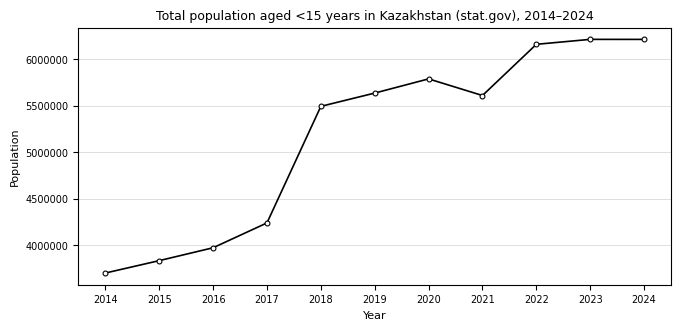

,year,total
0,2014,3697221
1,2015,3830905
2,2016,3969649
3,2017,4237374
4,2018,5493678
5,2019,5636761
6,2020,5789533
7,2021,5610489
8,2022,6162235
9,2023,6215458


In [ ]:
# ============================================================
# Figure S4. Total population of Kazakhstan (stat.gov), 2014–2024
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - sized to final 2-column width
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FIG_NUM = 1
OUT_BASE = f"Figure_{FIG_NUM}_Kazakhstan_Total_Population_2014_2024"

# 2-column width (Cambridge typical): ~174 mm
FIG_WIDTH_MM = 174
FIG_HEIGHT_MM = 85  # adjust if you want taller/shorter
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)

DPI_TIFF = 800

YEAR_COL = "year"
TOTAL_COL = "total"   # keep legacy name; if you use 'population', change here

# ----------------------------
# 1) Aggregate official population for each year (national)
# ----------------------------
pop_nat = (
    gov_pop_clean
    .loc[gov_pop_clean["region_std"] != "Kazakhstan"]
    .groupby(YEAR_COL, as_index=False)[TOTAL_COL]
    .sum()
    .sort_values(YEAR_COL)
)

# ----------------------------
# 2) Plot
# ----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    pop_nat[YEAR_COL].astype(int).values,
    pop_nat[TOTAL_COL].astype(float).values,
    marker="o",
    markersize=3.5,
    linewidth=1.2,
    color="0.0",          # black line
    markerfacecolor="1.0",# white fill
    markeredgecolor="0.0",
    markeredgewidth=0.8,
)

ax.set_title("Total population aged <15 years in Kazakhstan (stat.gov), 2014–2024", pad=6)
ax.set_xlabel("Year")
ax.set_ylabel("Population")

# X ticks: every year, tight but readable at 2-column width
years = pop_nat[YEAR_COL].astype(int).values
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=0)

# Y formatting: show millions with thin grid
ax.grid(axis="y", color="0.85", linewidth=0.6)
ax.grid(False, axis="x")

# Use plain numbers (no scientific notation)
ax.ticklabel_format(axis="y", style="plain")
ax.get_yaxis().get_offset_text().set_visible(False)

# Tight layout for final size
fig.tight_layout()

# ----------------------------
# 3) Export (Cambridge requirements)
# ----------------------------
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")

plt.show()

pop_nat


In [ ]:
# Exclude the explicit national total and any empty names
mask_regions = (
    gov_pop["region_std"].notna()
    & (gov_pop["region_std"] != "")
    & (gov_pop["region_std"] != "Kazakhstan")
)

pop_nat_full = (
    gov_pop[mask_regions]
    .groupby("year")["total"]
    .sum()
    .reset_index()
    .sort_values("year")
)

pop_nat_full


,year,total
0,2014,3697221
1,2015,3830905
2,2016,3969649
3,2017,4237374
4,2018,5493678
5,2019,5636761
6,2020,5789533
7,2021,5610489
8,2022,6162235
9,2023,6215458


In [ ]:
nat_rows = gov_pop[gov_pop["region_std"] == "Kazakhstan"][["year", "total"]]

pop_check = pop_nat_full.merge(
    nat_rows,
    on="year",
    how="left",
    suffixes=("_sum_regions", "_national_row")
)

pop_check


,year,total_sum_regions,total_national_row
0,2014,3697221,4682089
1,2015,3830905,4848138
2,2016,3969649,5019006
3,2017,4237374,5340822
4,2018,5493678,5493678
5,2019,5636761,5636761
6,2020,5789533,5789533
7,2021,5610489,6069233
8,2022,6162235,6162235
9,2023,6215458,6215458


# Missing data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214904 entries, 1031 to 550602
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    214904 non-null  int64  
 1   registry_year         214904 non-null  int64  
 2   birth_date            214904 non-null  object 
 3   diagnosis_date        214904 non-null  object 
 4   age_at_diag_final     214904 non-null  float64
 5   age_exam_reported     214904 non-null  int64  
 6   age_diagnosis         214904 non-null  int64  
 7   sex                   214904 non-null  object 
 8   city                  214904 non-null  object 
 9   location_type         214904 non-null  object 
 10  ethnicity             214904 non-null  object 
 11  citizenship_clean     214904 non-null  object 
 12  ses                   214904 non-null  object 
 13  main_diagnosis        214904 non-null  object 
 14  disorder_category     214904 non-null  object 
 15  sp

In [ ]:
# ============================================
# FULL REGISTRY CODING QUALITY AUDIT
# ============================================

audit_cols = [
    "sex",
    "sex_std",
    "ethnicity",
    "ethnicity_std",
    "citizenship_clean",
    "ses",
    "ses_std",
    "SES_group",
    "specialist",
    "specialist_group",
    "region_std",
    "city",
    "location_type",
    "age_exam_reported",
    "age_at_diag_final",
    "main_diagnosis",
    "disorder_category",
    "comorbidities",
]

unknown_terms = [
    "unknown",
    "not reported",
    "other/unknown",
    "unspecified",
    "none",
    "nan",
    "",
    "0"
]

summary_rows = []

for col in audit_cols:

    s = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    unknown_mask = s.isin(unknown_terms)

    n_total = len(df)
    n_unknown = unknown_mask.sum()

    summary_rows.append({
        "variable": col,
        "dtype": str(df[col].dtype),
        "n_unique": df[col].nunique(dropna=False),
        "n_unknown": n_unknown,
        "pct_unknown": round(100 * n_unknown / n_total, 2),
        "top_values": (
            df[col]
            .astype(str)
            .value_counts(dropna=False)
            .head(5)
            .to_dict()
        )
    })

audit_df = pd.DataFrame(summary_rows)

audit_df = audit_df.sort_values(
    ["pct_unknown", "n_unique"],
    ascending=[False, False]
)

print(audit_df)

audit_df.to_excel(
    "registry_quality_audit.xlsx",
    index=False
)

             variable    dtype  n_unique  n_unknown  pct_unknown  \
17      comorbidities   object       105     212114        98.70   
2           ethnicity   object        67      79557        37.02   
3       ethnicity_std   object        67      79557        37.02   
4   citizenship_clean   object         2      25743        11.98   
8          specialist   object        83       2272         1.06   
9    specialist_group   object         9       2272         1.06   
14  age_at_diag_final  float64      1561          0         0.00   
11               city   object       159          0         0.00   
15     main_diagnosis   object        63          0         0.00   
10         region_std   object        20          0         0.00   
5                 ses   object        17          0         0.00   
6             ses_std   object        17          0         0.00   
13  age_exam_reported    int64        16         10         0.00   
7           SES_group   object         5        

# Incidences

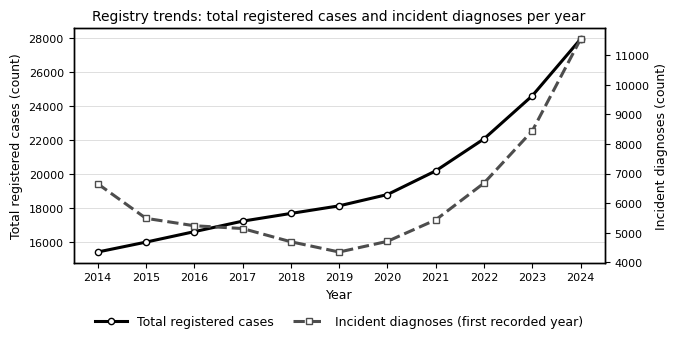

,registry_year,n_total_cases,n_new_dx
0,2014,15438,6655
1,2015,16020,5489
2,2016,16635,5239
3,2017,17252,5145
4,2018,17706,4699
5,2019,18153,4353
6,2020,18817,4713
7,2021,20209,5438
8,2022,22090,6678
9,2023,24626,8440


In [ ]:
# ============================================================
# Figure S3. Registry trends:
# Total registered cases vs first-time (new) diagnoses per year
#
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - sized to final 2-column width
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FIG_NUM = 3
OUT_BASE = f"Figure_{FIG_NUM}_Registry_Trends_Total_vs_NewDx_u15"

FIG_WIDTH_MM  = 174
FIG_HEIGHT_MM = 90
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

YEAR_COL = "registry_year"
ID_COL = "id"                    # person identifier
DXDATE_COL = "diagnosis_date"    # must be sortable (datetime preferred)

# ----------------------------
# 1) Ensure diagnosis_date is datetime
# ----------------------------
d = df.copy()
d[DXDATE_COL] = pd.to_datetime(d[DXDATE_COL], errors="coerce")

# ----------------------------
# 2) Total cases per year
# ----------------------------
cases_year = (
    d.groupby(YEAR_COL)
     .size()
     .rename("n_total_cases")
     .reset_index()
)

# ----------------------------
# 3) New diagnoses per year (first diagnosis per person)
# ----------------------------
first_dx = (
    d.sort_values(DXDATE_COL)
     .groupby(ID_COL, as_index=False)
     .first()
)

new_dx_year = (
    first_dx.groupby(YEAR_COL)
            .size()
            .rename("n_new_dx")
            .reset_index()
)

# ----------------------------
# 4) Merge for plotting (fill missing with 0)
# ----------------------------
trend = (
    cases_year.merge(new_dx_year, on=YEAR_COL, how="left")
              .sort_values(YEAR_COL)
)
trend["n_new_dx"] = trend["n_new_dx"].fillna(0).astype(int)

# ----------------------------
# 5) Plot (grayscale, dual axis)
# ----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.2,   # >= 2 pt
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

fig, ax1 = plt.subplots(figsize=FIGSIZE)

years = trend[YEAR_COL].astype(int).values

# Axis 1: total cases
ax1.plot(
    years, trend["n_total_cases"].values,
    marker="o",
    markersize=4.5,
    linewidth=2.2,
    color="black",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.0,
    label="Total registered cases",
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total registered cases (count)")
ax1.set_xticks(years)

ax1.grid(axis="y", color="0.85", linewidth=0.6)
ax1.grid(False, axis="x")

# Axis 2: new diagnoses
ax2 = ax1.twinx()
ax2.plot(
    years, trend["n_new_dx"].values,
    marker="s",
    markersize=4.5,
    linewidth=2.2,
    linestyle="--",
    color="0.3",
    markerfacecolor="white",
    markeredgecolor="0.3",
    markeredgewidth=1.0,
    label="Incident diagnoses (first recorded year)",
)
ax2.set_ylabel("Incident diagnoses (count)")

ax1.set_title(
    "Registry trends: total registered cases and incident diagnoses per year",
    pad=6
)

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

fig.legend(
    h1 + h2, l1 + l2,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03),
    handlelength=2.5,
    columnspacing=1.6,
)

fig.tight_layout(rect=[0, 0.1, 1, 1])

# Export (Frontiers)
fig.savefig(
    f"{OUT_BASE}.tif",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

# Optional preview
fig.savefig(f"{OUT_BASE}.pdf", bbox_inches="tight")

plt.show()

trend


In [ ]:
from google.colab import files
files.download(f"{OUT_BASE}.tif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

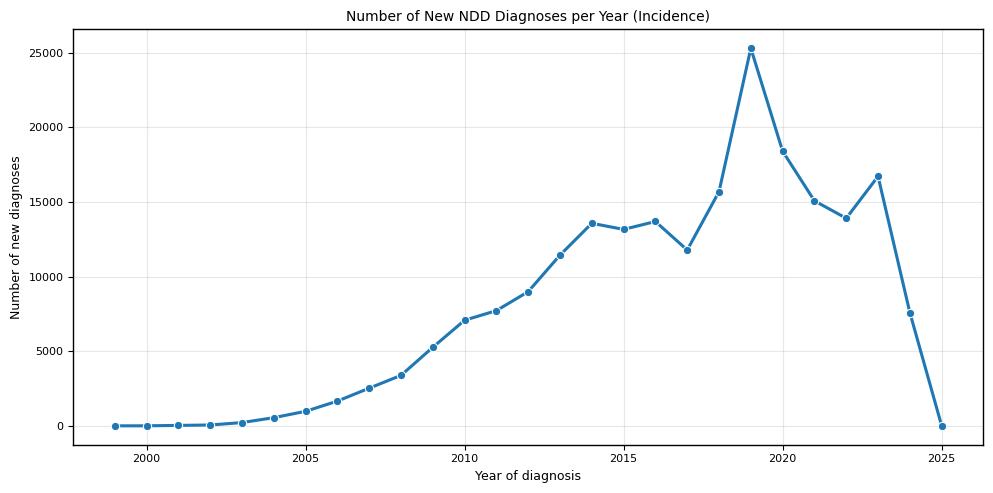

In [ ]:
# 1. Extract year of diagnosis
df["diagnosis_date"] = pd.to_datetime(df["diagnosis_date"], errors="coerce")
df["diagnosis_year"] = df["diagnosis_date"].dt.year

# 2. Drop missing years
df_inc = df.dropna(subset=["diagnosis_year"]).copy()
df_inc["diagnosis_year"] = df_inc["diagnosis_year"].astype(int)

# 3. Count new diagnoses per year
inc_year = (
    df_inc.groupby("diagnosis_year")
          .size()
          .rename("n_new_diagnoses")
          .reset_index()
)

# 4. Plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=inc_year,
    x="diagnosis_year",
    y="n_new_diagnoses",
    marker="o"
)
plt.title("Number of New NDD Diagnoses per Year (Incidence)")
plt.xlabel("Year of diagnosis")
plt.ylabel("Number of new diagnoses")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


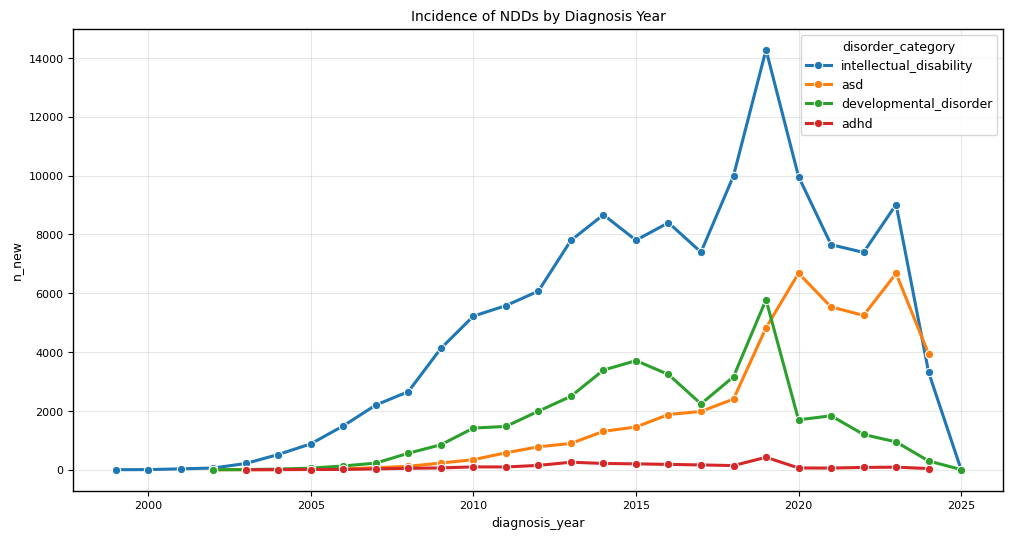

In [ ]:
inc_disorder = (
    df_inc.groupby(["diagnosis_year", "disorder_category"])
          .size()
          .reset_index(name="n_new")
)

plt.figure(figsize=(12,6))
sns.lineplot(data=inc_disorder, x="diagnosis_year", y="n_new", hue="disorder_category", marker="o")
plt.title("Incidence of NDDs by Diagnosis Year")
plt.grid(True, alpha=0.3)
plt.show()


# NDD Plots

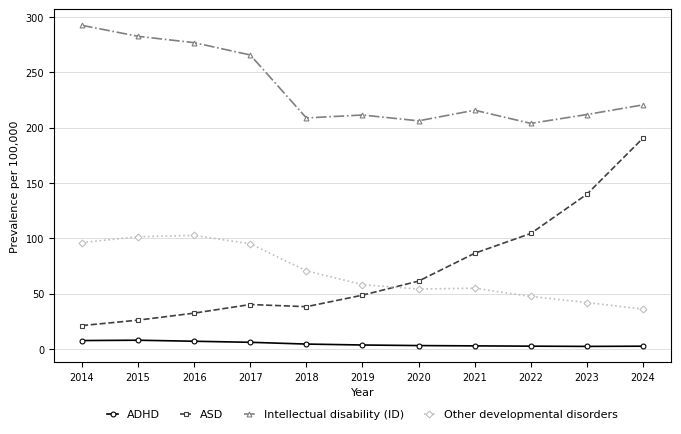

In [ ]:
# ============================================================
# Figure S2. National prevalence by diagnostic group (per 100,000)
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - final size: 2-column width
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FIG_NUM = 4
OUT_BASE = f"Figure_{FIG_NUM}_National_Prevalence_by_Group_u15"

FIG_WIDTH_MM  = 174
FIG_HEIGHT_MM = 122
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

YEAR_COL = "registry_year"
DISORDER_COL = "disorder_category"
Y_COL = "prevalence_per_100k"

# Desired order
DISORDER_ORDER = ["adhd", "asd", "intellectual_disability", "developmental_disorder"]

# Labels for legend
DISORDER_LABELS = {
    "adhd": "ADHD",
    "asd": "ASD",
    "intellectual_disability": "Intellectual disability (ID)",
    "developmental_disorder": "Other developmental disorders",
}

# Grayscale styling
STYLE = {
    "adhd": dict(color="0.0",  linestyle="-",  marker="o"),
    "asd": dict(color="0.25", linestyle="--", marker="s"),
    "intellectual_disability": dict(color="0.5", linestyle="-.", marker="^"),
    "developmental_disorder": dict(color="0.75", linestyle=":", marker="D"),
}

# ----------------------------
# 1) Validate nat_ndd structure
# ----------------------------
need = {YEAR_COL, DISORDER_COL, Y_COL}
missing = need - set(nat_ndd.columns)
if missing:
    raise KeyError(f"nat_ndd missing required columns: {missing}. Available: {list(nat_ndd.columns)}")

plot_df = nat_ndd.copy()
plot_df[YEAR_COL] = plot_df[YEAR_COL].astype(int)
plot_df = plot_df.sort_values([DISORDER_COL, YEAR_COL])

# ----------------------------
# 2) Plot
# ----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

fig, ax = plt.subplots(figsize=FIGSIZE)

years_all = np.sort(plot_df[YEAR_COL].unique())
ax.set_xticks(years_all)

for key in DISORDER_ORDER:
    sub = plot_df[plot_df[DISORDER_COL] == key]
    if sub.empty:
        continue

    st = STYLE.get(key, dict(color="0.0", linestyle="-", marker="o"))
    ax.plot(
        sub[YEAR_COL].values,
        sub[Y_COL].values,
        linewidth=1.2,
        markersize=3.5,
        markerfacecolor="1.0",
        markeredgewidth=0.8,
        label=DISORDER_LABELS.get(key, key),
        **st,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Prevalence per 100,000")

# Grid: y only, light
ax.grid(axis="y", color="0.85", linewidth=0.6)
ax.grid(False, axis="x")

# Plain y tick labels
ax.ticklabel_format(axis="y", style="plain")
ax.get_yaxis().get_offset_text().set_visible(False)

# Legend
ax.legend(
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.19),
    handlelength=1.0,
    columnspacing=1.8,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])

# ----------------------------
# 3) Export
# ----------------------------
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")

plt.show()


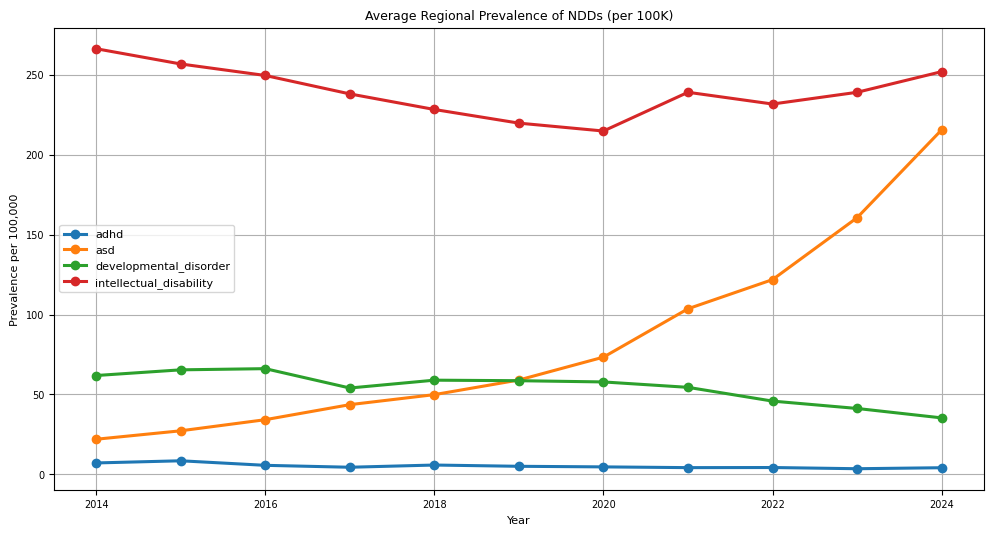

In [ ]:
region_avg = (
    ndd_prev.groupby(["registry_year", "disorder_category"])["prevalence_per_100k"]
            .mean()
            .reset_index()
)

plt.figure(figsize=(12, 6))

for disorder in region_avg["disorder_category"].unique():
    sub = region_avg[region_avg["disorder_category"] == disorder]
    plt.plot(sub["registry_year"], sub["prevalence_per_100k"], marker="o", label=disorder)

plt.title("Average Regional Prevalence of NDDs (per 100K)")
plt.ylabel("Prevalence per 100,000")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()


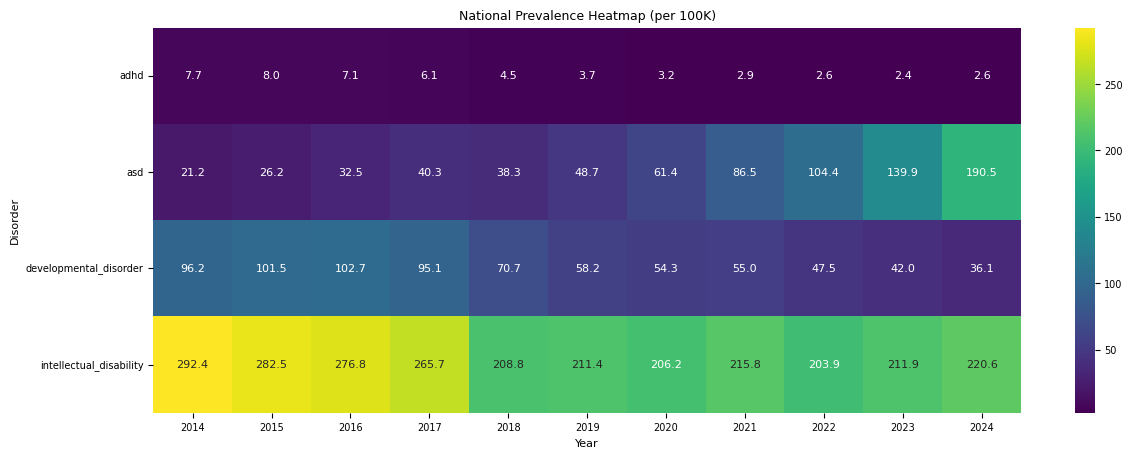

In [ ]:
heat = nat_ndd.pivot(
    index="disorder_category",
    columns="registry_year",
    values="prevalence_per_100k"
)

plt.figure(figsize=(14, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="viridis")
plt.title("National Prevalence Heatmap (per 100K)")
plt.xlabel("Year")
plt.ylabel("Disorder")
plt.show()


# Regions graphs

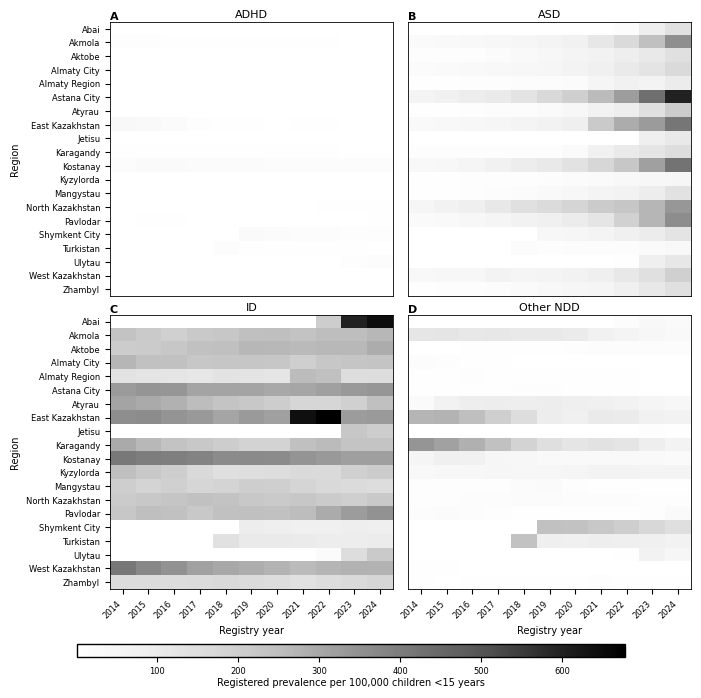

In [ ]:
# ============================================================
# Figure S1. Regional time series of registered prevalence (per 100,000)
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - final size: 2-column width
# ============================================================

PREV_TBL = ndd_prev
DISORDER_RECODE = {"tic_disorder": "developmental_disorder"}  # combine tics -> Other NDD

PANELS = [
    ("adhd", "ADHD"),
    ("asd", "ASD"),
    ("intellectual_disability", "ID"),
    ("developmental_disorder", "Other NDD"),
]

FIG_WIDTH_MM  = 174
FIG_HEIGHT_MM = 160
INCH_PER_MM = 1 / 25.4
fig_w = FIG_WIDTH_MM * INCH_PER_MM
fig_h = FIG_HEIGHT_MM * INCH_PER_MM

DPI_TIFF = 800
OUT_BASE = "Figure_Heatmap_RegionalPrev_u15_4panel"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

need = {"region_std", "registry_year", "disorder_category", "prevalence_per_100k"}
missing = need - set(PREV_TBL.columns)
if missing:
    raise KeyError(f"PREV_TBL missing required columns: {missing}. Available: {list(PREV_TBL.columns)}")

prev = PREV_TBL.copy()
prev["disorder_plot"] = prev["disorder_category"].replace(DISORDER_RECODE)

years = np.sort(prev["registry_year"].unique())
regions = sorted(prev["region_std"].dropna().unique())

vals = prev["prevalence_per_100k"].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
vmin = float(vals.min()) if len(vals) else 0.0
vmax = float(vals.max()) if len(vals) else 1.0

fig, axes = plt.subplots(2, 2, figsize=(fig_w, fig_h), constrained_layout=True)
axes = axes.flatten()

panel_letters = ["A", "B", "C", "D"]
mappable = None

for i, (code, title) in enumerate(PANELS):
    ax = axes[i]

    sub = prev.loc[
        prev["disorder_plot"] == code,
        ["region_std", "registry_year", "prevalence_per_100k"]
    ].copy()

    pivot = (
        sub.pivot_table(
            index="region_std",
            columns="registry_year",
            values="prevalence_per_100k",
            aggfunc="mean",
        )
        .reindex(index=regions, columns=years)
    )

    mat = pivot.to_numpy(dtype=float)

    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        cmap="Greys",
    )
    mappable = im

    ax.set_title(title, pad=3)

    ax.text(
        0.0, 1, panel_letters[i],
        transform=ax.transAxes,
        va="bottom", ha="left",
        fontsize=8, fontweight="bold",
        clip_on=False,
    )

    ax.set_xticks(np.arange(len(years)))

    if i in (0, 1):
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)
    else:
        ax.set_xticklabels(years, rotation=45, ha="right")
        ax.set_xlabel("Registry year")

    ax.set_yticks(np.arange(len(regions)))

    if i % 2 == 0:
        ax.set_yticklabels(regions)
        ax.set_ylabel("Region")
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", which="both", left=False)

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)


fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)

cax = fig.add_axes([0.1, -0.03, 0.80, 0.02])
cbar = fig.colorbar(mappable, cax=cax, orientation="horizontal")
cbar.set_label("Registered prevalence per 100,000 children <15 years", labelpad=2)

fig.savefig(f"{OUT_BASE}.tif", format="tiff", dpi=DPI_TIFF)
plt.show()


# Table ICD-level

In [ ]:
ICD10_NAMES = {

    # ---------- Intellectual Disability ----------
    "F70":   "Mild intellectual disability",
    "F70.0": "Mild intellectual disability, without behavioral impairment",
    "F70.1": "Mild intellectual disability, with behavioral impairment",
    "F70.8": "Mild intellectual disability, other specified",
    "F70.9": "Mild intellectual disability, unspecified",

    "F71":   "Moderate intellectual disability",
    "F71.0": "Moderate intellectual disability, without behavioral impairment",
    "F71.1": "Moderate intellectual disability, with behavioral impairment",
    "F71.8": "Moderate intellectual disability, other specified",
    "F71.9": "Moderate intellectual disability, unspecified",

    "F72":   "Severe intellectual disability",
    "F72.0": "Severe intellectual disability, without behavioral impairment",
    "F72.1": "Severe intellectual disability, with behavioral impairment",
    "F72.8": "Severe intellectual disability, other specified",
    "F72.9": "Severe intellectual disability, unspecified",

    "F73":   "Profound intellectual disability",
    "F73.0": "Profound intellectual disability, without behavioral impairment",
    "F73.1": "Profound intellectual disability, with behavioral impairment",
    "F73.8": "Profound intellectual disability, other specified",
    "F73.9": "Profound intellectual disability, unspecified",

    "F78":   "Other intellectual disability",
    "F78.0": "Other intellectual disability, without behavioral impairment",
    "F78.1": "Other intellectual disability, with behavioral impairment",
    "F78.8": "Other intellectual disability, other specified",
    "F78.9": "Other intellectual disability, unspecified",

    "F79":   "Unspecified intellectual disability",
    "F79.0": "Unspecified intellectual disability, without behavioral impairment",
    "F79.1": "Unspecified intellectual disability, with behavioral impairment",
    "F79.8": "Unspecified intellectual disability, other specified",
    "F79.9": "Unspecified intellectual disability, unspecified",

    # ---------- Speech & Learning Disorders ----------
    "F80":   "Specific developmental disorders of speech and language",
    "F80.0": "Phonological disorder",
    "F80.1": "Expressive language disorder",
    "F80.2": "Receptive language disorder",
    "F80.3": "Acquired aphasia with epilepsy",
    "F80.8": "Other speech and language disorders",
    "F80.9": "Speech and language disorder, unspecified",

    "F81":   "Specific developmental disorders of scholastic skills",
    "F81.0": "Specific reading disorder (dyslexia)",
    "F81.1": "Specific spelling disorder",
    "F81.2": "Specific disorder of arithmetical skills (dyscalculia)",
    "F81.3": "Mixed disorder of scholastic skills",
    "F81.8": "Other scholastic skill disorders",
    "F81.9": "Scholastic disorder, unspecified",

    "F82":   "Specific developmental disorder of motor function",
    "F83":   "Mixed specific developmental disorders",

    "F88":   "Other disorders of psychological development",
    "F89":   "Unspecified disorder of psychological development",

    # ---------- Autism Spectrum Disorders ----------
    "F84":   "Pervasive developmental disorders",
    "F84.0": "Childhood autism",
    "F84.1": "Atypical autism",
    "F84.2": "Rett syndrome",
    "F84.3": "Other childhood disintegrative disorder",
    "F84.4": "Overactive disorder with intellectual disability",
    "F84.5": "Asperger syndrome",
    "F84.8": "Other pervasive developmental disorders",
    "F84.9": "Pervasive developmental disorder, unspecified",

    # ---------- ADHD ----------
    "F90":   "Attention-deficit hyperactivity disorder",
    "F90.0": "ADHD, predominantly inattentive",
    "F90.1": "ADHD, predominantly hyperactive/impulsive",
    "F90.8": "Other ADHD",
    "F90.9": "ADHD, unspecified",

    # ---------- Tic Disorders ----------
    "F95":   "Tic disorders",
    "F95.0": "Transient tic disorder",
    "F95.1": "Chronic motor or vocal tic disorder",
    "F95.2": "Tourette syndrome",
    "F95.8": "Other tic disorders",
    "F95.9": "Tic disorder, unspecified",
}


In [ ]:
DISORDER_LABELS = {
    "asd": "Autism spectrum disorder (ASD)",
    "adhd": "Attention-deficit/hyperactivity disorder (ADHD)",
    "intellectual_disability": "Intellectual disability (ID)",
    "developmental_disorder": "Other developmental disorders",
}

SPECIALIST_LABELS = {
    "psychiatrist": "Psychiatrist",
    "neurologist": "Neurologist",
    "pediatrician": "Paediatrician",
    "gp_family": "Family physician",
    "psychologist": "Psychologist",
    "public_health": "Public health physician",
    "nurse_midlevel": "Nurse / mid-level practitioner",
    "other_physician": "Other physician",
    "unknown": "Unknown",
}

In [ ]:
# ==============================
# A) BASE FILTERING
# ==============================

desc_df = df.copy()

# Children only
desc_df = desc_df.loc[desc_df["age_exam_reported"] < 18].copy()

# Keep only rows with a main diagnosis
desc_df = desc_df.dropna(subset=["main_diagnosis"])

# Total N for percentage calculation
TOTAL_N = len(desc_df)

# Dictionary
desc_df["Diagnosis"] = (
    desc_df["main_diagnosis"]
    .map(ICD10_NAMES)
    .fillna("Other / unspecified")
    + " (" + desc_df["main_diagnosis"] + ")"
)
desc_df["disorder_label"] = desc_df["disorder_category"].map(DISORDER_LABELS).fillna(desc_df["disorder_category"])
desc_df["specialist_label"] = desc_df["specialist_group"].map(SPECIALIST_LABELS).fillna(desc_df["specialist_group"])



# ==============================
# B) HELPER FUNCTIONS
# ==============================

def median_iqr(x):
    x = x.dropna()
    if len(x) == 0:
        return "NA"
    return f"{np.median(x):.1f} ({np.percentile(x,25):.1f}–{np.percentile(x,75):.1f})"

def median_iqr_year(x):
    x = x.dropna()
    if len(x) == 0:
        return "NA"
    return f"{int(np.median(x))} ({int(np.percentile(x,25))}–{int(np.percentile(x,75))})"

def top_category(series, exclude=None):
    if exclude is None:
        exclude = []

    s = series.dropna()
    if len(s) == 0:
        return "NA"

    # Drop excluded labels
    s = s[~s.isin(exclude)]
    if len(s) == 0:
        return "NA"

    vc = s.value_counts(normalize=True)
    label = vc.index[0]
    pct = vc.iloc[0] * 100
    return f"{label} ({pct:.1f}%)"


# ==============================
# C) BUILD DESCRIPTIVE TABLE
# ==============================

table_desc = (
    desc_df
    .groupby("Diagnosis")
    .agg(
        Diagnosis_group=("disorder_label", lambda x: x.iloc[0]),
        N=("Diagnosis", "size"),
        percent_all=("Diagnosis", lambda x: 100 * len(x) / TOTAL_N),
        age_diag=("age_at_diag_final", median_iqr),
        diagnosis_year=("diagnosis_year", median_iqr_year),
        age=("age_exam_reported", median_iqr),
        male_pct=("sex_std", lambda x: 100 * (x == "Male").mean()),
        top_specialist=("specialist_label", top_category),
        top_region=("region_std", top_category),
        top_ses=("SES_group", lambda x: top_category(x, exclude=["Other"])),
        top_ethnicity=("ethnicity_std", lambda x: top_category(x, exclude=["Not reported"])),
        citizen_pct=("citizenship_clean", lambda x: 100 * (x == "kazakhstan").mean()),
        urban_pct=("location_type", lambda x: 100 * (x == "city").mean()),

    )
    .reset_index()
)

# Formatting
table_desc["percent_all"] = table_desc["percent_all"].round(2)
table_desc["male_pct"] = table_desc["male_pct"].round(1)
table_desc["citizen_pct"] = table_desc["citizen_pct"].round(1)
table_desc["urban_pct"] = table_desc["urban_pct"].round(1)
table_desc["diagnosis_year"] = table_desc["diagnosis_year"].round(0)

table_desc = table_desc.rename(columns={
    "Diagnosis": "Primary diagnosis (ICD-10)",
    "Diagnosis_group": "Diagnostic group",
    "N": "N (children)",
    "percent_all": "% of total sample",
    "age_diag": "Age at diagnosis, years (median [IQR])",
    "diagnosis_year": "Year of diagnosis (median [IQR])",
    "age": "Age at assessment, years (median [IQR])",
    "male_pct": "Male, %",
    "top_specialist": "Most frequent diagnosing specialist (share, %)",
    "top_region": "Most frequent region (share, %)",
    "top_ses": "Most frequent socioeconomic status (share, %)",
    "top_ethnicity": "Most frequent ethnicity (share, %)",
    "citizen_pct": "Kazakhstan citizenship, %",
    "urban_pct": "Urban residence, %",
})

# Sort by frequency
table_desc = table_desc.sort_values("N (children)", ascending=False)
pd.set_option("display.max_rows", None)
table_desc


,Primary diagnosis (ICD-10),Diagnostic group,N (children),% of total sample,"Age at diagnosis, years (median [IQR])",Year of diagnosis (median [IQR]),"Age at assessment, years (median [IQR])","Male, %","Most frequent diagnosing specialist (share, %)","Most frequent region (share, %)","Most frequent socioeconomic status (share, %)","Most frequent ethnicity (share, %)","Kazakhstan citizenship, %","Urban residence, %"
13,"Mild intellectual disability, without behavior...",Intellectual disability (ID),28704,13.36,8.2 (6.2–10.4),2016 (2013–2019),11.0 (9.0–14.0),58.9,Psychiatrist (36.2%),Almaty City (12.0%),Out-of-home care (52.1%),Kazakh (67.8%),87.1,45.9
6,Childhood autism (F84.0),Autism spectrum disorder (ASD),27053,12.59,5.5 (4.4–7.2),2020 (2019–2022),7.0 (5.0–10.0),78.2,Psychiatrist (56.7%),Astana City (29.1%),Home care (40.1%),Kazakh (75.1%),89.2,48.1
20,"Moderate intellectual disability, without beha...",Intellectual disability (ID),22924,10.67,7.0 (5.3–9.4),2016 (2012–2019),11.0 (8.0–13.0),58.1,Psychiatrist (34.8%),Atyrau (11.6%),Home care (43.5%),Kazakh (72.2%),88.5,49.7
12,"Mild intellectual disability, with behavioral ...",Intellectual disability (ID),21561,10.03,8.2 (6.4–10.5),2018 (2014–2021),11.0 (9.0–13.0),66.5,Psychiatrist (44.8%),Almaty Region (15.2%),Out-of-home care (46.8%),Kazakh (67.6%),87.6,38.6
15,Mixed specific developmental disorders (F83),Other developmental disorders,17441,8.12,6.5 (4.5–8.3),2017 (2014–2019),9.0 (7.0–11.0),67.6,Family physician (31.3%),East Kazakhstan (22.5%),Out-of-home care (43.7%),Kazakh (52.6%),84.4,57.7
19,"Moderate intellectual disability, with behavio...",Intellectual disability (ID),17360,8.08,7.0 (5.4–9.4),2018 (2013–2021),11.0 (8.0–13.0),64.9,Psychiatrist (50.9%),Turkistan (13.0%),Home care (45.5%),Kazakh (72.0%),90.0,55.6
5,Atypical autism (F84.1),Autism spectrum disorder (ASD),15918,7.41,6.3 (5.0–7.9),2020 (2018–2022),8.0 (6.0–10.0),78.3,Psychiatrist (43.5%),Almaty City (24.6%),Home care (41.8%),Kazakh (69.8%),83.9,38.8
48,"Severe intellectual disability, without behavi...",Intellectual disability (ID),13758,6.40,6.6 (4.7–9.2),2016 (2012–2019),11.0 (8.0–13.0),58.9,Psychiatrist (33.0%),Astana City (13.7%),Home care (66.4%),Kazakh (73.9%),88.2,55.4
35,Phonological disorder (F80.0),Other developmental disorders,11206,5.21,5.9 (4.5–7.5),2016 (2014–2019),9.0 (6.0–11.0),66.7,Family physician (35.4%),Turkistan (64.5%),Out-of-home care (48.1%),Kazakh (66.9%),93.2,82.6
47,"Severe intellectual disability, with behaviora...",Intellectual disability (ID),6281,2.92,7.0 (5.1–10.1),2017 (2012–2020),11.0 (9.0–13.0),63.2,Psychiatrist (46.1%),Turkistan (12.8%),Home care (64.7%),Kazakh (72.5%),90.1,53.0


In [ ]:
# ==============================
# Grouped descriptive table (Diagnosis groups as COLUMNS)
# - Applies all corrections from the overall table:
#   * publication labels for disorder_category and specialists
#   * NA-safe median(IQR)
#   * integer year formatting for diagnosis year
#   * no median_year; uses diagnosis_year (median [IQR])
#   * adds Top primary diagnosis (share, %)
#   * outputs in "wide" format: rows = metrics, columns = diagnosis groups
# ==============================

# --- Label dictionaries ---
DISORDER_LABELS = {
    "asd": "Autism spectrum disorder (ASD)",
    "adhd": "Attention-deficit/hyperactivity disorder (ADHD)",
    "intellectual_disability": "Intellectual disability (ID)",
    "developmental_disorder": "Other developmental disorders",
}

SPECIALIST_LABELS = {
    "psychiatrist": "Psychiatrist",
    "neurologist": "Neurologist",
    "pediatrician": "Paediatrician",
    "gp_family": "General practitioner / family physician",
    "psychologist": "Psychologist",
    "public_health": "Public health physician",
    "nurse_midlevel": "Nurse / mid-level practitioner",
    "other_physician": "Other physician",
    "unknown": "Unknown",
}

# --- Ensure labeled columns exist in desc_df ---
if "disorder_label" not in desc_df.columns:
    desc_df["disorder_label"] = (
        desc_df["disorder_category"]
        .map(DISORDER_LABELS)
        .fillna(desc_df["disorder_category"])
    )

if "specialist_label" not in desc_df.columns:
    desc_df["specialist_label"] = (
        desc_df["specialist_group"]
        .map(SPECIALIST_LABELS)
        .fillna(desc_df["specialist_group"])
    )

# --- Summary helpers (NA-safe) ---
def median_iqr(x):
    x = x.dropna()
    if len(x) == 0:
        return "NA"
    return f"{np.median(x):.1f} ({np.percentile(x,25):.1f}–{np.percentile(x,75):.1f})"

def median_iqr_year(x):
    x = x.dropna()
    if len(x) == 0:
        return "NA"
    return f"{int(np.median(x))} ({int(np.percentile(x,25))}–{int(np.percentile(x,75))})"

def top_category(series, exclude=None):
    if exclude is None:
        exclude = []

    s = series.dropna()
    if len(s) == 0:
        return "NA"

    # Drop excluded labels
    s = s[~s.isin(exclude)]
    if len(s) == 0:
        return "NA"

    vc = s.value_counts(normalize=True)
    label = vc.index[0]
    pct = vc.iloc[0] * 100
    return f"{label} ({pct:.1f}%)"

# ==============================
# A) Build long grouped table
# ==============================
TOTAL_N = len(desc_df)

table_group_long = (
    desc_df
    .groupby("disorder_label")
    .agg(
        # basic counts
        N=("Diagnosis", "size"),
        percent_all=("Diagnosis", lambda x: 100 * len(x) / TOTAL_N),

        # medians (IQR)
        age_diag=("age_at_diag_final", median_iqr),
        age=("age_exam_reported", median_iqr),
        diagnosis_year=("diagnosis_year", median_iqr_year),

        # proportions
        male_pct=("sex_std", lambda x: 100 * (x == "Male").mean()),
        citizen_pct=("citizenship_clean", lambda x: 100 * (x == "kazakhstan").mean()),
        urban_pct=("location_type", lambda x: 100 * (x == "city").mean()),

        # "top" categories
        top_primary_dx=("Diagnosis", top_category),
        top_specialist=("specialist_label", top_category),
        top_region=("region_std", top_category),
        top_ses=("SES_group", lambda x: top_category(x, exclude=["Other"])),
        top_ethnicity=("ethnicity_std", lambda x: top_category(x, exclude=["Not reported"])),
    )
    .reset_index()
)

# formatting numeric columns (keep as numbers until wide conversion)
table_group_long["percent_all"] = table_group_long["percent_all"].round(2)
table_group_long["male_pct"] = table_group_long["male_pct"].round(1)
table_group_long["citizen_pct"] = table_group_long["citizen_pct"].round(1)
table_group_long["urban_pct"] = table_group_long["urban_pct"].round(1)

# Sort group columns by size (descending)
table_group_long = table_group_long.sort_values("N", ascending=False)


# ==============================
# B) Rename labels
# ==============================
table_group_long = table_group_long.rename(columns={
    "disorder_label": "Diagnostic group",
    "N": "N (children)",
    "percent_all": "% of total sample",
    "age_diag": "Age at diagnosis, years (median [IQR])",
    "age": "Age at assessment, years (median [IQR])",
    "diagnosis_year": "Year of diagnosis (median [IQR])",
    "male_pct": "Male, %",
    "citizen_pct": "Kazakhstan citizenship, %",
    "urban_pct": "Urban residence, %",
    "top_primary_dx": "Most frequent primary diagnosis (share, %)",
    "top_specialist": "Most frequent diagnosing specialist (share, %)",
    "top_region": "Most frequent region (share, %)",
    "top_ses": "Most frequent socioeconomic status (share, %)",
    "top_ethnicity": "Most frequent ethnicity (share, %)",
})


# ==============================
# C) Swap rows/columns: metrics as rows, diagnosis groups as columns
# ==============================
index_col = "Diagnostic group"

metrics_order = [
    "N (children)",
    "% of total sample",
    "Age at diagnosis, years (median [IQR])",
    "Age at assessment, years (median [IQR])",
    "Year of diagnosis (median [IQR])",
    "Male, %",
    "Kazakhstan citizenship, %",
    "Urban residence, %",
    "Most frequent primary diagnosis (share, %)",
    "Most frequent diagnosing specialist (share, %)",
    "Most frequent region (share, %)",
    "Most frequent socioeconomic status (share, %)",
    "Most frequent ethnicity (share, %)",
]

table_group_wide = (
    table_group_long
    .set_index(index_col)[metrics_order]
    .T
)

# Desired column order
desired_order = [
    "Attention-deficit/hyperactivity disorder (ADHD)",
    "Autism spectrum disorder (ASD)",
    "Intellectual disability (ID)",
    "Other developmental disorders",
]

desired_order = [c for c in desired_order if c in table_group_wide.columns]

table_group_wide = table_group_wide[desired_order]

pd.set_option("display.max_rows", None)
table_group_wide



Diagnostic group,Attention-deficit/hyperactivity disorder (ADHD),Autism spectrum disorder (ASD),Intellectual disability (ID),Other developmental disorders
N (children),2413,45010,130749,36732
% of total sample,1.12,20.94,60.84,17.09
"Age at diagnosis, years (median [IQR])",7.2 (5.7–8.8),5.8 (4.6–7.5),7.5 (5.6–10.0),6.6 (4.7–8.3)
"Age at assessment, years (median [IQR])",10.0 (8.0–12.0),8.0 (6.0–10.0),11.0 (9.0–13.0),9.0 (7.0–12.0)
Year of diagnosis (median [IQR]),2016 (2013–2019),2020 (2018–2022),2017 (2013–2020),2016 (2013–2019)
"Male, %",81.7,78.2,61.3,67.1
"Kazakhstan citizenship, %",80.1,87.4,88.8,86.6
"Urban residence, %",62.0,45.0,47.3,66.6
"Most frequent primary diagnosis (share, %)","ADHD, predominantly inattentive (F90.0) (50.1%)",Childhood autism (F84.0) (60.1%),"Mild intellectual disability, without behavior...",Mixed specific developmental disorders (F83) (...
"Most frequent diagnosing specialist (share, %)",Family physician (38.1%),Psychiatrist (51.6%),Psychiatrist (40.4%),Family physician (29.7%)


In [ ]:
table_desc.to_excel("table_desc.xlsx", index=False)
files.download("table_desc.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Trends NDD

In [ ]:
nat_ts = nat_ndd.copy()
nat_ts["year_c"] = nat_ts["registry_year"] - nat_ts["registry_year"].min()
nat_ts["log_pop"] = np.log(nat_ts["population"])


In [ ]:
results = []

for disorder in nat_ts["disorder_category"].unique():
    dsub = nat_ts[nat_ts["disorder_category"] == disorder]

    model = sm.GLM(
        dsub["n_cases"],
        sm.add_constant(dsub["year_c"]),
        family=sm.families.NegativeBinomial(alpha=1.0),
        offset=dsub["log_pop"]
    ).fit()


    irr = np.exp(model.params["year_c"])
    ci = np.exp(model.conf_int().loc["year_c"])
    pval = model.pvalues["year_c"]

    results.append({
        "Disorder": disorder,
        "IRR per year": irr,
        "95% CI": f"{ci[0]:.3f}–{ci[1]:.3f}",
        "p_value": pval,
    })

trend_table = pd.DataFrame(results)
trend_table


,Disorder,IRR per year,95% CI,p_value
0,adhd,0.873017,0.724–1.053,0.155428
1,asd,1.234928,1.024–1.489,0.026937
2,developmental_disorder,0.895051,0.742–1.079,0.244963
3,intellectual_disability,0.965247,0.801–1.164,0.710670


In [ ]:
model.pearson_chi2 / model.df_resid


np.float64(0.00737777242836118)

# Fig 1

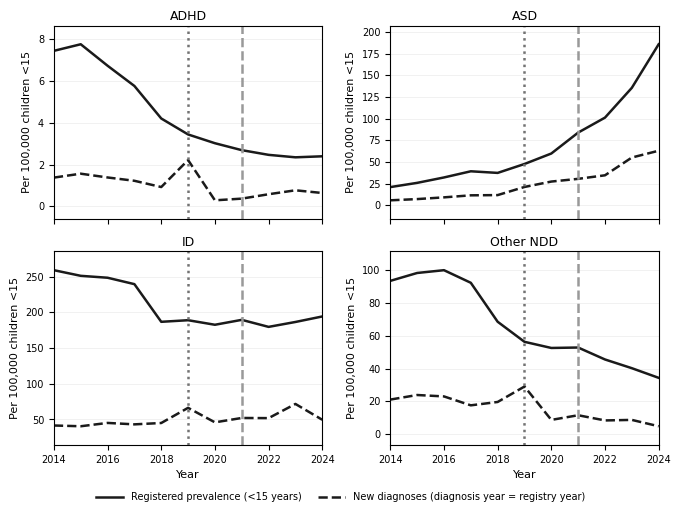

In [ ]:
# ============================================================
# Figure 1. National trends in registry-based prevalence and first-time diagnoses (per 100,000)
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - final size: 2-column width
# ============================================================

df = df.loc[df["age_exam_reported"].notna() & (df["age_exam_reported"] < 15)].copy()

# ----------------------------
# 1) Create diagnosis_year from diagnosis_date
# ----------------------------
df["diagnosis_date_dt"] = pd.to_datetime(df["diagnosis_date"], errors="coerce")
df["diagnosis_year"] = df["diagnosis_date_dt"].dt.year

year_min, year_max = int(df["registry_year"].min()), int(df["registry_year"].max())
df.loc[~df["diagnosis_year"].between(year_min, year_max), "diagnosis_year"] = np.nan

# ----------------------------
# 2) Build denominators from gov_pop_full
# ----------------------------
DENOM_COL = "total" if "total" in gov_pop_full.columns else "population"

mask_regions = gov_pop_full["region_std"] != "Kazakhstan"

nat_pop_ndd = (
    gov_pop_full.loc[mask_regions]
    .groupby("year", as_index=False)[DENOM_COL]
    .sum()
    .rename(columns={"year": "registry_year", DENOM_COL: "total_u15"})
)

# ----------------------------
# 3) National prevalence  by disorder_category
# ----------------------------
nat_ndd_counts = (
    df.groupby(["registry_year", "disorder_category"], observed=True)
      .size()
      .rename("n_cases")
      .reset_index()
)

nat_ndd = nat_ndd_counts.merge(nat_pop_ndd, on="registry_year", how="left", validate="many_to_one")
nat_ndd["prevalence_per_100k"] = nat_ndd["n_cases"] / nat_ndd["total_u15"] * 100000
nat_ndd = nat_ndd[["registry_year", "disorder_category", "n_cases", "total_u15", "prevalence_per_100k"]]

# Keep a separate object name (optional) to mirror your earlier code structure
prev_u15 = nat_ndd.rename(columns={"prevalence_per_100k": "prevalence_u15_per_100k"}).copy()

# ----------------------------
# 4) Incidence proxy: diagnosis_year == registry_year
# ----------------------------
incidence_counts = (
    df.loc[df["diagnosis_year"].notna() & (df["diagnosis_year"] == df["registry_year"])]
      .groupby(["registry_year", "disorder_category"], observed=True)
      .size()
      .rename("n_new_cases")
      .reset_index()
)

incidence = incidence_counts.merge(nat_pop_ndd, on="registry_year", how="left", validate="many_to_one")
incidence["incidence_per_100k"] = incidence["n_new_cases"] / incidence["total_u15"] * 100000
incidence = incidence[["registry_year", "disorder_category", "n_new_cases", "total_u15", "incidence_per_100k"]]

# ----------------------------
# 5) figure styling + export
# ----------------------------
disorders = {
    "adhd": "ADHD",
    "asd": "ASD",
    "intellectual_disability": "ID",
    "developmental_disorder": "Other NDD",
}

FIG_WIDTH_MM  = 174  # ~2-column width
FIG_HEIGHT_MM = 135
INCH_PER_MM = 1 / 25.4
fig_w = FIG_WIDTH_MM * INCH_PER_MM
fig_h = FIG_HEIGHT_MM * INCH_PER_MM

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# Monochrome
STYLE_PREV_U15 = dict(color="0.1", linestyle="-")   # prevalence <15
STYLE_INCID    = dict(color="0.1", linestyle="--")  # incidence proxy

all_years = np.sort(df["registry_year"].unique())

fig, axes = plt.subplots(2, 2, figsize=(fig_w, fig_h), sharex=True)
axes = axes.flatten()

for i, (ax, (code, label)) in enumerate(zip(axes, disorders.items())):
    prev_line = prev_u15.loc[
        prev_u15["disorder_category"] == code,
        ["registry_year", "prevalence_u15_per_100k"]
    ].copy()

    inc_line = incidence.loc[
        incidence["disorder_category"] == code,
        ["registry_year", "incidence_per_100k"]
    ].copy()

    # Reindex to full year range
    prev_line = prev_line.set_index("registry_year").reindex(all_years).reset_index()
    inc_line  = inc_line.set_index("registry_year").reindex(all_years).reset_index()

    ax.plot(
        prev_line["registry_year"],
        prev_line["prevalence_u15_per_100k"],
        label="Registered prevalence (<15 years)",
        **STYLE_PREV_U15
    )

    ax.plot(
        inc_line["registry_year"],
        inc_line["incidence_per_100k"],
        label="New diagnoses (diagnosis year = registry year)",
        **STYLE_INCID
    )

    # ----------------------------
    # POLICY MARKERS
    # ----------------------------

    # 2019 PMPC reform
    ax.axvline(
        2019,
        color="0.45",
        linestyle=":",
        linewidth=1.8
    )

    # 2021 ASD subsidy expansion
    ax.axvline(
        2021,
        color="0.6",
        linestyle="--",
        linewidth=1.8
    )

    ax.set_title(label, pad=4)

    ax.set_title(label, pad=4)
    ax.set_ylabel("Per 100,000 children <15")
    ax.set_xlim(all_years.min(), all_years.max())

    ax.margins(y=0.12)

    ax.grid(True, which="major", axis="y", alpha=0.25, linewidth=0.5)
    ax.grid(False, axis="x")

axes[2].set_xlabel("Year")
axes[3].set_xlabel("Year")

# Single-row legend
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, leg_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.035),
    columnspacing=1.6,
    handlelength=2.8,
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

out_base = "Figure_1_NDD_trends_u15"

fig.savefig(f"{out_base}.eps", format="eps", bbox_inches="tight")
fig.savefig(
    f"{out_base}.tif",
    format="tiff",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


In [ ]:
files.download(f"{out_base}.tif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# NDD Forest IRR

In [ ]:
# =========================
# CONFIG (EDIT HERE)
# =========================
CHILD_AGE_MAX = 15
YEAR_MIN, YEAR_MAX = 2014, 2024

# REQUIRED df columns (must exist):
# region_std, registry_year, disorder_category, age_exam_reported
# sex_std, age_at_diag_final, ethnicity_std, citizenship_clean, location_type, SES_group
SPEC_COL = "specialist_group"  # <-- CHANGE THIS to your real column name (must include dp_family)

DISORDERS = [
    ("adhd", "ADHD"),
    ("asd", "ASD"),
    ("intellectual_disability", "ID"),
    ("developmental_disorder", "Other NDD"),
]

# Ethnicity grouping (EDIT to match your cleaned ethnicity_std values)
CENTRAL_ASIAN = {
    "kazakh", "kyrgyz", "uzbek", "uyghur", "uighur", "tajik", "turkmen", "karakalpak"
}
SLAVIC = {
    "russian", "ukrainian", "belarusian", "polish"
}

# =========================
# 0) Restrict to children <15 + year window
# =========================
data = df.copy()

data = data.loc[data["age_exam_reported"].notna()].copy()
data["age_exam_reported"] = pd.to_numeric(data["age_exam_reported"], errors="coerce")
data = data.loc[data["age_exam_reported"] < CHILD_AGE_MAX].copy()

data = data.loc[data["registry_year"].between(YEAR_MIN, YEAR_MAX)].copy()

# =========================
# 1) Clean key fields to avoid mixed dtypes
# =========================
# sex
data["sex_std"] = data["sex_std"].astype(str)

# age_at_diag_final (numeric)
data["age_at_diag_final"] = pd.to_numeric(data["age_at_diag_final"], errors="coerce")

# citizenship_clean was mixed str/int in your output.
# You said it "only tells whether citizenship is Kazakhstan".
# We force to binary: 1=KZ, 0=non-KZ/other/unknown.
def _is_kz(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    return 1 if ("kaz" in s or "kz" == s or "kazakhstan" in s) else 0

data["cit_kz"] = data["citizenship_clean"].apply(_is_kz)

# location_type: city/rural expected
data["location_type"] = data["location_type"].astype(str).str.strip().str.lower()
data["is_city"] = (data["location_type"].isin(["city", "urban"])).astype(int)

# ethnicity grouping into 3 levels: central_asian / slavic / other
eth = data["ethnicity_std"].astype(str).str.strip().str.lower()
data["eth_group"] = np.where(
    eth.isin(CENTRAL_ASIAN), "Central Asian",
    np.where(eth.isin(SLAVIC), "Slavic", "Other")
)

# SES_group (already grouped by you)
data["SES_group"] = data["SES_group"].astype(str).str.strip()

# Specialist column (must include dp_family as its own value)
if SPEC_COL not in data.columns:
    raise KeyError(f"SPEC_COL='{SPEC_COL}' not found. Available cols: {list(data.columns)}")
data[SPEC_COL] = data[SPEC_COL].astype(str).str.strip().str.lower()

# =========================
# 2) Region-year totals (offset denominator for composition)
# =========================
den = (
    data.groupby(["region_std", "registry_year"], observed=True)
        .size()
        .rename("n_total_registry")
        .reset_index()
)

den["offset_log"] = np.log(den["n_total_registry"].astype(float))

# =========================
# 3) Region-year composition predictors (shares/means)
# =========================
# Sex composition: prop_male
sex_rt = (
    data.assign(is_male=lambda x: (x["sex_std"].str.lower() == "male").astype(int))
        .groupby(["region_std", "registry_year"], observed=True)["is_male"]
        .mean()
        .rename("prop_male")
        .reset_index()
)

# Mean age at diagnosis (region-year)
age_rt = (
    data.groupby(["region_std", "registry_year"], observed=True)["age_at_diag_final"]
        .mean()
        .rename("age_mean")
        .reset_index()
)

# Citizenship: share non-KZ (or KZ share if you prefer)
cit_rt = (
    data.groupby(["region_std", "registry_year"], observed=True)["cit_kz"]
        .mean()
        .rename("prop_kz")
        .reset_index()
)
cit_rt["prop_non_kz"] = 1 - cit_rt["prop_kz"]

# Urbanicity proxy within region-year: share of CITY records
urb_rt = (
    data.groupby(["region_std", "registry_year"], observed=True)["is_city"]
        .mean()
        .rename("prop_city")
        .reset_index()
)

# Ethnicity group shares
eth_ct = (
    data.groupby(["region_std", "registry_year", "eth_group"], observed=True)
        .size().rename("n").reset_index()
)
eth_tot = eth_ct.groupby(["region_std", "registry_year"], observed=True)["n"].sum().rename("tot").reset_index()
eth_ct = eth_ct.merge(eth_tot, on=["region_std","registry_year"], how="left")
eth_ct["share"] = eth_ct["n"] / eth_ct["tot"]

eth_w = eth_ct.pivot_table(
    index=["region_std","registry_year"],
    columns="eth_group",
    values="share",
    fill_value=0.0
).reset_index()

# SES shares
ses_ct = (
    data.groupby(["region_std", "registry_year", "SES_group"], observed=True)
        .size().rename("n").reset_index()
)
ses_tot = ses_ct.groupby(["region_std","registry_year"], observed=True)["n"].sum().rename("tot").reset_index()
ses_ct = ses_ct.merge(ses_tot, on=["region_std","registry_year"], how="left")
ses_ct["share"] = ses_ct["n"] / ses_ct["tot"]

ses_w = ses_ct.pivot_table(
    index=["region_std","registry_year"],
    columns="SES_group",
    values="share",
    fill_value=0.0
).reset_index()

# Specialist shares (dp_family separated automatically if it exists as a category)
spec_ct = (
    data.groupby(["region_std", "registry_year", SPEC_COL], observed=True)
        .size().rename("n").reset_index()
)
spec_tot = spec_ct.groupby(["region_std","registry_year"], observed=True)["n"].sum().rename("tot").reset_index()
spec_ct = spec_ct.merge(spec_tot, on=["region_std","registry_year"], how="left")
spec_ct["share"] = spec_ct["n"] / spec_ct["tot"]

spec_w = spec_ct.pivot_table(
    index=["region_std","registry_year"],
    columns=SPEC_COL,
    values="share",
    fill_value=0.0
).reset_index()

# =========================
# 4) Merge into one region-year table of predictors
# =========================
X = den.merge(sex_rt, on=["region_std","registry_year"], how="left")
X = X.merge(age_rt, on=["region_std","registry_year"], how="left")
X = X.merge(cit_rt[["region_std","registry_year","prop_non_kz"]], on=["region_std","registry_year"], how="left")
X = X.merge(urb_rt, on=["region_std","registry_year"], how="left")
X = X.merge(eth_w, on=["region_std","registry_year"], how="left")
X = X.merge(ses_w, on=["region_std","registry_year"], how="left")
X = X.merge(spec_w, on=["region_std","registry_year"], how="left")

# Center continuous predictors (improves sampling)
X["year_c"] = X["registry_year"].astype(float) - X["registry_year"].astype(float).mean()
X["age_mean_c"] = X["age_mean"] - X["age_mean"].mean()

# =========================
# 5) Build per-disorder counts (region-year) and merge predictors
# =========================
counts = (
    data.groupby(["region_std","registry_year","disorder_category"], observed=True)
        .size().rename("n_cases").reset_index()
)

# Keep only your 4 disorders
keep_codes = [d[0] for d in DISORDERS]
counts = counts[counts["disorder_category"].isin(keep_codes)].copy()

agg = counts.merge(X, on=["region_std","registry_year"], how="left", validate="many_to_one")

print("agg shape:", agg.shape)
print("years:", agg["registry_year"].min(), "-", agg["registry_year"].max())
print("disorders:", agg["disorder_category"].value_counts().to_dict())


agg shape: (774, 29)
years: 2014 - 2024
disorders: {'intellectual_disability': 214, 'asd': 208, 'developmental_disorder': 205, 'adhd': 147}


In [ ]:
# =========================
# FIT SETTINGS (fast, stable)
# =========================
fit_nb = dict(draws=1600, tune=1600, chains=2, cores=2, target_accept=0.95, random_seed=42)

# =========================
# Helper: build formula with baseline drops to avoid collinearity
# (shares within a set sum to 1; we must drop one category per set)
# =========================
def pick_baseline(cols, prefer="Other"):
    # prefer exact match; else choose the most common-ish by name sorting
    if prefer in cols:
        return prefer
    return sorted(cols)[0] if cols else None

def safe_term(name: str) -> str:
    # bambi/patsy-safe column name
    return re.sub(r"[^0-9A-Za-z_]+", "_", name).strip("_")

# Rename pivot-generated columns to safe names
agg2 = agg.copy()
rename_map = {}

# Ethnicity pivot columns: "Central Asian", "Slavic", "Other"
eth_cols = [c for c in agg2.columns if c in ["Central Asian", "Slavic", "Other"]]
for c in eth_cols:
    rename_map[c] = "eth_" + safe_term(c).lower()

# SES pivot columns: arbitrary strings
ses_cols = []
for c in list(agg2.columns):
    if c in ["region_std","registry_year","disorder_category","n_cases","n_total_registry","offset_log",
             "prop_male","age_mean","age_mean_c","prop_non_kz","prop_city","year_c"]:
        continue
    # crude heuristic: SES categories were columns from ses_w pivot; identify by matching original SES_group values
    # We'll detect SES cols later using their presence in ses_w.columns
# Use ses_w columns directly if still in scope
if "ses_w" in globals():
    ses_cols = [c for c in ses_w.columns if c not in ["region_std","registry_year"]]
    for c in ses_cols:
        rename_map[c] = "ses_" + safe_term(c).lower()

# Specialist pivot columns: categories from spec_w pivot
spec_cols = []
if "spec_w" in globals():
    spec_cols = [c for c in spec_w.columns if c not in ["region_std","registry_year"]]
    for c in spec_cols:
        rename_map[c] = "spec_" + safe_term(c).lower()

agg2 = agg2.rename(columns=rename_map)

# Recompute lists after rename
eth_cols2 = [rename_map[c] for c in eth_cols]  # e.g. eth_central_asian, eth_slavic, eth_other
ses_cols2 = [rename_map[c] for c in ses_cols]  # e.g. ses_preschool ...
spec_cols2 = [rename_map[c] for c in spec_cols]  # e.g. spec_psychiatrist, spec_dp_family ...

# Drop baselines (to avoid the "sum-to-1" identifiability issue)
eth_base = pick_baseline(eth_cols2, prefer="eth_other")
ses_base = pick_baseline(ses_cols2, prefer="ses_other")
spec_base = pick_baseline(spec_cols2, prefer="spec_other")  # if you have one; otherwise will pick first

eth_terms = [c for c in eth_cols2 if c != eth_base]
ses_terms = [c for c in ses_cols2 if c != ses_base]
spec_terms = [c for c in spec_cols2 if c != spec_base]

# Core terms (composition)
core_terms = [
    "year_c",
    "prop_male",
    "age_mean_c",
    "prop_non_kz",
    "prop_city",
] + eth_terms + ses_terms + spec_terms

# Clean NA rows required for modeling
need = ["n_cases", "offset_log", "region_std", "registry_year"] + core_terms
model_df = agg2.dropna(subset=[c for c in need if c in agg2.columns]).copy()
model_df["region_std"] = model_df["region_std"].astype("category")

# =========================
# Fit per-disorder NB models
# =========================
models = {}
idatas = {}

for code, label in DISORDERS:
    dsub = model_df.loc[model_df["disorder_category"] == code].copy()

    rhs = " + ".join(core_terms)
    formula = f"n_cases ~ {rhs} + (1|region_std) + offset(offset_log)"
    print("\n--- NB composition model ---")
    print("Disorder:", label)
    print("Formula:", formula)
    print("Rows:", len(dsub), "| Regions:", dsub["region_std"].nunique())

    m = bmb.Model(formula, data=dsub, family="negativebinomial")
    idata = m.fit(**fit_nb)

    models[code] = m
    idatas[code] = idata

# =========================
# Extract journal-ready IRR tables
# =========================
def extract_irr_table(idata, disorder_label, hdi=0.95, decimals=2):
    summ = az.summary(idata, hdi_prob=hdi).reset_index().rename(columns={"index": "term"})

    # keep fixed effects only (exclude random effects SDs and region intercepts)
    # We'll keep:
    # - Intercept
    # - year_c and any direct predictors in core_terms
    keep_prefixes = ["Intercept", "year_c"] + core_terms
    keep = summ["term"].isin(keep_prefixes)

    # Also keep categorical encodings if Bambi expands something unexpectedly
    summ = summ.loc[keep].copy()

    # IRR
    hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
    hdi_cols = sorted(hdi_cols, key=lambda x: float(x.replace("hdi_", "").replace("%", "")))
    lo, hi = hdi_cols[0], hdi_cols[-1]

    summ["IRR"] = np.exp(summ["mean"])
    summ["IRR_low"] = np.exp(summ[lo])
    summ["IRR_high"] = np.exp(summ[hi])

    summ["IRR (95% CrI)"] = summ.apply(
        lambda r: f"{r['IRR']:.{decimals}f} ({r['IRR_low']:.{decimals}f}, {r['IRR_high']:.{decimals}f})",
        axis=1
    )

    out = summ[["term", "IRR (95% CrI)", "ess_bulk", "r_hat"]].copy()
    out.insert(0, "Disorder", disorder_label)
    return out

tables = []
for code, label in DISORDERS:
    tables.append(extract_irr_table(idatas[code], label))

irr_long = pd.concat(tables, ignore_index=True)

# Save a publishing-ready table
irr_long.to_csv("Table_Forest_IRR_NB_composition.csv", index=False)
irr_long.to_excel("Table_Forest_IRR_NB_composition.xlsx", index=False)

print("\nSaved:")
print("- Table_Forest_IRR_NB_composition.csv")
print("- Table_Forest_IRR_NB_composition.xlsx")



--- NB composition model ---
Disorder: ADHD
Formula: n_cases ~ year_c + prop_male + age_mean_c + prop_non_kz + prop_city + eth_slavic + ses_home_care + ses_out_of_home_care + ses_preschool + ses_school_age_student + spec_neurologist + spec_nurse_midlevel + spec_other_physician + spec_pediatrician + spec_psychiatrist + spec_psychologist + spec_public_health + spec_unknown + (1|region_std) + offset(offset_log)
Rows: 147 | Regions: 19


Output()


--- NB composition model ---
Disorder: ASD
Formula: n_cases ~ year_c + prop_male + age_mean_c + prop_non_kz + prop_city + eth_slavic + ses_home_care + ses_out_of_home_care + ses_preschool + ses_school_age_student + spec_neurologist + spec_nurse_midlevel + spec_other_physician + spec_pediatrician + spec_psychiatrist + spec_psychologist + spec_public_health + spec_unknown + (1|region_std) + offset(offset_log)
Rows: 208 | Regions: 20


Output()


--- NB composition model ---
Disorder: ID
Formula: n_cases ~ year_c + prop_male + age_mean_c + prop_non_kz + prop_city + eth_slavic + ses_home_care + ses_out_of_home_care + ses_preschool + ses_school_age_student + spec_neurologist + spec_nurse_midlevel + spec_other_physician + spec_pediatrician + spec_psychiatrist + spec_psychologist + spec_public_health + spec_unknown + (1|region_std) + offset(offset_log)
Rows: 214 | Regions: 20


Output()


--- NB composition model ---
Disorder: Other NDD
Formula: n_cases ~ year_c + prop_male + age_mean_c + prop_non_kz + prop_city + eth_slavic + ses_home_care + ses_out_of_home_care + ses_preschool + ses_school_age_student + spec_neurologist + spec_nurse_midlevel + spec_other_physician + spec_pediatrician + spec_psychiatrist + spec_psychologist + spec_public_health + spec_unknown + (1|region_std) + offset(offset_log)
Rows: 205 | Regions: 20


Output()


Saved:
- Table_Forest_IRR_NB_composition.csv
- Table_Forest_IRR_NB_composition.xlsx


In [ ]:
from google.colab import files
files.download("Table_Forest_IRR_NB_composition.xlsx")

/tmp/ipykernel_949/2766992152.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.22, 0.05, 1, 1])


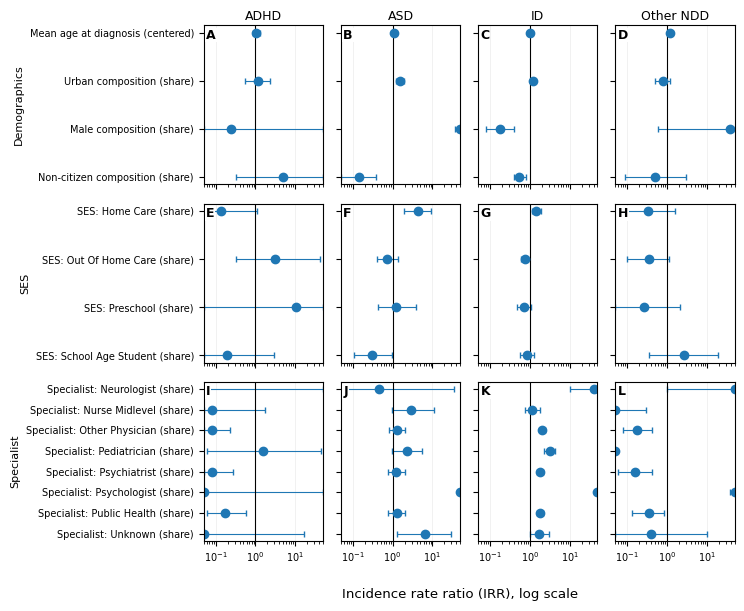

Saved:
- Figure_3_Forest_IRR_NB_Composition_3x4.tif
- Figure_3_Forest_IRR_NB_Composition_3x4.eps


In [ ]:
# =========================================================
# Figure: Forest plot with 3 rows (blocks) × 4 columns (disorders)
# Cambridge "combination artwork": grayscale (8-bit), TIFF 800 dpi (+ EPS)
# Inputs:
#   irr_long with columns: ["Disorder","term","IRR (95% CrI)"] at minimum
# =========================================================

# -------------------------
# CONFIG (EDIT HERE)
# -------------------------
FIG_NUM = 3
OUT_BASE = f"Figure_{FIG_NUM}_Forest_IRR_NB_Composition_3x4"

DISORDER_ORDER = ["ADHD", "ASD", "ID", "Other NDD"]

# Block definitions based on your composition-model term naming
DEMOG_TERMS = {"prop_male", "age_mean_c", "prop_city", "prop_non_kz"}
BLOCK_ORDER = ["Demographics", "SES", "Specialist"]

# Cambridge size / export
FIG_WIDTH_MM = 174
FIG_HEIGHT_MM = 170  # taller for 3 rows
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# -------------------------
# Helpers
# -------------------------
def parse_irr(s):
    # expects "1.23 (1.01, 1.56)"
    try:
        s = str(s)
        est = float(s.split(" ", 1)[0])
        inside = s.split("(", 1)[1].split(")", 1)[0]
        lo = float(inside.split(",", 1)[0].strip())
        hi = float(inside.split(",", 1)[1].strip())
        return est, lo, hi
    except Exception:
        return np.nan, np.nan, np.nan

pretty = {
    "prop_male": "Male composition (share)",
    "age_mean_c": "Mean age at diagnosis (centered)",
    "prop_non_kz": "Non-citizen composition (share)",
    "prop_city": "Urban composition (share)",
}
def pretty_term(t: str) -> str:
    if t in pretty:
        return pretty[t]
    if t.startswith("ses_"):
        return "SES: " + t.replace("ses_", "").replace("_", " ").title() + " (share)"
    if t.startswith("spec_"):
        return "Specialist: " + t.replace("spec_", "").replace("_", " ").title() + " (share)"
    return t

def block_name(term: str) -> str:
    if term in DEMOG_TERMS:
        return "Demographics"
    if term.startswith("ses_"):
        return "SES"
    if term.startswith("spec_"):
        return "Specialist"
    return "DROP"

def clip_limits_for_log(lo, hi, q=(0.02, 0.98), hard=(0.05, 50)):
    vals = np.concatenate([lo, hi])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) == 0:
        return 0.2, 5.0
    xmin = np.exp(np.quantile(np.log(vals), q[0]))
    xmax = np.exp(np.quantile(np.log(vals), q[1]))
    xmin = max(xmin, hard[0])
    xmax = min(xmax, hard[1])
    return float(xmin), float(xmax)

# -------------------------
# Prepare table
# -------------------------
tbl = irr_long.copy()
tbl = tbl[tbl["Disorder"].isin(DISORDER_ORDER)].copy()

tbl[["irr", "lo", "hi"]] = tbl["IRR (95% CrI)"].apply(lambda x: pd.Series(parse_irr(x)))
tbl = tbl.dropna(subset=["irr", "lo", "hi"]).copy()
tbl = tbl[tbl["term"] != "Intercept"].copy()

tbl["Block"] = tbl["term"].apply(block_name)
tbl = tbl[tbl["Block"].isin(BLOCK_ORDER)].copy()
tbl["Block"] = pd.Categorical(tbl["Block"], categories=BLOCK_ORDER, ordered=True)

tbl["Predictor"] = tbl["term"].apply(pretty_term)

# Determine x-limits (shared across ALL subplots)
xmin, xmax = clip_limits_for_log(tbl["lo"].values, tbl["hi"].values)

# -------------------------
# Build per-block predictor orders (consistent across disorders)
# -------------------------
terms_by_block = {}
for b in BLOCK_ORDER:
    terms = (
        tbl.loc[tbl["Block"] == b, "term"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
    terms_by_block[b] = terms

# -------------------------
# Plot: 3 rows (blocks) × 4 cols (disorders)
# -------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=FIGSIZE,
    sharex=True,
    gridspec_kw=dict(wspace=0.15, hspace=0.12)
)

# Panel letters across the whole grid (A–L)
panel_letters = [chr(ord("A") + i) for i in range(12)]

k = 0
for r, block in enumerate(BLOCK_ORDER):
    terms = terms_by_block[block]
    # y positions: top -> bottom inside each block-row
    y = np.arange(len(terms))[::-1]
    term_to_y = {t: y[i] for i, t in enumerate(terms)}

    for c, disorder in enumerate(DISORDER_ORDER):
        ax = axes[r, c]
        sub = tbl[(tbl["Block"] == block) & (tbl["Disorder"] == disorder)].copy()

        # reindex to ensure every term exists (even if missing for a disorder -> NaN)
        sub = sub.set_index("term").reindex(terms).reset_index()
        sub["ypos"] = sub["term"].map(term_to_y)

        # plotting clip only (visual)
        sub["lo_p"] = sub["lo"].clip(lower=xmin, upper=xmax)
        sub["hi_p"] = sub["hi"].clip(lower=xmin, upper=xmax)
        sub["irr_p"] = sub["irr"].clip(lower=xmin, upper=xmax)

        m = np.isfinite(sub["irr_p"].values) & np.isfinite(sub["lo_p"].values) & np.isfinite(sub["hi_p"].values)
        if m.any():
            ax.errorbar(
                sub.loc[m, "irr_p"].values,
                sub.loc[m, "ypos"].values,
                xerr=np.vstack([
                    sub.loc[m, "irr_p"].values - sub.loc[m, "lo_p"].values,
                    sub.loc[m, "hi_p"].values - sub.loc[m, "irr_p"].values
                ]),
                fmt="o",
                capsize=2,
                linewidth=0.8,
            )

        ax.axvline(1.0, linewidth=0.8, color="0.0")
        ax.set_xscale("log")
        ax.set_xlim(xmin, xmax)

        # Column titles on top row only
        if r == 0:
            ax.set_title(disorder, pad=4)

        # Row labels on first column only
        if c == 0:
            ax.set_yticks(y)
            ax.set_yticklabels([pretty_term(t) for t in terms])
            ax.set_ylabel(block)
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

        # Grid: x only
        ax.grid(axis="x", alpha=0.25, linewidth=0.5)
        ax.grid(False, axis="y")

        # Panel letter
        ax.text(
            0.02, 0.98, panel_letters[k],
            transform=ax.transAxes, va="top", ha="left",
            fontsize=9, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6)
        )
        k += 1

# Common x-axis label
fig.supxlabel("Incidence rate ratio (IRR), log scale", y=0.02)

# Tight layout: reserve left space for predictor labels
plt.tight_layout(rect=[0.22, 0.05, 1, 1])

# Export: TIFF 800 dpi grayscale combo + EPS
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")

plt.show()

print("Saved:")
print(f"- {OUT_BASE}.tif")
print(f"- {OUT_BASE}.eps")


# NB Forest OR

In [ ]:
# ============================================================
# CONFIG
# ============================================================
OUTDIR = "./checkpoints_binom_comp_pymc"
os.makedirs(OUTDIR, exist_ok=True)

DISORDERS = [
    ("adhd", "ADHD"),
    ("asd", "ASD"),
    ("intellectual_disability", "ID"),
    ("developmental_disorder", "Other NDD"),
]

# Choose draws:
# FAST for iteration; FINAL for manuscript
FIT_FAST  = dict(draws=800,  tune=800,  chains=2, cores=2, target_accept=0.95, random_seed=42)
FIT_FINAL = dict(draws=1500, tune=1500, chains=2, cores=2, target_accept=0.97, random_seed=42)

FIT_CFG = FIT_FINAL

#  filter tiny denominators
MIN_TRIALS = 10

# ============================================================
# INPUT: model_df must already exist
# Required columns:
# - disorder_category, region_std
# - n_cases, n_total_registry
# - predictors (we build list below)
# ============================================================
dfm = model_df.copy()

# Basic integrity
dfm["n_cases"] = pd.to_numeric(dfm["n_cases"], errors="coerce")
dfm["n_total_registry"] = pd.to_numeric(dfm["n_total_registry"], errors="coerce")

dfm = dfm.dropna(subset=["n_cases", "n_total_registry", "region_std", "disorder_category"]).copy()
dfm = dfm[(dfm["n_total_registry"] > 0) & (dfm["n_cases"] >= 0) & (dfm["n_cases"] <= dfm["n_total_registry"])].copy()

#  stability filter
dfm = dfm[dfm["n_total_registry"] >= MIN_TRIALS].copy()

# Region index for random intercept
dfm["region_std"] = dfm["region_std"].astype("category")
region_codes = dfm["region_std"].cat.codes.values
region_levels = list(dfm["region_std"].cat.categories)

print("Model_df rows:", len(dfm), "| regions:", len(region_levels))

# ============================================================
# PREDICTOR LIST
# ============================================================
BASE_TERMS = ["year_c", "prop_male_c10", "age_mean_c", "prop_non_kz_c10", "prop_city_c10"]

ETH_TERMS  = [c for c in dfm.columns if c.startswith("eth_share_") and c.endswith("_c10")]
SES_TERMS  = [c for c in dfm.columns if c.startswith("ses_share_") and c.endswith("_c10")]
SPEC_TERMS = [c for c in dfm.columns if c.startswith("spec_share_") and c.endswith("_c10")]

# Drop baselines
ETH_TERMS  = [c for c in ETH_TERMS  if c != "eth_share_other_c10"]
SES_TERMS  = [c for c in SES_TERMS  if c != "ses_share_other_c10"]
SPEC_TERMS = [c for c in SPEC_TERMS if c != "spec_share_unknown_c10"]

PRED_COLS = BASE_TERMS + ETH_TERMS + SES_TERMS + SPEC_TERMS

# Verify predictors exist
missing_pred = [c for c in PRED_COLS if c not in dfm.columns]
if missing_pred:
    raise KeyError(f"Missing predictors in model_df: {missing_pred}")

# Make sure predictors are numeric
for c in PRED_COLS:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

dfm = dfm.dropna(subset=PRED_COLS).copy()

print("Predictors:", len(PRED_COLS))

# ============================================================
# FIT ONE DISORDER
# ============================================================
def fit_binom_mixed_one(dsub: pd.DataFrame, disorder_label: str, out_nc: str):
    """
    Binomial-logit mixed model:
      y ~ Binomial(n, p)
      logit(p) = a + Xb + u_region
      u_region ~ Normal(0, sigma_region)
    """
    y = dsub["n_cases"].astype(int).values
    n = dsub["n_total_registry"].astype(int).values

    r = dsub["region_std"].cat.codes.values

    X = dsub[PRED_COLS].values.astype(float)
    N, K = X.shape

    coords = {
        "obs_id": np.arange(N),
        "pred": PRED_COLS,
        "region": region_levels,
    }

    with pm.Model(coords=coords) as model:
        # Data containers
        X_d = pm.Data("X", X, dims=("obs_id", "pred"))
        r_d = pm.Data("region_idx", r, dims="obs_id")
        n_d = pm.Data("n", n, dims="obs_id")

        # Priors
        intercept = pm.Normal("Intercept", mu=0.0, sigma=1.0)

        beta = pm.Normal("beta", mu=0.0, sigma=0.30, dims="pred")

        sigma_region = pm.HalfNormal("sigma_region", sigma=0.40)
        u_region = pm.Normal("u_region", mu=0.0, sigma=sigma_region, dims="region")

        eta = intercept + pm.math.dot(X_d, beta) + u_region[r_d]
        p = pm.Deterministic("p", pm.math.sigmoid(eta), dims="obs_id")

        # Likelihood: Binomial successes out of n
        y_obs = pm.Binomial("y", n=n_d, p=p, observed=y, dims="obs_id")

        idata = pm.sample(**FIT_CFG)

    idata.to_netcdf(out_nc)
    print("Saved:", out_nc)
    return model, idata

# ============================================================
# RUN: per disorder, checkpointed
# ============================================================
idatas = {}
for code, label in DISORDERS:
    dsub = dfm[dfm["disorder_category"] == code].copy()
    print(f"\n--- {label} --- rows={len(dsub)} regions={dsub['region_std'].nunique()}")
    if len(dsub) == 0:
        print("Skip (no rows).")
        continue

    out_nc = os.path.join(OUTDIR, f"idata_binom_comp_{code}.nc")
    try:
        _, idata = fit_binom_mixed_one(dsub, label, out_nc)
        idatas[code] = idata
    except Exception as e:
        print(f"[FAILED] {label}: {e}")
        continue


Model_df rows: 773 | regions: 20


KeyError: "Missing predictors in model_df: ['prop_male_c10', 'prop_non_kz_c10', 'prop_city_c10']"

In [ ]:
pretty = {
    "year_c": "Year (per 1-year increase)",
    "prop_male_c10": "Male composition (+10pp)",
    "age_mean_c": "Mean age at diagnosis (centered, +1 year)",
    "prop_non_kz_c10": "Non-citizen composition (+10pp)",
    "prop_city_c10": "Urban composition (+10pp)",
}

def pretty_term(term: str) -> str:
    if term in pretty:
        return pretty[term]
    if term.startswith("eth_share_"):
        t = term.replace("eth_share_", "").replace("_c10", "")
        return f"Ethnicity: {t.replace('_', ' ').title()} (+10pp)"
    if term.startswith("ses_share_"):
        t = term.replace("ses_share_", "").replace("_c10", "")
        return f"SES: {t.replace('_', ' ').title()} (+10pp)"
    if term.startswith("spec_share_"):
        t = term.replace("spec_share_", "").replace("_c10", "")
        return f"Specialist: {t.replace('_', ' ').title()} (+10pp)"
    return term

def extract_or_from_idata(idata, disorder_label, hdi=0.95):
    # beta is vector over predictors
    summ = az.summary(idata, var_names=["beta"], hdi_prob=hdi).reset_index()
    # index like "beta[year_c]" if coords were named; ArviZ usually reports "beta[<pred>]"
    summ = summ.rename(columns={"index": "term_raw"})

    # Parse predictor names from beta[...]
    def _parse(t):
        t = str(t)
        if t.startswith("beta[") and t.endswith("]"):
            return t[len("beta["):-1]
        return t

    summ["term"] = summ["term_raw"].apply(_parse)

    # Convert log-odds -> OR
    hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
    hdi_cols = sorted(hdi_cols, key=lambda x: float(x.replace("hdi_", "").replace("%", "")))
    lo, hi = hdi_cols[0], hdi_cols[-1]

    summ["OR"] = np.exp(summ["mean"])
    summ["OR_low"] = np.exp(summ[lo])
    summ["OR_high"] = np.exp(summ[hi])

    out = summ[["term", "OR", "OR_low", "OR_high", "ess_bulk", "r_hat"]].copy()
    out["OR (95% CrI)"] = out.apply(lambda r: f"{r.OR:.2f} ({r.OR_low:.2f}, {r.OR_high:.2f})", axis=1)
    out.insert(0, "Disorder", disorder_label)
    out.insert(2, "Predictor", out["term"].apply(pretty_term))
    return out

tables = []
for code, label in DISORDERS:
    if code in idatas:
        tables.append(extract_or_from_idata(idatas[code], label, hdi=0.95))

if len(tables) == 0:
    raise ValueError("No fitted models in idatas; nothing to extract.")
or_long = pd.concat(tables, ignore_index=True)

or_long.to_csv("Table_OR_Binomial_Composition.csv", index=False)
or_long.to_excel("Table_OR_Binomial_Composition.xlsx", index=False)

print("Saved:")
print("- Table_OR_Binomial_Composition.csv")
print("- Table_OR_Binomial_Composition.xlsx")


In [ ]:
from google.colab import files
files.download("Table_OR_Binomial_Composition.xlsx")

In [ ]:
# =========================================================
# Figure 3: Forest plot with 3 rows (blocks) × 4 columns (disorders)
# Cambridge "combination artwork": grayscale (8-bit), TIFF 800 dpi (+ EPS)
#
# Input table:
#   or_long with columns:
#     ["Disorder","term","OR (95% CrI)"]  (from the PyMC binomial composition model)
# Optional columns (ignored here):
#     OR, OR_low, OR_high, ess_bulk, r_hat, Predictor
# =========================================================

# -------------------------
# CONFIG
# -------------------------
FIG_NUM = 3
OUT_BASE = f"Figure_{FIG_NUM}_Forest_OR_BinomialComposition_3x4"

DISORDER_ORDER = ["ADHD", "ASD", "ID", "Other NDD"]

BLOCK_ORDER = ["Demographics", "SES", "Specialist"]

# export
FIG_WIDTH_MM = 174
FIG_HEIGHT_MM = 175  # taller for readable y labels
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# -------------------------
# Helpers
# -------------------------
def parse_or(s):
    """expects '1.23 (1.01, 1.56)'"""
    try:
        s = str(s)
        est = float(s.split(" ", 1)[0])
        inside = s.split("(", 1)[1].split(")", 1)[0]
        lo = float(inside.split(",", 1)[0].strip())
        hi = float(inside.split(",", 1)[1].strip())
        return est, lo, hi
    except Exception:
        return np.nan, np.nan, np.nan

pretty_base = {
    "year_c": "Year (per 1-year increase)",
    "prop_male_c10": "Male composition (+10pp)",
    "age_mean_c": "Mean age at diagnosis (centered, +1 year)",
    "prop_non_kz_c10": "Non-citizen composition (+10pp)",
    "prop_city_c10": "Urban composition (+10pp)",
}

def pretty_term(t: str) -> str:
    t = str(t)
    if t in pretty_base:
        return pretty_base[t]
    if t.startswith("eth_share_"):
        name = t.replace("eth_share_", "").replace("_c10", "")
        return f"Ethnicity: {name.replace('_',' ').title()} (+10pp)"
    if t.startswith("ses_share_"):
        name = t.replace("ses_share_", "").replace("_c10", "")
        return f"SES: {name.replace('_',' ').title()} (+10pp)"
    if t.startswith("spec_share_"):
        name = t.replace("spec_share_", "").replace("_c10", "")
        return f"Specialist: {name.replace('_',' ').title()} (+10pp)"
    return t

def block_name(term: str) -> str:
    term = str(term)
    # Demographics includes year + demographic shares + ethnicity shares
    if term == "year_c" or term in {"prop_male_c10", "age_mean_c", "prop_non_kz_c10", "prop_city_c10"}:
        return "Demographics"
    if term.startswith("eth_share_"):
        return "Demographics"
    if term.startswith("ses_share_"):
        return "SES"
    if term.startswith("spec_share_"):
        return "Specialist"
    return "DROP"

def clip_limits_for_log(lo, hi, q=(0.02, 0.98), hard=(0.05, 50)):
    """Robust x-limits on log scale so extreme CIs don't crush the plot."""
    vals = np.concatenate([np.asarray(lo), np.asarray(hi)])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) == 0:
        return 0.2, 5.0
    xmin = np.exp(np.quantile(np.log(vals), q[0]))
    xmax = np.exp(np.quantile(np.log(vals), q[1]))
    xmin = max(float(xmin), hard[0])
    xmax = min(float(xmax), hard[1])
    # guard
    if xmin >= xmax:
        xmin, xmax = 0.2, 5.0
    return xmin, xmax

# -------------------------
# Prepare table
# -------------------------
tbl = or_long.copy()

# Basic filters
tbl = tbl[tbl["Disorder"].isin(DISORDER_ORDER)].copy()
if "OR (95% CrI)" not in tbl.columns:
    raise KeyError("Expected column 'OR (95% CrI)' in or_long.")

# Parse OR strings
tbl[["or", "lo", "hi"]] = tbl["OR (95% CrI)"].apply(lambda x: pd.Series(parse_or(x)))
tbl = tbl.dropna(subset=["or", "lo", "hi"]).copy()

tbl = tbl[tbl["term"] != "Intercept"].copy()

# Assign blocks
tbl["Block"] = tbl["term"].apply(block_name)
tbl = tbl[tbl["Block"].isin(BLOCK_ORDER)].copy()
tbl["Block"] = pd.Categorical(tbl["Block"], categories=BLOCK_ORDER, ordered=True)

# Pretty labels
tbl["Predictor"] = tbl["term"].apply(pretty_term)

# Shared x-limits across all panels
xmin, xmax = clip_limits_for_log(tbl["lo"].values, tbl["hi"].values)

# -------------------------
# Build per-block predictor orders
# -------------------------
terms_by_block = {}
for b in BLOCK_ORDER:
    terms = (
        tbl.loc[tbl["Block"] == b, "term"]
        .drop_duplicates()
        .tolist()
    )
    if b == "Demographics":
        demog_core = ["year_c", "prop_male_c10", "age_mean_c", "prop_non_kz_c10", "prop_city_c10"]
        eth_terms = sorted([t for t in terms if str(t).startswith("eth_share_")])
        other = [t for t in terms if t not in demog_core and t not in eth_terms]
        terms = [t for t in demog_core if t in terms] + sorted(other) + eth_terms
    else:
        terms = sorted(terms)
    terms_by_block[b] = terms

# -------------------------
# Plot: 3 rows (blocks) × 4 cols (disorders), grayscale
# -------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=FIGSIZE,
    sharex=True,
    gridspec_kw=dict(wspace=0.12, hspace=0.10)
)

# Panel letters A–L
panel_letters = [chr(ord("A") + i) for i in range(12)]
k = 0

for r, block in enumerate(BLOCK_ORDER):
    terms = terms_by_block[block]
    y = np.arange(len(terms))[::-1]
    term_to_y = {t: y[i] for i, t in enumerate(terms)}

    for c, disorder in enumerate(DISORDER_ORDER):
        ax = axes[r, c]
        sub = tbl[(tbl["Block"] == block) & (tbl["Disorder"] == disorder)].copy()

        # Reindex to ensure consistent y ordering
        sub = sub.set_index("term").reindex(terms).reset_index()
        sub["ypos"] = sub["term"].map(term_to_y)

        # Clip to axis limits for display only
        sub["lo_p"] = sub["lo"].clip(lower=xmin, upper=xmax)
        sub["hi_p"] = sub["hi"].clip(lower=xmin, upper=xmax)
        sub["or_p"] = sub["or"].clip(lower=xmin, upper=xmax)

        m = np.isfinite(sub["or_p"].values) & np.isfinite(sub["lo_p"].values) & np.isfinite(sub["hi_p"].values)
        if m.any():
            ax.errorbar(
                sub.loc[m, "or_p"].values,
                sub.loc[m, "ypos"].values,
                xerr=np.vstack([
                    sub.loc[m, "or_p"].values - sub.loc[m, "lo_p"].values,
                    sub.loc[m, "hi_p"].values - sub.loc[m, "or_p"].values
                ]),
                fmt="o",
                capsize=2,
                linewidth=0.8,
                markersize=3.5,
                color="0.15",       # grayscale marker/line
                ecolor="0.15",
            )

        # Reference line OR=1
        ax.axvline(1.0, linewidth=0.8, color="0.0")
        ax.set_xscale("linear")
        ax.set_xlim(0.5, 2.9)

        # Column titles on top row only
        if r == 0:
            ax.set_title(disorder, pad=4)

        # Row labels (block names) on leftmost column only
        if c == 0:
            ax.set_yticks(y)
            ax.set_yticklabels([pretty_term(t) for t in terms])
            ax.set_ylabel(block)
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

        # Light x-grid for readability
        ax.grid(axis="x", alpha=0.25, linewidth=0.5, color="0.0")
        ax.grid(False, axis="y")

        # Panel letter
        ax.text(
            0.02, 0.98, panel_letters[k],
            transform=ax.transAxes, va="top", ha="left",
            fontsize=9, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6)
        )
        k += 1

# Common x-axis label
fig.supxlabel("Odds Ratio (95% CI)", y=0.05)

plt.tight_layout(rect=[0.23, 0.05, 1, 1])

# Export: TIFF 800 dpi grayscale combo + EPS
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")

plt.show()

print("Saved:")
print(f"- {OUT_BASE}.tif")
print(f"- {OUT_BASE}.eps")


NameError: name 'or_long' is not defined

# New Section

In [ ]:
# =====================================
# NATIONAL YEARLY COUNTS
# =====================================

# yearly total cases by disorder
yearly_counts = (
    df.groupby(["registry_year", "disorder_category"])
      .size()
      .reset_index(name="n_cases")
)

# yearly child population
pop_year = (
    gov_pop_clean
    .groupby("year")["total"]
    .sum()
    .reset_index()
    .rename(columns={"year": "registry_year"})
)

# merge
its_df = yearly_counts.merge(
    pop_year,
    on="registry_year",
    how="left"
)

# prevalence
its_df["prev_per_100k"] = (
    its_df["n_cases"] / its_df["total"] * 100000
)

# =====================================
# ITS VARIABLES
# =====================================

its_df = its_df.sort_values("registry_year")

# continuous time
its_df["time"] = (
    its_df["registry_year"]
    - its_df["registry_year"].min()
)

# ---- 2019 PMPC reform ----
its_df["post2019"] = (
    its_df["registry_year"] >= 2019
).astype(int)

its_df["time_after_2019"] = np.where(
    its_df["registry_year"] >= 2019,
    its_df["registry_year"] - 2019,
    0
)

# ---- 2021 ASD subsidy ----
its_df["post2021"] = (
    its_df["registry_year"] >= 2021
).astype(int)

its_df["time_after_2021"] = np.where(
    its_df["registry_year"] >= 2021,
    its_df["registry_year"] - 2021,
    0
)

# log offset
its_df["log_pop"] = np.log(its_df["total"])

print(its_df.head())

   registry_year        disorder_category  n_cases    total  prev_per_100k  \
0           2014                     adhd      285  3697221       7.708492   
1           2014                      asd      785  3697221      21.232163   
2           2014   developmental_disorder     3556  3697221      96.180347   
3           2014  intellectual_disability    10812  3697221     292.435859   
4           2015                     adhd      307  3830905       8.013772   

   time  post2019  time_after_2019  post2021  time_after_2021    log_pop  
0     0         0                0         0                0  15.123092  
1     0         0                0         0                0  15.123092  
2     0         0                0         0                0  15.123092  
3     0         0                0         0                0  15.123092  
4     1         0                0         0                0  15.158612  


In [ ]:
# =====================================
# FUNCTION
# =====================================
import statsmodels.formula.api as smf

def fit_its(disorder):

    dsub = its_df[
        its_df["disorder_category"] == disorder
    ].copy()

    formula = """
    n_cases ~
    time +
    post2019 +
    time_after_2019 +
    post2021 +
    time_after_2021
    """

    model = smf.glm(
        formula=formula,
        data=dsub,
        family=sm.families.NegativeBinomial(),
        offset=dsub["log_pop"]
    ).fit()

    return model

# =====================================
# FIT ALL
# =====================================

its_models = {}

for disorder in its_df["disorder_category"].unique():

    print(f"\n===== {disorder} =====")

    model = fit_its(disorder)

    its_models[disorder] = model

    print(model.summary())


===== adhd =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                n_cases   No. Observations:                   11
Model:                            GLM   Df Residuals:                        5
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -69.989
Date:                Fri, 08 May 2026   Deviance:                     0.043536
Time:                        07:06:11   Pearson chi2:                   0.0425
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1779
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -9.36

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha no

In [ ]:
# =====================================
# EXTRACT IRRs
# =====================================

results = []

for disorder, model in its_models.items():

    params = model.params
    conf = model.conf_int()

    for term in params.index:

        irr = np.exp(params[term])
        lo = np.exp(conf.loc[term, 0])
        hi = np.exp(conf.loc[term, 1])

        results.append({
            "Disorder": disorder,
            "Term": term,
            "IRR": irr,
            "CI_low": lo,
            "CI_high": hi,
            "p": model.pvalues[term]
        })

its_results = pd.DataFrame(results)

its_results

,Disorder,Term,IRR,CI_low,CI_high,p
0,adhd,Intercept,0.000086,0.000019,0.000393,1.583293e-33
1,adhd,time,0.875528,0.470578,1.628954,6.747563e-01
2,adhd,post2019,0.834978,0.048482,14.380499,9.011629e-01
3,adhd,time_after_2019,0.983717,0.057050,16.962285,9.909840e-01
4,adhd,post2021,1.026661,0.009412,111.982621,9.912306e-01
5,adhd,time_after_2021,1.114753,0.060442,20.559616,9.417671e-01
6,asd,Intercept,0.000223,0.000049,0.001020,2.043469e-27
7,asd,time,1.176528,0.632876,2.187187,6.073405e-01
8,asd,post2019,0.967577,0.056477,16.576681,9.818581e-01
9,asd,time_after_2019,1.072021,0.062587,18.362218,9.617300e-01


In [ ]:
term_labels = {
    "time": "Baseline yearly trend",
    "post2019": "Immediate level change after 2019",
    "time_after_2019": "Trend change after 2019",
    "post2021": "Immediate level change after 2021",
    "time_after_2021": "Trend change after 2021",
}

its_results["Term"] = (
    its_results["Term"]
    .map(term_labels)
)

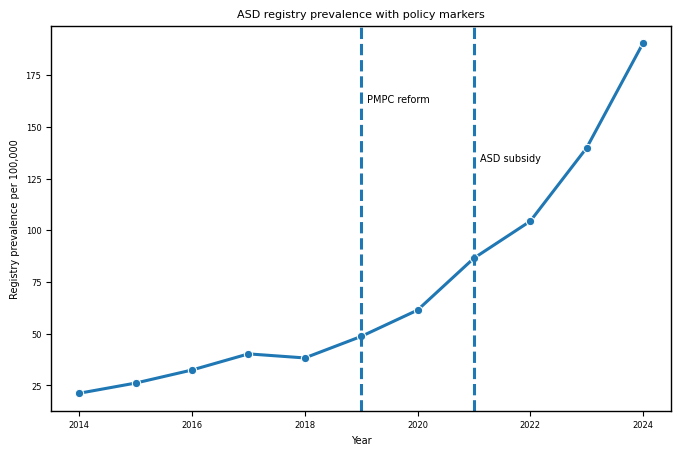

In [ ]:
# =====================================
# ASD example
# =====================================

asd = its_df[
    its_df["disorder_category"] == "asd"
]

plt.figure(figsize=(8,5))

sns.lineplot(
    data=asd,
    x="registry_year",
    y="prev_per_100k",
    marker="o"
)

# policy markers
plt.axvline(2019, linestyle="--")
plt.axvline(2021, linestyle="--")

plt.text(2019.1,
         asd["prev_per_100k"].max()*0.85,
         "PMPC reform")

plt.text(2021.1,
         asd["prev_per_100k"].max()*0.7,
         "ASD subsidy")

plt.ylabel("Registry prevalence per 100,000")
plt.xlabel("Year")
plt.title("ASD registry prevalence with policy markers")

plt.show()

# Bernoulli MLM ASD Forest

In [ ]:
data = df.copy()

# children at exam/contact
data = data[data["age_exam_reported"].between(0, 17)].copy()

# merge tics into developmental
data["disorder_mlm"] = data["disorder_category"].replace({"tic_disorder": "developmental_disorder"})

# center
data["age_at_diag_c"] = data["age_at_diag_final"] - data["age_at_diag_final"].mean()
data["year_c"] = data["registry_year"] - data["registry_year"].mean()

# categoricals
for col in ["sex_std", "SES_group", "region_std", "specialist_group", "location_type"]:
    data[col] = data[col].astype("category")

core = ["year_c","age_at_diag_c","sex_std","SES_group","location_type","region_std","specialist_group","disorder_mlm"]
model_base = data.dropna(subset=core).copy()


In [ ]:
def sample_case_control(df, outcome_col="y", controls_per_case=5, max_cases=None, random_state=42):
    cases = df[df[outcome_col] == 1]
    controls = df[df[outcome_col] == 0]

    if max_cases is not None and len(cases) > max_cases:
        cases = cases.sample(n=max_cases, random_state=random_state)

    n_controls_target = min(len(controls), controls_per_case * len(cases))
    sampled_controls = controls.sample(n=n_controls_target, random_state=random_state)

    out = pd.concat([cases, sampled_controls], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out


In [ ]:
sampling_plan = {
    "asd": {"k": 5, "max_cases": None},
    "adhd": {"k": 10, "max_cases": None},
    "developmental_disorder": {"k": 5, "max_cases": None},
    "intellectual_disability": {"k": 2, "max_cases": 50000},  # key speed-up
}


In [ ]:
fit_fast = dict(draws=300, tune=300, chains=2, cores=2, target_accept=0.9, random_seed=42)
fit_final = dict(draws=800, tune=800, chains=2, cores=2, target_accept=0.9, random_seed=42)


In [ ]:
def make_binary_outcome(df, disorder_name):
    df = df.copy()
    df["y"] = (df["disorder_mlm"] == disorder_name).astype(int)
    return df

formula = (
    "y ~ year_c + age_at_diag_c + sex_std + SES_group + location_type "
    "+ (1|region_std) + (1|specialist_group)"
)

models, idatas = {}, {}

for disorder, cfg in sampling_plan.items():
    print(f"\n=== MLM for {disorder} (children-only) ===")

    df_d = make_binary_outcome(model_base, disorder)
    n_cases = int(df_d["y"].sum())
    print("Cases (full children-only):", n_cases)
    if n_cases < 50:
        print("Skipping (too few).")
        continue

    df_s = sample_case_control(
        df_d,
        outcome_col="y",
        controls_per_case=cfg["k"],
        max_cases=cfg["max_cases"],
        random_state=42,
    )
    print(f"Sampled N: {len(df_s)} | Cases: {int(df_s['y'].sum())}")

   # model = bmb.Model(formula, data=df_s, family="bernoulli")
   # idata = model.fit(**fit_final)   # swap to fit_final for results / fit_fast for reviewing

   # models[disorder] = model
   # idatas[disorder] = idata



=== MLM for asd (children-only) ===
Cases (full children-only): 45010
Sampled N: 214904 | Cases: 45010

=== MLM for adhd (children-only) ===
Cases (full children-only): 2413
Sampled N: 26543 | Cases: 2413

=== MLM for developmental_disorder (children-only) ===
Cases (full children-only): 36732
Sampled N: 214904 | Cases: 36732

=== MLM for intellectual_disability (children-only) ===
Cases (full children-only): 130749
Sampled N: 134155 | Cases: 50000


In [ ]:
# ========= MLM RESULTS EXTRACTOR (single-disorder switch) =========
# Assumes you already have:
# - model_base (children-only, cleaned)
# - sample_case_control(...)
# - make_binary_outcome(...)
# - formula (string)
# - fit_fast / fit_final dicts
# - bmb imported and available

NDD = "asd"  # options: "asd", "adhd", "developmental_disorder", "intellectual_disability"

# ---- 1) Sampling settings per disorder ----
sampling_cfg = {
    "asd": {"k": 5, "max_cases": None},
    "adhd": {"k": 10, "max_cases": None},
    "developmental_disorder": {"k": 5, "max_cases": None},
    "intellectual_disability": {"k": 2, "max_cases": 50000},  # speed safeguard
}

# ---- 2) Pretty term names ----
pretty_terms = {
    "year_c": "Registry year (per year)",
    "age_at_diag_c": "Age at diagnosis (per year)",
    "sex_std[Male]": "Male (ref: Female)",
    "sex_std[T.Male]": "Male (ref: Female)",
    "location_type[rural]": "Rural (ref: Urban)",
    "location_type[T.rural]": "Rural (ref: Urban)",
}

def _pretty(term: str) -> str:
    # SES terms
    if "SES_group" in term:
        lvl = term.split("[", 1)[-1].rstrip("]")
        return f"SES: {lvl} (ref: baseline)"
    # location terms
    if "location_type" in term:
        return pretty_terms.get(term, term)
    return pretty_terms.get(term, term)

# ---- 3) Fit ONE model (fast or final) ----
cfg = sampling_cfg[NDD]

df_d = make_binary_outcome(model_base, NDD)
print(f"NDD={NDD} | cases (children-only):", int(df_d["y"].sum()))

df_s = sample_case_control(
    df_d,
    outcome_col="y",
    controls_per_case=cfg["k"],
    max_cases=cfg["max_cases"],
    random_state=42,
)
print(f"Sampled N: {len(df_s)} | Cases: {int(df_s['y'].sum())}")

model = bmb.Model(formula=formula, data=df_s, family="bernoulli")

# choose one:
# idata = model.fit(**fit_fast)   # quick check
idata = model.fit(**fit_final)    # for reporting

# ---- 4) Extract fixed effects as OR (95% CrI) ----
def extract_fixed_effects_table(idata, disorder_label, decimals=2, hdi=0.95):
    summ = az.summary(
        idata,
        var_names=["year_c", "age_at_diag_c", "sex_std", "SES_group", "location_type"],
        hdi_prob=hdi,
    ).reset_index().rename(columns={"index": "term"})

    # Convert to ORs
    summ["OR"] = np.exp(summ["mean"])
    summ["OR_low"] = np.exp(summ["hdi_2.5%"])
    summ["OR_high"] = np.exp(summ["hdi_97.5%"])

    summ["OR (95% CrI)"] = summ.apply(
        lambda r: f"{r['OR']:.{decimals}f} ({r['OR_low']:.{decimals}f}, {r['OR_high']:.{decimals}f})",
        axis=1
    )

    out = summ[["term", "OR (95% CrI)", "ess_bulk", "r_hat"]].copy()
    out["Predictor"] = out["term"].apply(_pretty)
    out["Disorder"] = disorder_label

    return out[["Disorder", "Predictor", "OR (95% CrI)", "ess_bulk", "r_hat"]]

fixed_table = extract_fixed_effects_table(idata, disorder_label=NDD.upper())
fixed_table


 Progress                        Draw   Divergences   Step size   Grad evals   Speed         Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━   595    0             0.028       255          5.08 s/draw   0:50:30   1:19:48    
  ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━   592    0             0.032       255          5.12 s/draw   0:50:29   1:00:52

In [ ]:
# ---- 5) Extract random-effect SDs (variance components) ----

posterior_vars = list(idata.posterior.data_vars)
re_sigma_vars = [v for v in posterior_vars if ("sigma" in v) and ("region_std" in v or "specialist_group" in v)]

if len(re_sigma_vars) == 0:
    print("No random-effect sigma variables found. Inspect available vars with:")
    print(posterior_vars[:50])
else:
    re_table = az.summary(idata, var_names=re_sigma_vars, hdi_prob=0.95).reset_index().rename(columns={"index":"term"})
    re_table["Group SD (log-odds), mean (95% CrI)"] = re_table.apply(
        lambda r: f"{r['mean']:.2f} ({r['hdi_2.5%']:.2f}, {r['hdi_97.5%']:.2f})",
        axis=1
    )
    re_table = re_table[["term", "Group SD (log-odds), mean (95% CrI)", "ess_bulk", "r_hat"]]
    re_table


In [ ]:
# ---- 6) Basic model diagnostics ----
diag = {
    "N_sampled": len(df_s),
    "Cases": int(df_s["y"].sum()),
    "Controls": int((df_s["y"] == 0).sum()),
}

# quick convergence snapshot for key fixed effects
key_terms = ["year_c", "age_at_diag_c"]
summ_key = az.summary(idata, var_names=key_terms, hdi_prob=0.95)
diag["max_rhat_key_terms"] = float(summ_key["r_hat"].max())
diag["min_ess_bulk_key_terms"] = float(summ_key["ess_bulk"].min())

pd.DataFrame([diag])


In [ ]:
# ---- 7) export everything for this NDD ----
re_table.to_excel(f"mlm_fixed_effects_asd.xlsx", index=False)

if "re_table" in globals():
    re_table.to_excel(f"mlm_random_effects_SD_asd.xlsx", index=False)


In [ ]:
from google.colab import files
files.download("mlm_random_effects_SD_asd.xlsx")
files.download("mlm_fixed_effects_asd.xlsx")



In [ ]:
def extract_fixed_effects(idata, prefix=""):
    summ = az.summary(
        idata,
        var_names=["Intercept", "year_c", "age_at_diag_c"],
        hdi_prob=0.95,
    )

    summ = summ.reset_index().rename(columns={"index": "term"})

    summ["OR"] = np.exp(summ["mean"])
    summ["OR_low"] = np.exp(summ["hdi_2.5%"])
    summ["OR_high"] = np.exp(summ["hdi_97.5%"])

    return summ[[
        "term", "mean", "OR", "OR_low", "OR_high", "ess_bulk", "r_hat"
    ]]

fixed_table = extract_fixed_effects(idata)
fixed_table


In [ ]:
def extract_categorical(idata, term_contains):
    summ = az.summary(idata, var_names=term_contains, hdi_prob=0.95)
    summ = summ.reset_index().rename(columns={"index": "term"})

    summ["OR"] = np.exp(summ["mean"])
    summ["OR_low"] = np.exp(summ["hdi_2.5%"])
    summ["OR_high"] = np.exp(summ["hdi_97.5%"])

    return summ[["term", "OR", "OR_low", "OR_high"]]

sex_effects = extract_categorical(idata, ["sex_std"])
ses_effects = extract_categorical(idata, ["SES_group"])
urban_effects = extract_categorical(idata, ["location_type"])


In [ ]:
# ---- CONFIG ----
DISORDER_LABEL = NDD.upper()   # e.g., "ASD"
HDi = 0.95
DECIMALS = 2

VAR_NAMES = ["year_c", "age_at_diag_c", "sex_std", "SES_group", "location_type"]

pretty_terms = {
    "year_c": "Registry year (per 1-year increase)",
    "age_at_diag_c": "Age at diagnosis (per 1-year increase)",
    "sex_std[Male]": "Male (ref: Female)",
    "sex_std[T.Male]": "Male (ref: Female)",
    "location_type[rural]": "Rural (ref: Urban)",
    "location_type[T.rural]": "Rural (ref: Urban)",
}

def pretty(term: str) -> str:
    term = str(term)
    if "SES_group" in term:
        # term looks like SES_group[Something] or SES_group[T.Something]
        lvl = term.split("[", 1)[-1].rstrip("]")
        lvl = lvl.replace("T.", "")
        return f"SES: {lvl} (ref: baseline)"
    return pretty_terms.get(term, term)

# --- Extract summary ---
summ = az.summary(idata, var_names=VAR_NAMES, hdi_prob=HDi).reset_index().rename(columns={"index":"term"})

# Detect HDI column names robustly
hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
hdi_cols = sorted(hdi_cols, key=lambda x: float(x.replace("hdi_", "").replace("%", "")))
hdi_lo, hdi_hi = hdi_cols[0], hdi_cols[-1]

# OR + CrI
summ["OR"] = np.exp(summ["mean"])
summ["OR_low"] = np.exp(summ[hdi_lo])
summ["OR_high"] = np.exp(summ[hdi_hi])

summ["OR (95% CrI)"] = summ.apply(
    lambda r: f"{r['OR']:.{DECIMALS}f} ({r['OR_low']:.{DECIMALS}f}, {r['OR_high']:.{DECIMALS}f})",
    axis=1
)

# Pretty labels + disorder column
forest_df = summ.copy()
forest_df["Predictor"] = forest_df["term"].apply(pretty)
forest_df["Disorder"] = DISORDER_LABEL

forest_df = forest_df[forest_df["term"] != "Intercept"].copy()

forest_df = forest_df[[
    "Disorder", "term", "Predictor",
    "OR", "OR_low", "OR_high",
    "OR (95% CrI)",
    "ess_bulk", "r_hat"
]].sort_values("Predictor")

forest_df


In [ ]:
# ============================================================
# Figure 4: Forest plot (single disorder, MLM ORs)
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi + EPS
# - final size: 1-column or 2-column width (edit CONFIG)
# Input: forest_df with columns:
#   Predictor, OR, OR_low, OR_high, OR (95% CrI)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FIG_NUM = 6
OUT_BASE = f"Figure_{FIG_NUM}_Forest_OR_MLM_{DISORDER_LABEL}"

FIG_WIDTH_MM  = 174   # 85 or 174
FIG_HEIGHT_MM = 120   # adjust based on number of rows
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

SHOW_TEXT_COLUMN = True

# Predictor order
BLOCKS = {
    "Time": [
        "Registry year (per 1-year increase)",
    ],
    "Demographics": [
        "Age at diagnosis (per 1-year increase)",
        "Male (ref: Female)",
        "Rural (ref: Urban)",
    ],
    "Socioeconomic status": None,  # auto-detect SES: ... rows
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# ----------------------------
# Helpers
# ----------------------------
def clip_limits_for_log(lo, hi, q=(0.02, 0.98), hard=(0.05, 50)):
    vals = np.concatenate([np.asarray(lo), np.asarray(hi)])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) == 0:
        return 0.2, 5.0
    xmin = np.exp(np.quantile(np.log(vals), q[0]))
    xmax = np.exp(np.quantile(np.log(vals), q[1]))
    xmin = max(xmin, hard[0])
    xmax = min(xmax, hard[1])
    return float(xmin), float(xmax)

def build_order(df: pd.DataFrame):
    """Return a list of predictors in desired order with block separators."""
    preds = df["Predictor"].tolist()

    ses = [p for p in preds if p.startswith("SES:")]
    ses = sorted(ses)

    order = []
    block_of = {}

    for bname, items in BLOCKS.items():
        if items is None:
            items = ses
        for it in items:
            if it in preds:
                order.append(it)
                block_of[it] = bname

    # Append any leftovers
    leftovers = [p for p in preds if p not in order]
    for p in leftovers:
        order.append(p)
        block_of[p] = "Other"

    return order, block_of

# ----------------------------
# Prepare plotting DF
# ----------------------------
dfp = forest_df.copy()

# Drop rows with missing OR/CI
dfp = dfp.dropna(subset=["OR", "OR_low", "OR_high", "Predictor"]).copy()

# Order predictors
order, block_of = build_order(dfp)
dfp["Predictor"] = pd.Categorical(dfp["Predictor"], categories=order, ordered=True)
dfp = dfp.sort_values("Predictor").reset_index(drop=True)

# Y positions (top -> bottom)
dfp["y"] = np.arange(len(dfp))[::-1]

# X limits
xmin, xmax = clip_limits_for_log(dfp["OR_low"].values, dfp["OR_high"].values)

# Clip for display only
dfp["lo_p"] = dfp["OR_low"].clip(lower=xmin, upper=xmax)
dfp["hi_p"] = dfp["OR_high"].clip(lower=xmin, upper=xmax)
dfp["or_p"] = dfp["OR"].clip(lower=xmin, upper=xmax)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# CI + point
ax.errorbar(
    dfp["or_p"].values,
    dfp["y"].values,
    xerr=np.vstack([
        dfp["or_p"].values - dfp["lo_p"].values,
        dfp["hi_p"].values - dfp["or_p"].values
    ]),
    fmt="o",
    color="0.0",
    ecolor="0.0",
    elinewidth=0.8,
    capsize=2,
    markersize=3.5,
    markerfacecolor="1.0",
    markeredgewidth=0.8,
)

# Reference line
ax.axvline(1.0, linewidth=0.8, color="0.0")

# Axes formatting
ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Odds ratio (log scale)")
ax.set_yticks(dfp["y"].values)
ax.set_yticklabels([str(p) for p in dfp["Predictor"]])

ax.grid(axis="x", color="0.85", linewidth=0.6)
ax.grid(False, axis="y")

# Title
# ax.set_title(f"{DISORDER_LABEL}: mixed-effects logistic model (OR with 95% CrI)", pad=6)

# Block separators + labels
blocks = [block_of[str(p)] for p in dfp["Predictor"].astype(str)]
for i in range(len(dfp) - 1):
    if blocks[i] != blocks[i + 1]:
        ysep = (dfp.loc[i, "y"] + dfp.loc[i + 1, "y"]) / 2
        ax.hlines(ysep, xmin, xmax, colors="0.7", linewidth=0.6)

# right-side text column
if SHOW_TEXT_COLUMN and "OR (95% CrI)" in dfp.columns:
    # Put text just outside plotting area in axes coordinates
    x_text = 1.01
    for _, r in dfp.iterrows():
        ax.text(
            x_text, r["y"],
            str(r["OR (95% CrI)"]),
            va="center", ha="left",
            transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
            fontsize=7,
            color="0.0",
        )
    # Add header for text column
    ax.text(
        x_text, dfp["y"].max() + 0.5,
        "OR (95% CI)",
        va="bottom", ha="left",
        transform=ax.get_yaxis_transform(),
        fontsize=7,
        fontweight="bold",
        color="0.0",
    )

# Tight layout with extra right margin for text column
right_margin = 0.80 if SHOW_TEXT_COLUMN else 0.95
plt.tight_layout(rect=[0.0, 0.0, right_margin, 1.0])

# Export
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")
plt.show()

print("Saved:")
print(f"- {OUT_BASE}.tif")
print(f"- {OUT_BASE}.eps")


In [ ]:
from google.colab import files
forest_df.to_csv("MLM_ASD_Forest.csv", index=True)
files.download("MLM_ASD_Forest.csv")


# Geo Map

In [ ]:
geo_to_std = {
    "Akmola": "Akmola",
    "Aktobe": "Aktobe",
    "Almaty": "Almaty Region",
    "Almaty (city)": "Almaty City",
    "Atyrau": "Atyrau",
    "Abai": "Abai",
    "Jambyl": "Zhambyl",
    "Ulytau": "Ulytau",
    "Kostanay": "Kostanay",
    "Kyzylorda": "Kyzylorda",
    "Mangystau": "Mangystau",
    "North Kazakhstan": "North Kazakhstan",
    "Astana": "Astana City",
    "Pavlodar": "Pavlodar",
    "Shymkent (city)": "Shymkent City",
    "Turkestan": "Turkistan",
    "West Kazakhstan": "West Kazakhstan",
    "Karaganda": "Karagandy",
    "Jetisu": "Jetisu",
    "East Kazakhstan": "East Kazakhstan",
}


In [ ]:


FIG_WIDTH_MM  = 174   # use 85 for 1-column; 174 for 2-column
FIG_HEIGHT_MM = 120   # adjust to taste; keep compact
INCH_PER_MM = 1 / 25.4
fig_w = FIG_WIDTH_MM * INCH_PER_MM
fig_h = FIG_HEIGHT_MM * INCH_PER_MM

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# ----------------------------
# 1) Load geometry and harmonize region names
# ----------------------------
gdf = gpd.read_file("PATH TO KAZAKHSTAN JSON FILE.json")

# Ensure consistent coordinate system (optional but good practice)
# gdf = gdf.to_crs(epsg=3857)  # or keep native if already projected

gdf["region_std"] = gdf["name"].map(geo_to_std)

# ----------------------------
# 2) Select year and merge prevalence
# ----------------------------
YEAR = 2024
prev_year = prevalence_regional.loc[prevalence_regional["year"] == YEAR, ["region_std", "prevalence_per_100k"]].copy()

map_df = gdf.merge(prev_year, on="region_std", how="left")

# Optional: exclude Kazakhstan total polygon if present
map_df = map_df.loc[map_df["region_std"] != "Kazakhstan"].copy()

# ----------------------------
# 3) Define bins
# ----------------------------
# Use quantiles for balance, or set clinically meaningful cutpoints.
vals = map_df["prevalence_per_100k"].dropna()
if len(vals) > 0:
    bins = np.unique(np.quantile(vals, [0, 0.2, 0.4, 0.6, 0.8, 1.0]))
    # If duplicates occur (common when values are clustered), fall back to equal-width bins
    if len(bins) < 4:
        bins = np.linspace(vals.min(), vals.max(), 6)
else:
    bins = np.array([0, 1, 2, 3, 4, 5])

# Categorize
map_df["prev_bin"] = pd.cut(map_df["prevalence_per_100k"], bins=bins, include_lowest=True)

# ----------------------------
# 4) Plot
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))

# Base outlines
map_df.boundary.plot(ax=ax, linewidth=0.6, color="0.0")

# Filled choropleth in grayscale
map_df.plot(
    column="prevalence_per_100k",
    ax=ax,
    cmap="Greys",
    linewidth=0.0,          # boundaries already plotted
    legend=True,
    missing_kwds=dict(
        color="0.95",        # light gray for missing
        edgecolor="0.0",
        hatch="///",
        label="Missing"
    ),
)

# Title
ax.set_title(f"Registered NDD prevalence (<15 years), {YEAR}", pad=6)

ax.axis("off")

# Clean legend formatting (if present)
leg = ax.get_legend()
if leg is not None:
    leg.set_title("Per 100,000")
    # Make legend compact (matplotlib varies by version)
    for txt in leg.get_texts():
        txt.set_fontsize(7)
    leg.get_title().set_fontsize(7)

plt.tight_layout()

# ----------------------------
# 5) Export (Cambridge: combination artwork -> grayscale TIFF 800 dpi)
# ----------------------------
out_base = f"Figure_Map_NDDprev_u15_{YEAR}"

# TIFF: 800 dpi for combination artwork
fig.savefig(f"{out_base}.tif", format="tiff", dpi=800, bbox_inches="tight")

# Optional EPS (vector wrapper; may rasterize the choropleth fills depending on backend)
# fig.savefig(f"{out_base}.eps", format="eps", bbox_inches="tight")

plt.show()


In [ ]:
# ============================================================
# Figure 2. Regional variation in registered prevalence, single year (per 100,000)
# Cambridge "combination artwork" (line + tone):
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - final size: 2-column width
# ============================================================

# =========================
# CONFIG
# =========================
YEAR = 2024

# Use  disorder-stratified region-year prevalence table
PREV_TBL = ndd_prev

DISORDERS = [
    ("adhd", "ADHD"),
    ("asd", "ASD"),
    ("intellectual_disability", "ID"),
    ("developmental_disorder", "Other NDD"),
]

FIG_WIDTH_MM  = 174
FIG_HEIGHT_MM = 135
INCH_PER_MM = 1 / 25.4
fig_w = FIG_WIDTH_MM * INCH_PER_MM
fig_h = FIG_HEIGHT_MM * INCH_PER_MM

DPI_TIFF = 800
OUT_BASE = f"Figure_2_Map_4panel_NDDprev_u15_{YEAR}"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# =========================
# 0) Harmonize column names
# =========================
prev = PREV_TBL.copy()

if "year" not in prev.columns:
    if "registry_year" in prev.columns:
        prev = prev.rename(columns={"registry_year": "year"})
    else:
        raise KeyError(
            "PREV_TBL must include either 'year' or 'registry_year'. "
            f"Available columns: {list(prev.columns)}"
        )

candidate_dis_cols = ["disorder_category", "ndd4", "disorder_mlm", "diagnosis_group"]
dis_col = next((c for c in candidate_dis_cols if c in prev.columns), None)
if dis_col is None:
    raise KeyError(
        "Could not find a disorder column. "
        f"Tried: {candidate_dis_cols}. Available columns: {list(prev.columns)}"
    )

need_cols = {"region_std", "year", "prevalence_per_100k", dis_col}
missing = need_cols - set(prev.columns)
if missing:
    raise KeyError(
        f"PREV_TBL missing required columns: {missing}. "
        f"Available columns: {list(prev.columns)}"
    )

# =========================
# 1) Load geometry + harmonize regions
# =========================
gdf = gpd.read_file("/content/drive/MyDrive/ПЦФ/Demographics/Geo/kz.json")
gdf["region_std"] = gdf["name"].map(geo_to_std)
gdf = gdf.loc[gdf["region_std"].notna()].copy()
gdf = gdf.loc[gdf["region_std"] != "Kazakhstan"].copy()

# =========================
# 2) Filter prevalence to YEAR + selected disorders
# =========================
prev_y = prev.loc[
    (prev["year"] == YEAR) &
    (prev[dis_col].isin([d[0] for d in DISORDERS])),
    ["region_std", "year", dis_col, "prevalence_per_100k"]
].copy()

map_long = gdf.merge(prev_y, on="region_std", how="left")

# Shared scale across panels
vals = map_long["prevalence_per_100k"].dropna().astype(float)
vmin = float(vals.min()) if len(vals) else 0.0
vmax = float(vals.max()) if len(vals) else 1.0

# =========================
# 3) Plot 2x2 panels + colorbar axis
# =========================
fig = plt.figure(figsize=(fig_w, fig_h))

# Create a 3-row layout: 2 rows for maps, 1 short row for colorbar
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    height_ratios=[1.0, 1.0, 0.08],  # bottom row reserved for colorbar
    hspace=0.05, wspace=0.02
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]
cax = fig.add_subplot(gs[2, :])  # colorbar spans both columns

panel_letters = ["A", "B", "C", "D"]
mappable_for_cbar = None

for i, (code, label) in enumerate(DISORDERS):
    ax = axes[i]
    sub = map_long.loc[map_long[dis_col] == code].copy()

    # Borders
    gdf.boundary.plot(ax=ax, linewidth=0.6, color="0.0")

    # Fill
    sub.plot(
        column="prevalence_per_100k",
        ax=ax,
        cmap="Greys",
        vmin=vmin,
        vmax=vmax,
        linewidth=0.0,
        legend=False,
        missing_kwds=dict(color="0.95", edgecolor="0.0", hatch="///"),
    )

    # Keep a mappable from first plotted panel for the colorbar
    if (mappable_for_cbar is None) and (len(ax.collections) > 0):
        mappable_for_cbar = ax.collections[-1]

    ax.set_title(label, pad=4)

    # Panel label: slightly inset + white bbox so it doesn't collide with borders
    ax.text(
        0.03, 0.97, panel_letters[i],
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5, alpha=0.9)
    )

    ax.axis("off")

# Colorbar in reserved axis
cax.axis("on")
if mappable_for_cbar is not None:
    cbar = fig.colorbar(
        mappable_for_cbar,
        cax=cax,
        orientation="horizontal",
    )
    cbar.set_label("Registered prevalence per 100,000 children <15 years")

# Tighten margins explicitly
fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.08)

# =========================
# 4) Export (TIFF 800 dpi, grayscale)
# =========================
fig.savefig(f"{OUT_BASE}.tif", format="tiff", dpi=DPI_TIFF, bbox_inches="tight")
# Optional vector:
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")

plt.show()


# Stacked plot

In [ ]:
# ============================================================
# Figure S5. Changes in diagnostic composition:
# F84.0 vs F84.1 vs ID vs Other NDD
# by selected region groups (2x2 panels)
#
# Cambridge "combination artwork":
# - TIFF (grayscale 8-bit) @ 800 dpi (+ optional EPS)
# - final publication size (2-column width)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FIG_NUM = 2
OUT_BASE = f"Figure_{FIG_NUM}_Composition_u15_F840_F841_ID_Other"

FIG_WIDTH_MM  = 174
FIG_HEIGHT_MM = 120
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

DATA = df

DX_COL = "main_diagnosis"   # e.g., "main_diagnosis" or "icd10_code"

YEAR_COL = "registry_year"
REGION_COL = "region_std"
DISORDER_COL = "disorder_category"     # must include "intellectual_disability"
AGE_COL = "age_exam_reported"

ID_CODE = "intellectual_disability"

# Region labels
ASTANA = "Astana City"
ALMATY = "Almaty City"
EAST_KZ = "East Kazakhstan"
ABAI = "Abai"

PANEL_GROUPS = {
    "Astana City": [ASTANA],
    "Almaty City": [ALMATY],
    "East Kazakhstan + Abai": [EAST_KZ, ABAI],
    "All other regions": "OTHER",
}
panel_order = ["Astana City", "Almaty City", "East Kazakhstan + Abai", "All other regions"]

# Stack order (bottom -> top)
STACK_ORDER = ["F84.0", "F84.1", "ID", "Other NDD"]

legend_labels = {
    "F84.0": "Childhood autism (F84.0)",
    "F84.1": "Atypical autism (F84.1)",
    "ID": "Intellectual disability",
    "Other NDD": "Other NDD",
}

# ----------------------------
# 1) Validate required columns
# ----------------------------
need = {YEAR_COL, REGION_COL, DISORDER_COL, AGE_COL, DX_COL}
missing = need - set(DATA.columns)
if missing:
    raise KeyError(
        f"df is missing required columns: {missing}. "
        f"Available: {list(DATA.columns)}"
    )

# ----------------------------
# 2) Restrict to children <15
# ----------------------------
d = DATA.loc[DATA[AGE_COL].notna() & (DATA[AGE_COL].astype(float) < 16)].copy()

# Standardize ICD strings
d[DX_COL] = d[DX_COL].astype(str).str.strip()

dx_remap_for_figure = {
    "F80.0": "F84.0",
    "F80.1": "F84.1",
}
d[DX_COL] = d[DX_COL].replace(dx_remap_for_figure)


# ----------------------------
# 3) Build mutually-exclusive 4-category grouping
# ----------------------------
d["group4"] = np.where(
    d[DX_COL].eq("F84.0"), "F84.0",
    np.where(
        d[DX_COL].eq("F84.1"), "F84.1",
        np.where(
            d[DISORDER_COL].eq(ID_CODE), "ID",
            "Other NDD"
        )
    )
)

# ----------------------------
# 4) Build region groups
# ----------------------------
def assign_region_group(region):
    for g, members in PANEL_GROUPS.items():
        if members == "OTHER":
            continue
        if region in members:
            return g
    return "All other regions"

d["region_group"] = d[REGION_COL].apply(assign_region_group)
d = d[d["region_group"].isin(panel_order)].copy()

# ----------------------------
# 5) Build PREV_TBL-like counts
# ----------------------------
counts = (
    d.groupby(["region_group", YEAR_COL, "group4"], observed=True)
     .size()
     .rename("n_cases")
     .reset_index()
     .rename(columns={YEAR_COL: "year"})
)

# Compute within-year shares for each region_group
counts["total_year"] = counts.groupby(["region_group", "year"])["n_cases"].transform("sum")
counts["share"] = np.where(counts["total_year"] > 0, counts["n_cases"] / counts["total_year"], np.nan)

wide = (
    counts.pivot(index=["region_group", "year"], columns="group4", values="share")
          .reindex(columns=STACK_ORDER)
          .fillna(0.0)
          .reset_index()
)

# ----------------------------
# 6) Plot (2x2 panels), grayscale
# ----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

fill_greys = {
    "F84.0": "0.15",
    "F84.1": "0.35",
    "ID": "0.60",
    "Other NDD": "0.82",
}

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharex=True, sharey=True)
axes = axes.flatten()
panel_letters = ["A", "B", "C", "D"]

for i, (ax, group) in enumerate(zip(axes, panel_order)):
    sub = wide[wide["region_group"] == group].sort_values("year")
    years = sub["year"].astype(int).values

    bottoms = np.zeros(len(sub), dtype=float)
    for g in STACK_ORDER:
        vals = sub[g].values.astype(float)
        ax.fill_between(
            years, bottoms, bottoms + vals,
            step="mid",
            linewidth=0.4,
            edgecolor="0.0",
            facecolor=fill_greys[g],
            label=legend_labels.get(g, g),
        )
        bottoms += vals

    # Panel letter
    ax.text(
        0.005, 0.98, panel_letters[i],
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, fontweight="bold"
    )

    ax.set_title(group, pad=4)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)
    ax.grid(False, axis="x")

axes[2].set_xlabel("Year")
axes[3].set_xlabel("Year")
axes[0].set_ylabel("Proportion of diagnoses")
axes[2].set_ylabel("Proportion of diagnoses")

# One-line legend
handles, labels = axes[0].get_legend_handles_labels()
seen, h2, l2 = set(), [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        h2.append(h)
        l2.append(l)

fig.legend(
    h2, l2,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    handlelength=1.6,
    columnspacing=1.5
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

# ----------------------------
# 7) Export
# ----------------------------
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")
plt.show()


# Exploratory / paper excluded below

# ASD vs other trends

In [ ]:
from scipy.stats import spearmanr

# -----------------------------
# CONFIG
# -----------------------------
ALPHA = 0.05
YEAR_MIN, YEAR_MAX = 2014, 2024
CHILD_AGE_MAX = 16
MIN_PAIRED_YEARS = 5   # require at least 5 paired years for a region-specific rho

ASD_GROUP = "asd"
OTHER_GROUP = "developmental_disorder"  # includes tics per your convention

# -----------------------------
# ICD-10 LABEL DICTIONARY (extend as needed)
# -----------------------------
ICD_LABELS = {
    # ===== ASD =====
    "F84.0": "Childhood autism",
    "F84.1": "Atypical autism",
    "F84.2": "Rett syndrome",
    "F84.3": "Other childhood disintegrative disorder",
    "F84.4": "Overactive disorder with ID",
    "F84.5": "Asperger syndrome",
    "F84.8": "Other pervasive developmental disorders",
    "F84.9": "PDD, unspecified",
    "F84":   "Pervasive developmental disorders",

    # ===== Other developmental disorders (incl. tics) =====
    "F80.0": "Phonological disorder",
    "F80.1": "Expressive language disorder",
    "F80.2": "Receptive language disorder",
    "F80.3": "Acquired aphasia with epilepsy",
    "F80.8": "Other speech & language disorders",
    "F80.9": "Speech & language disorder, unspecified",
    "F80":   "Specific speech & language disorders",

    "F81.0": "Specific reading disorder (dyslexia)",
    "F81.1": "Specific spelling disorder",
    "F81.2": "Specific disorder of arithmetical skills (dyscalculia)",
    "F81.3": "Mixed disorder of scholastic skills",
    "F81.8": "Other scholastic skill disorders",
    "F81.9": "Scholastic disorder, unspecified",
    "F81":   "Specific scholastic skill disorders",

    "F82":   "Specific developmental disorder of motor function",
    "F83":   "Mixed specific developmental disorders",
    "F88":   "Other disorders of psychological development",
    "F89":   "Unspecified disorder of psychological development",

    # Tics (kept, per your instruction)
    "F95.0": "Transient tic disorder",
    "F95.1": "Chronic motor or vocal tic disorder",
    "F95.2": "Tourette syndrome",
    "F95.8": "Other tic disorders",
    "F95.9": "Tic disorder, unspecified",
}


# -----------------------------
# 1) Filter + normalize ICD codes
# -----------------------------
d = df.copy()
d = d.loc[
    (d["age_exam_reported"] < CHILD_AGE_MAX)
    & d["registry_year"].between(YEAR_MIN, YEAR_MAX)
    & d["main_diagnosis"].notna()
    & d["disorder_category"].notna()
    & d["region_std"].notna()
].copy()

dx = d["main_diagnosis"].astype(str).str.upper().str.strip()
d["icd"] = np.where(dx.str.contains(r"\.", regex=True), dx.str[:5], dx.str[:3])

asd = d[d["disorder_category"] == ASD_GROUP].copy()
oth = d[d["disorder_category"] == OTHER_GROUP].copy()

asd_codes = sorted(asd["icd"].unique())
oth_codes = sorted(oth["icd"].unique())

# -----------------------------
# 2) Build region×year count "series" for a specific code
# (keeps years as an index so we can align safely)
# -----------------------------
def region_year_series(df_sub, code):
    s = (
        df_sub.loc[df_sub["icd"] == code]
        .groupby(["region_std", "registry_year"])
        .size()
        .rename("n")
        .reset_index()
    )
    return s  # long form

# Precompute long tables (faster than rebuilding inside loops)
asd_long = {c: region_year_series(asd, c) for c in asd_codes}
oth_long = {c: region_year_series(oth, c) for c in oth_codes}

# -----------------------------
# 3) Correlations: per region, align by year, then summarize (median)
# -----------------------------
records = []

for o in oth_codes:
    df_o = oth_long[o]
    if df_o.empty:
        continue

    for a in asd_codes:
        df_a = asd_long[a]
        if df_a.empty:
            continue

        # Merge ensures paired years only
        merged = df_a.merge(
            df_o,
            on=["region_std", "registry_year"],
            how="inner",
            suffixes=("_asd", "_oth"),
        )

        if merged.empty:
            continue

        rhos, ps = [], []

        for reg, g in merged.groupby("region_std"):
            x = g["n_asd"].to_numpy()
            y = g["n_oth"].to_numpy()

            # Need enough paired years + variability
            if len(x) < MIN_PAIRED_YEARS:
                continue
            if np.nanstd(x) == 0 or np.nanstd(y) == 0:
                continue

            r, p = spearmanr(x, y)
            if np.isfinite(r):
                rhos.append(r)
                ps.append(p)

        if len(rhos) >= 3:  # require ≥3 regions contributing
            records.append({
                "Other_code": o,
                "ASD_code": a,
                "rho": float(np.median(rhos)),
                "p": float(np.median(ps)),
                "n_regions_used": int(len(rhos)),
            })

corr_df = pd.DataFrame(records)

# -----------------------------
# 4) Pivot to matrices (ROWS=Other, COLS=ASD)
# -----------------------------
rho_mat = corr_df.pivot(index="Other_code", columns="ASD_code", values="rho")
p_mat   = corr_df.pivot(index="Other_code", columns="ASD_code", values="p")

# Apply readable labels
rho_mat.index = [ICD_LABELS.get(c, c) for c in rho_mat.index]
rho_mat.columns = [ICD_LABELS.get(c, c) for c in rho_mat.columns]
p_mat.index, p_mat.columns = rho_mat.index, rho_mat.columns

rho_mat, p_mat


(                                                   Childhood autism  \
 Phonological disorder                                     -0.685582   
 Expressive language disorder                              -0.265887   
 Other speech & language disorders                         -0.007203   
 Speech & language disorder, unspecified                   -0.640511   
 Specific reading disorder (dyslexia)                      -0.719178   
 Specific spelling disorder                                -0.133631   
 Mixed disorder of scholastic skills                       -0.580173   
 Other scholastic skill disorders                           0.349127   
 Scholastic disorder, unspecified                           0.463817   
 Specific developmental disorder of motor function         -0.866025   
 Mixed specific developmental disorders                    -0.013667   
 Other disorders of psychological development              -0.849315   
 Unspecified disorder of psychological development          0.41

In [ ]:
from google.colab import files
corr_df.to_excel("ASD_vs_OtherNDD_trend_correlations.xlsx", index=False)
files.download("ASD_vs_OtherNDD_trend_correlations.xlsx")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

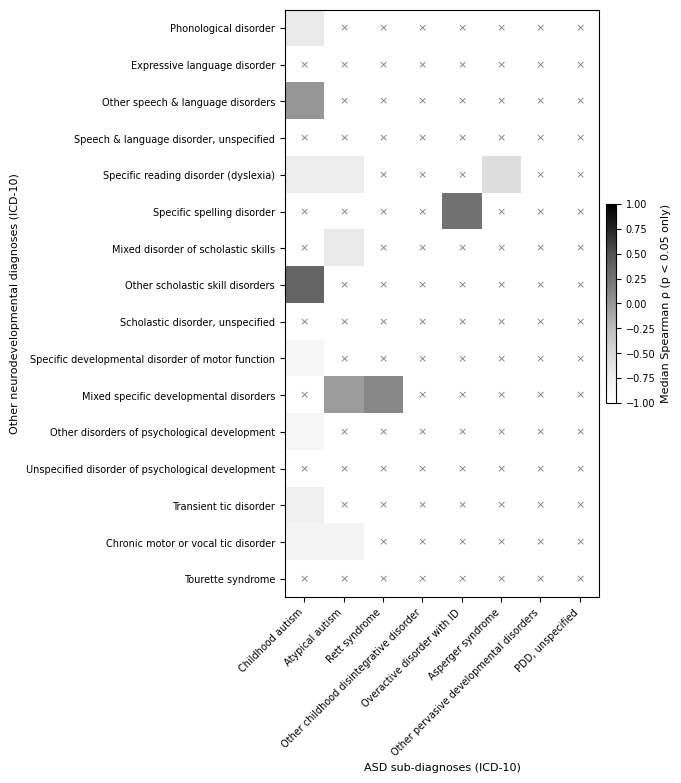

Saved:
- Figure_7_ASD_vs_OtherNDD_Reclassification.tif
- Figure_7_ASD_vs_OtherNDD_Reclassification.eps


In [ ]:
from matplotlib.colors import TwoSlopeNorm

# -----------------------------
# FIGURE CONFIG (Cambridge)
# -----------------------------
FIG_NUM = 7
OUT_BASE = f"Figure_{FIG_NUM}_ASD_vs_OtherNDD_Reclassification"

FIG_WIDTH_MM = 174
FIG_HEIGHT_MM = 200
INCH_PER_MM = 1 / 25.4
DPI_TIFF = 800
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
})

# -----------------------------
# Mask non-significant cells
# -----------------------------
sig_mask = p_mat < ALPHA
rho_sig = rho_mat.where(sig_mask)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = ax.imshow(rho_sig.values, cmap="Greys", norm=norm, aspect="auto")

# Axes
ax.set_xticks(np.arange(rho_sig.shape[1]))
ax.set_xticklabels(rho_sig.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(rho_sig.shape[0]))
ax.set_yticklabels(rho_sig.index)

ax.set_xlabel("ASD sub-diagnoses (ICD-10)")
ax.set_ylabel("Other neurodevelopmental diagnoses (ICD-10)")


# -----------------------------
# Mark non-significant cells
# -----------------------------
for i in range(rho_sig.shape[0]):
    for j in range(rho_sig.shape[1]):
        if not sig_mask.iloc[i, j]:
            ax.text(j, i, "×", ha="center", va="center",
                    fontsize=8, color="0.5")

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Median Spearman ρ (p < 0.05 only)")

fig.tight_layout()
fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")
plt.show()

print("Saved:")
print(f"- {OUT_BASE}.tif")
print(f"- {OUT_BASE}.eps")


# ASD in Astana random NB

In [ ]:
# ============================================================
# ASD–Astana negative binomial model (region × year)
# - Numerator: registry counts restricted to children <15
# - Outcome: n_cases (ASD) per region-year
# - Offset: log(population <15) per region-year
# - Key term: year_c × astana (differential slope in Astana)
# - Covariates: urban_case_share (from location_type), mean age,
#               specialist composition, SES composition, ethnicity composition
# ============================================================

# ----------------------------
# SETTINGS (VERIFY)
# ----------------------------
YEAR_MIN, YEAR_MAX = 2014, 2024
CHILD_AGE_MAX = 15

ASTANA_LABEL = "Astana City"   # VERIFY exact value in df["region_std"]
CITY_LABEL   = "city"          # VERIFY exact value in df["location_type"]
# (RURAL label not needed; we only compute city share)

DENOM_DF = gov_pop_full.copy()
DENOM_YEAR_COL = "year" if "year" in DENOM_DF.columns else "registry_year"   # VERIFY
DENOM_COL = "total" if "total" in DENOM_DF.columns else ("population" if "population" in DENOM_DF.columns else None)
if DENOM_COL is None:
    raise KeyError(f"Cannot find population column in DENOM_DF. Columns: {list(DENOM_DF.columns)}")

KEEP_SPECS = ["psychiatrist", "neurologist", "psychologist"]  # must match df["specialist_group"]

# Optional: reduce high-cardinality ethnicity to avoid unstable estimates
# (strongly recommended; otherwise you'll get enormous CrIs due to sparse cells)
ETHNICITY_TOP_K = 8        # set None to keep all categories (not recommended)
ETHNICITY_OTHER_LABEL = "Other/rare"

# Fit settings
fit_fast  = dict(draws=1200, tune=1200, chains=2, cores=2, target_accept=0.95, random_seed=42)
fit_final = dict(draws=2500, tune=2500, chains=2, cores=2, target_accept=0.97, random_seed=42)

# ----------------------------
# 0) Base filter: children <15, years, ASD only
# ----------------------------
data = df.copy()

need_df_cols = ["registry_year", "region_std", "disorder_category", "age_exam_reported",
                "specialist_group", "location_type"]
miss = [c for c in need_df_cols if c not in data.columns]
if miss:
    raise KeyError(f"df missing required columns: {miss}")

data = data.loc[
    data["age_exam_reported"].notna()
    & (data["age_exam_reported"].astype(float) < CHILD_AGE_MAX)
].copy()

data = data.loc[(data["registry_year"] >= YEAR_MIN) & (data["registry_year"] <= YEAR_MAX)].copy()
data = data.loc[data["disorder_category"] == "asd"].copy()

# ----------------------------
# 1) Outcome: ASD counts per region-year
# ----------------------------
counts = (
    data.groupby(["registry_year", "region_std"], observed=True)
        .size()
        .rename("n_cases")
        .reset_index()
)

# ----------------------------
# 2) urban_case_share: fraction of ASD cases from "city" within region-year
# ----------------------------
data["_is_city"] = (data["location_type"].astype(str) == str(CITY_LABEL)).astype(int)

urban_share = (
    data.groupby(["registry_year", "region_std"], observed=True)["_is_city"]
        .mean()
        .rename("urban_case_share")
        .reset_index()
)

# ----------------------------
# 3) Specialist composition: shares per region-year (centered)
# ----------------------------
spec_counts = (
    data.groupby(["registry_year", "region_std", "specialist_group"], observed=True)
        .size()
        .rename("n_spec")
        .reset_index()
)

spec_totals = (
    spec_counts.groupby(["registry_year", "region_std"], observed=True)["n_spec"]
               .sum()
               .rename("n_total_spec")
               .reset_index()
)

spec = spec_counts.merge(spec_totals, on=["registry_year", "region_std"], how="left", validate="many_to_one")
spec["share"] = spec["n_spec"] / spec["n_total_spec"]

# full region-year grid to ensure missing specialists become 0
grid = counts[["registry_year", "region_std"]].drop_duplicates()

spec_wide = (
    spec.pivot_table(
        index=["registry_year", "region_std"],
        columns="specialist_group",
        values="share",
        aggfunc="mean"
    )
    .reset_index()
)
spec_wide = grid.merge(spec_wide, on=["registry_year", "region_std"], how="left")

for s in KEEP_SPECS:
    if s not in spec_wide.columns:
        spec_wide[s] = 0.0
spec_wide[KEEP_SPECS] = spec_wide[KEEP_SPECS].fillna(0.0)

for s in KEEP_SPECS:
    spec_wide[f"{s}_c"] = spec_wide[s] - spec_wide[s].mean()

spec_c = [f"{s}_c" for s in KEEP_SPECS]
spec_int = [f"year_c:{s}_c" for s in KEEP_SPECS]

# ----------------------------
# 4) SES composition: shares per region-year (drop 1 ref col)
# ----------------------------
ses_cols = []
ses_wide = None

if "SES_group" in data.columns:
    ses_long = (
        data.groupby(["registry_year", "region_std", "SES_group"], observed=True)
            .size()
            .rename("n")
            .reset_index()
    )
    ses_wide = ses_long.pivot_table(
        index=["registry_year", "region_std"],
        columns="SES_group",
        values="n",
        fill_value=0
    )

    ses_wide = ses_wide.div(ses_wide.sum(axis=1), axis=0).reset_index()
    ses_wide.columns.name = None

    # rename to ses_<clean>
    rename = {}
    for c in ses_wide.columns:
        if c in ["registry_year", "region_std"]:
            continue
        clean = "".join(ch if ch.isalnum() else "_" for ch in str(c).strip().lower())
        clean = "_".join([p for p in clean.split("_") if p])
        rename[c] = f"ses_{clean}"
    ses_wide = ses_wide.rename(columns=rename)

    ses_cols = [c for c in ses_wide.columns if c.startswith("ses_")]

    # drop one reference to avoid collinearity (shares sum to 1)
    if len(ses_cols) >= 2:
        ref = sorted(ses_cols)[0]
        ses_cols = [c for c in ses_cols if c != ref]
        ses_wide = ses_wide.drop(columns=[ref])

# ----------------------------
# 5) Ethnicity composition: shares per region-year (collapse rare; drop 1 ref col)
# ----------------------------
eth_cols = []
eth_wide = None

if "ethnicity_std" in data.columns:
    eth_ser = data["ethnicity_std"].astype(str)

    if ETHNICITY_TOP_K is not None:
        top = eth_ser.value_counts().head(int(ETHNICITY_TOP_K)).index
        data["_eth_collapsed"] = np.where(eth_ser.isin(top), eth_ser, ETHNICITY_OTHER_LABEL)
        eth_col_use = "_eth_collapsed"
    else:
        eth_col_use = "ethnicity_std"

    eth_long = (
        data.groupby(["registry_year", "region_std", eth_col_use], observed=True)
            .size()
            .rename("n")
            .reset_index()
    )

    eth_wide = eth_long.pivot_table(
        index=["registry_year", "region_std"],
        columns=eth_col_use,
        values="n",
        fill_value=0
    )

    eth_wide = eth_wide.div(eth_wide.sum(axis=1), axis=0).reset_index()
    eth_wide.columns.name = None

    rename = {}
    for c in eth_wide.columns:
        if c in ["registry_year", "region_std"]:
            continue
        clean = "".join(ch if ch.isalnum() else "_" for ch in str(c).strip().lower())
        clean = "_".join([p for p in clean.split("_") if p])
        rename[c] = f"eth_{clean}"
    eth_wide = eth_wide.rename(columns=rename)

    eth_cols = [c for c in eth_wide.columns if c.startswith("eth_")]

    # drop one reference
    if len(eth_cols) >= 2:
        ref = sorted(eth_cols)[0]
        eth_cols = [c for c in eth_cols if c != ref]
        eth_wide = eth_wide.drop(columns=[ref])

# ----------------------------
# 6) Mean age at diagnosis per region-year
# ----------------------------
age_tbl = None
if "age_at_diag_final" in data.columns:
    age_tbl = (
        data.loc[data["age_at_diag_final"].notna()]
            .groupby(["registry_year", "region_std"], observed=True)["age_at_diag_final"]
            .mean()
            .rename("age_mean")
            .reset_index()
    )

# ----------------------------
# 7) Denominators + offset (population <15)
# ----------------------------
denom = DENOM_DF.copy()

if DENOM_YEAR_COL != "registry_year":
    denom = denom.rename(columns={DENOM_YEAR_COL: "registry_year"})

need = ["registry_year", "region_std", DENOM_COL]
miss = [c for c in need if c not in denom.columns]
if miss:
    raise KeyError(f"DENOM_DF missing required columns: {miss}")

denom = denom.loc[(denom["registry_year"] >= YEAR_MIN) & (denom["registry_year"] <= YEAR_MAX), need].copy()
denom[DENOM_COL] = pd.to_numeric(denom[DENOM_COL], errors="coerce")
denom = denom.dropna(subset=[DENOM_COL]).copy()

# ----------------------------
# 8) Build modeling table (region-year)
# ----------------------------
agg = counts.merge(denom, on=["registry_year", "region_std"], how="left", validate="many_to_one")
agg = agg.dropna(subset=[DENOM_COL]).copy()

agg = agg.merge(urban_share, on=["registry_year", "region_std"], how="left", validate="one_to_one")
agg["urban_case_share"] = agg["urban_case_share"].fillna(0.0)

agg = agg.merge(
    spec_wide[["registry_year", "region_std"] + spec_c],
    on=["registry_year", "region_std"], how="left", validate="one_to_one"
)

if age_tbl is not None:
    agg = agg.merge(age_tbl, on=["registry_year", "region_std"], how="left", validate="one_to_one")
    agg["age_mean_c"] = agg["age_mean"] - agg["age_mean"].mean()
else:
    agg["age_mean_c"] = np.nan  # will be dropped

if ses_wide is not None:
    agg = agg.merge(ses_wide, on=["registry_year", "region_std"], how="left", validate="one_to_one")
    for c in ses_cols:
        agg[c] = agg[c].fillna(0.0)

if eth_wide is not None:
    agg = agg.merge(eth_wide, on=["registry_year", "region_std"], how="left", validate="one_to_one")
    for c in eth_cols:
        agg[c] = agg[c].fillna(0.0)

# Astana + year centering
agg["astana"] = (agg["region_std"].astype(str) == str(ASTANA_LABEL)).astype(int)
agg["year_c"] = agg["registry_year"].astype(float) - agg["registry_year"].astype(float).mean()

# offset
agg["offset_log"] = np.log(agg[DENOM_COL].astype(float))

# categorical for RE
agg["region_std"] = agg["region_std"].astype("category")

# ----------------------------
# 9) Formula (drop constants)
# ----------------------------
fixed_terms = [
    "year_c",
    "astana",
    "year_c:astana",
    "urban_case_share",
    "age_mean_c",
] + spec_c + spec_int + ses_cols + eth_cols

# remove constant numeric columns (Bambi errors on constants)
kept = []
for t in fixed_terms:
    if ":" in t:
        kept.append(t)  # interaction; keep
        continue
    if t in agg.columns and agg[t].nunique(dropna=True) > 1:
        kept.append(t)

rhs = " + ".join(kept)
rand = "(1 + year_c|region_std)"
formula = f"n_cases ~ {rhs} + {rand} + offset(offset_log)"

print("ASD agg rows:", len(agg))
print("Years:", agg["registry_year"].min(), "-", agg["registry_year"].max())
print("Astana rows:", int((agg["astana"] == 1).sum()))
print("\nFormula:\n", formula)

# ----------------------------
# 10) Fit negative binomial
# ----------------------------
model = bmb.Model(formula, data=agg, family="negativebinomial")
idata = model.fit(**fit_fast)  # switch to fit_final for reporting

# ----------------------------
# 11) Journal-ready fixed-effects IRR table + forest plot
# ----------------------------
def irr_table(idata, hdi=0.95, decimals=2):
    summ = az.summary(idata, hdi_prob=hdi).reset_index().rename(columns={"index": "term"})
    hdi_cols = sorted([c for c in summ.columns if c.startswith("hdi_")],
                      key=lambda x: float(x.replace("hdi_", "").replace("%", "")))

    # keep fixed only: Intercept + predictors; exclude random SD terms
    keep = (
        summ["term"].eq("Intercept")
        | summ["term"].str.startswith("year_c")
        | summ["term"].str.startswith("astana")
        | summ["term"].eq("urban_case_share")
        | summ["term"].eq("age_mean_c")
        | summ["term"].str.endswith("_c")
        | summ["term"].str.startswith("ses_")
        | summ["term"].str.startswith("eth_")
    )
    summ = summ.loc[keep].copy()

    summ["IRR"] = np.exp(summ["mean"])
    summ["IRR_low"] = np.exp(summ[hdi_cols[0]])
    summ["IRR_high"] = np.exp(summ[hdi_cols[-1]])

    summ["IRR (95% CrI)"] = summ.apply(
        lambda r: f"{r['IRR']:.{decimals}f} ({r['IRR_low']:.{decimals}f}, {r['IRR_high']:.{decimals}f})",
        axis=1
    )

    out = summ[["term", "IRR (95% CrI)", "ess_bulk", "r_hat"]].copy()
    return out.sort_values("term").reset_index(drop=True)

fixed_tbl = irr_table(idata, hdi=0.95, decimals=2)
fixed_tbl.to_csv("Table_ASD_Astana_NB_fixed_IRR.csv", index=False)
fixed_tbl

# Forest plot (fixed effects only)
vars_for_forest = fixed_tbl["term"].tolist()
az.plot_forest(idata, var_names=vars_for_forest, combined=True, figsize=(7, max(4, 0.25 * len(vars_for_forest))))
plt.tight_layout()
plt.show()


 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━╺━━━━━━━━━━━━━━━   889     0             0.021       255          7.75 draws/s     0:01:54   0:03:31    
  ━━━━━━━━━╺━━━━━━━━━━━━━━━   878     0             0.021       255          7.65 draws/s     0:01:54   0:03:17

In [ ]:
# =========================
# DATA ASSUMPTIONS
# =========================
# agg contains one row per region-year for ASD only, with:
#   - n_cases              : ASD case count
#   - offset_log           : log(population <15)
#   - year_c               : centered registry year
#   - astana               : 1 if Astana City, 0 otherwise
#   - urban_case_share     : proportion of cases from urban localities
#   - psychiatrist_c       : centered psychiatrist share
#   - age_mean_c           : centered mean age at diagnosis
#   - SES_group collapsed  : e.g. ses_other, ses_school_age_student
#   - region_std           : region identifier (categorical)

# =========================
# FINAL MODEL FORMULA
# =========================
formula = (
    "n_cases ~ year_c + astana + urban_case_share + psychiatrist_c "
    "+ age_mean_c + ses_other + ses_school_age_student "
    "+ (1 | region_std) + offset(offset_log)"
)

print("Final ASD–Astana model:")
print(formula)

# =========================
# FIT MODEL
# =========================
model = bmb.Model(
    formula=formula,
    data=agg,
    family="negativebinomial",
)

idata = model.fit(
    draws=2500,
    tune=2500,
    chains=2,
    cores=2,
    target_accept=0.97,
    random_seed=42,
)


Final ASD–Astana model:
n_cases ~ year_c + astana + urban_case_share + psychiatrist_c + age_mean_c + ses_other + ses_school_age_student + (1 | region_std) + offset(offset_log)


Output()

In [ ]:
fixed_irr = irr_table_from_idata(idata, hdi=0.95, decimals=2)
fixed_irr

,term,IRR (95% CrI),ess_bulk,r_hat
0,Intercept,"0.00 (0.00, 0.00)",939.0,1.01
1,age_mean_c,"1.03 (0.96, 1.11)",5522.0,1.00
2,astana,"5.45 (1.17, 27.39)",3556.0,1.00
3,psychiatrist_c,"1.23 (0.94, 1.61)",3815.0,1.00
4,ses_other,"0.39 (0.26, 0.58)",5393.0,1.00
5,ses_school_age_student,"0.19 (0.07, 0.58)",4651.0,1.00
6,urban_case_share,"1.25 (1.01, 1.56)",3766.0,1.00
7,year_c,"1.29 (1.26, 1.31)",5323.0,1.00


# Demographics visual

/tmp/ipython-input-620759355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_counts, x="sex", y="count", palette="pastel")


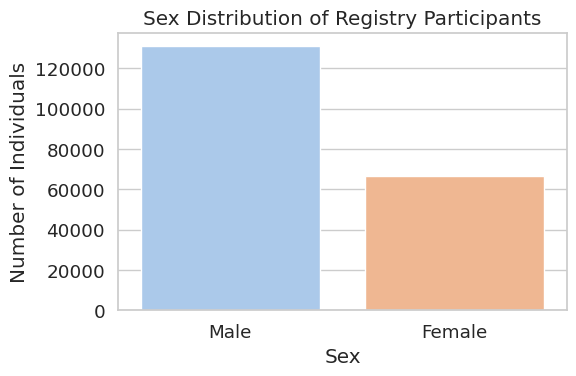

In [ ]:
sex_counts = df["sex"].value_counts().reset_index()
sex_counts.columns = ["sex", "count"]

plt.figure(figsize=(6, 4))
sns.barplot(data=sex_counts, x="sex", y="count", palette="pastel")
plt.title("Sex Distribution of Registry Participants")
plt.xlabel("Sex")
plt.ylabel("Number of Individuals")
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197589 entries, 1090 to 550602
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    197589 non-null  int64         
 1   registry_year         197589 non-null  int64         
 2   birth_date            197589 non-null  object        
 3   diagnosis_date        197589 non-null  object        
 4   age_at_diag_final     197589 non-null  float64       
 5   age_exam_reported     197589 non-null  int64         
 6   age_diagnosis         197589 non-null  int64         
 7   sex                   197589 non-null  object        
 8   city                  197589 non-null  object        
 9   location_type         197589 non-null  object        
 10  ethnicity             197589 non-null  object        
 11  citizenship_clean     197589 non-null  object        
 12  ses                   197589 non-null  object        
 13  m

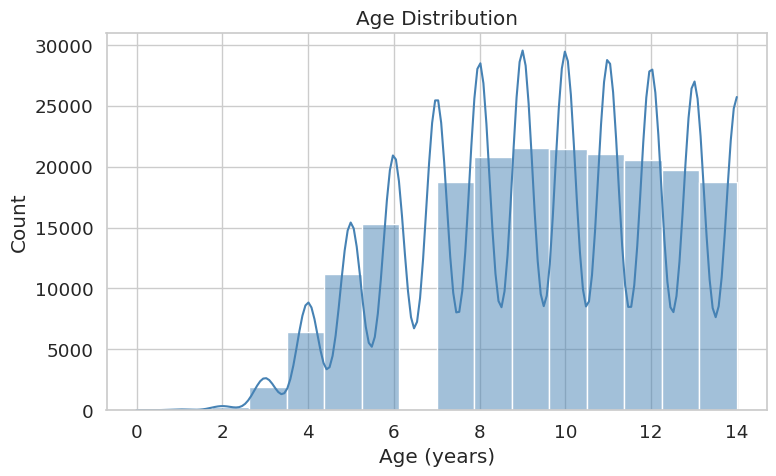

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="age_exam_reported",
    bins=16,
    kde=True,
    color="steelblue"
)
plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


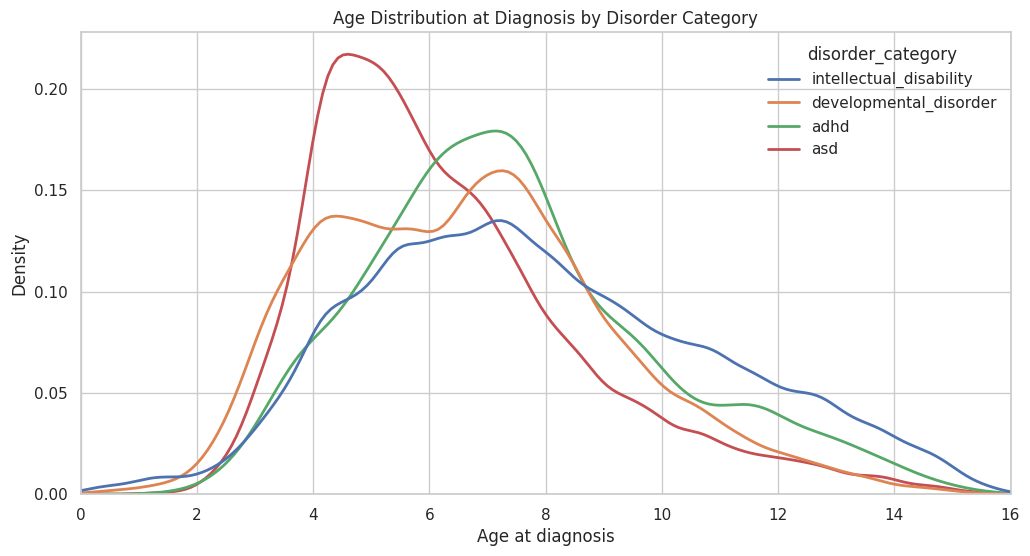

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=df,
    x="age_at_diag_final",
    hue="disorder_category",
    common_norm=False,
    linewidth=2
)

plt.title("Age Distribution at Diagnosis by Disorder Category")
plt.xlabel("Age at diagnosis")
plt.ylabel("Density")
plt.xlim(0, 16)
plt.grid(True)
plt.show()


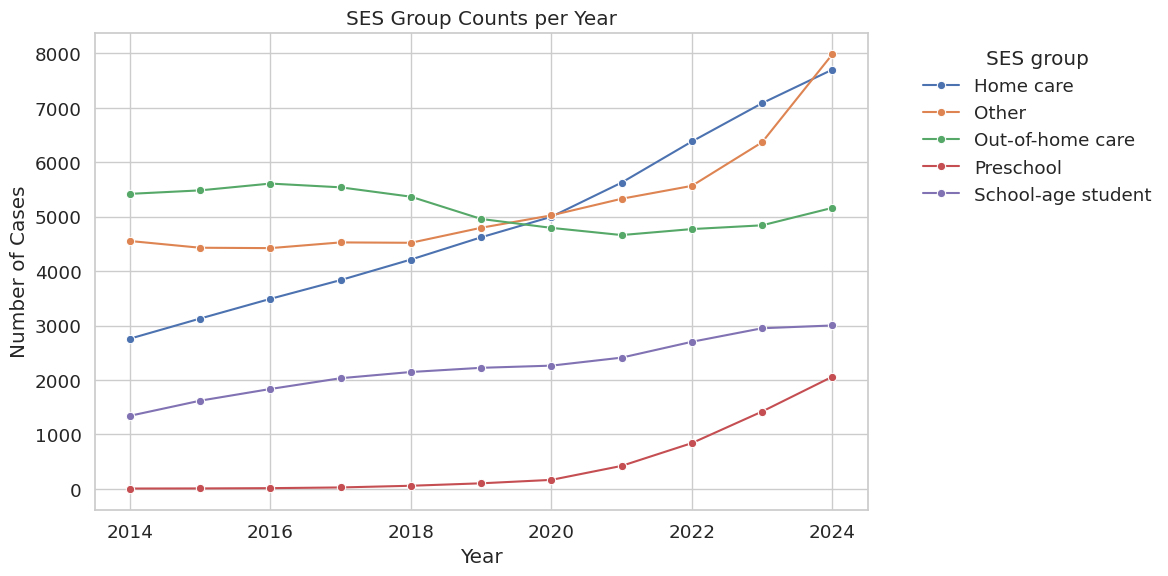

In [ ]:
# Prepare data
ses_plot = ses_counts.copy()
ses_plot = ses_plot.sort_values(["registry_year", "SES_group"])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ses_plot,
    x="registry_year",
    y="n_ses",
    hue="SES_group",
    marker="o"
)

plt.title("SES Group Counts per Year")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.legend(title="SES group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

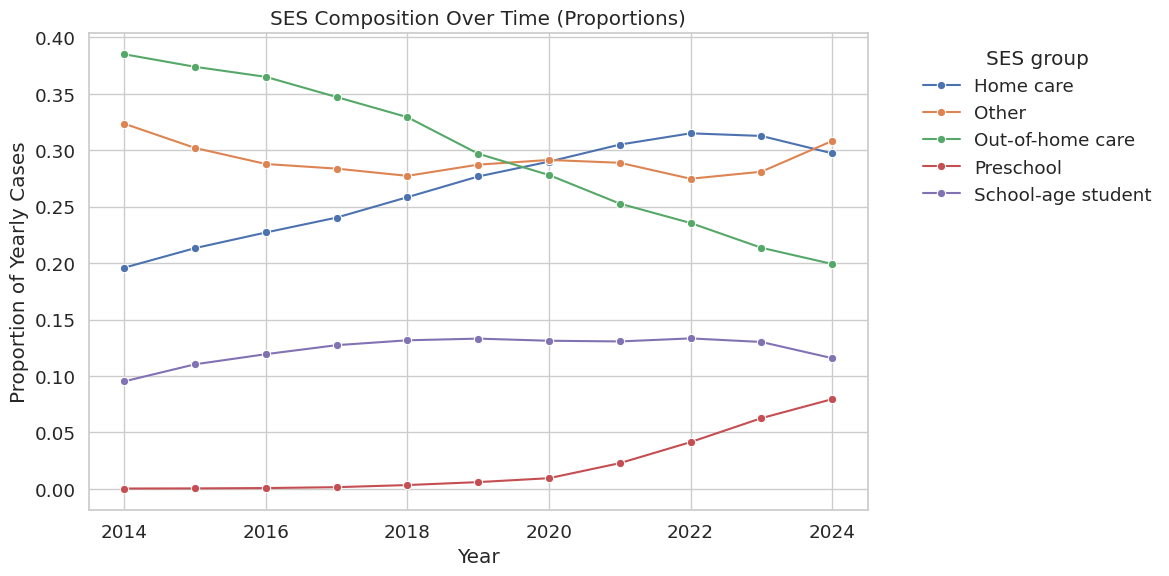

In [ ]:
# Merge counts with total yearly N
ses_props = ses_counts.merge(year_counts, on="registry_year")
ses_props["prop"] = ses_props["n_ses"] / ses_props["n_total"]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ses_props,
    x="registry_year",
    y="prop",
    hue="SES_group",
    marker="o"
)

plt.title("SES Composition Over Time (Proportions)")
plt.xlabel("Year")
plt.ylabel("Proportion of Yearly Cases")
plt.grid(True)
plt.legend(title="SES group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# 1. Count cases by SES × disorder × year × region
ses_disorder = (
    df.groupby(["registry_year", "region_std", "SES_group", "disorder_category"])
      .size()
      .rename("n_cases")
      .reset_index()
)

# 2. Merge with population denominators
ses_disorder = ses_disorder.merge(
    gov_pop_clean,
    left_on=["registry_year", "region_std"],
    right_on=["year", "region_std"],
    how="left"
)

# 3. Drop missing denominators (regions before creation)
ses_disorder = ses_disorder.dropna(subset=["total"])

# 4. Compute prevalence
ses_disorder["prevalence_per_100k"] = ses_disorder["n_cases"] / ses_disorder["total"] * 100000


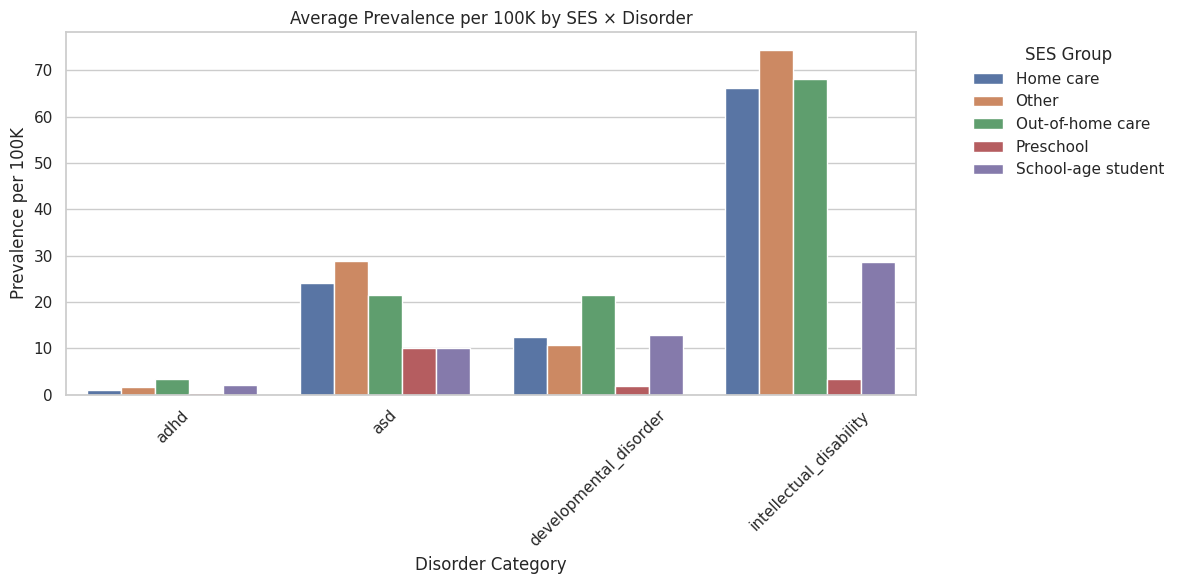

In [ ]:
plot_df = (
    ses_disorder.groupby(["SES_group", "disorder_category"])
                ["prevalence_per_100k"]
                .mean()
                .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_df,
    x="disorder_category",
    y="prevalence_per_100k",
    hue="SES_group"
)

plt.title("Average Prevalence per 100K by SES × Disorder")
plt.xlabel("Disorder Category")
plt.ylabel("Prevalence per 100K")
plt.xticks(rotation=45)
plt.legend(title="SES Group", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# Figures

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197589 entries, 1090 to 550602
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    197589 non-null  int64  
 1   registry_year         197589 non-null  int64  
 2   birth_date            197589 non-null  object 
 3   diagnosis_date        197589 non-null  object 
 4   age_at_diag_final     197589 non-null  float64
 5   age_exam_reported     197589 non-null  int64  
 6   age_diagnosis         197589 non-null  int64  
 7   sex                   197589 non-null  object 
 8   city                  197589 non-null  object 
 9   location_type         197589 non-null  object 
 10  ethnicity             197589 non-null  object 
 11  citizenship_clean     197589 non-null  object 
 12  ses                   197589 non-null  object 
 13  main_diagnosis        197589 non-null  object 
 14  disorder_category     197589 non-null  object 
 15  sp

/tmp/ipython-input-1893426015.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_24.groupby("age_bin")["Subject_ID"]
/tmp/ipython-input-1893426015.py:153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


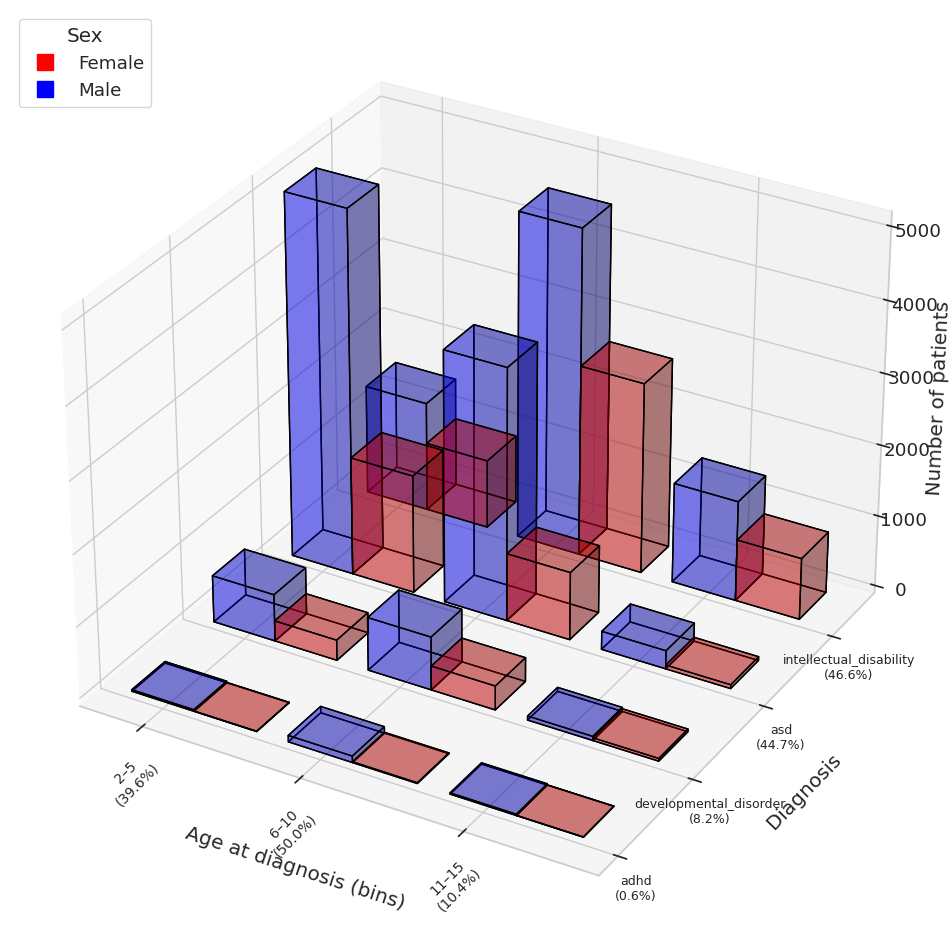

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D
import numpy as np
import pandas as pd

# ========= 1. Subset to 2024 & exclude ID / tics =========

df_24 = df[df["registry_year"] == 2024].copy()

# Exclude ID and tic disorders (adjust substrings if needed)
mask_exclude = (
    df_24["disorder_category"].str.contains("id", case=False, na=False) |
    df_24["disorder_category"].str.contains("tic", case=False, na=False)
)
df_24 = df_24[~mask_exclude].copy()

# Keep rows with valid age
df_24 = df_24[df_24["age_at_diag_final"].notna()].copy()

# Minimal columns needed
df_24["Subject_ID"] = df_24["id"]
df_24["Diagnosis"] = df_24["main_diagnosis"]   # use your main diagnosis name column

# Encode sex as 0/1 (Male/Female)
sex_map = {"Male": 0, "Female": 1}
df_24["sex_num"] = df_24["sex_std"].map(sex_map)

# ========= 2. Define age bins =========
# Adjust cuts if you want different binning
bins = [1, 6, 11, 16]
labels = ["2–5", "6–10", "11–15"]

df_24["age_bin"] = pd.cut(
    df_24["age_at_diag_final"],
    bins=bins,
    labels=labels,
    right=False  # [0,5), [5,10), ...
)

# Drop anything outside bin range (should be rare)
df_24 = df_24[df_24["age_bin"].notna()].copy()

# ========= 3. Counts & percentages =========

# Diagnoses ordered by total N (ascending so big ones at the top in 3D)
diag_counts = (
    df_24.groupby("disorder_category")["Subject_ID"]
         .nunique()
         .sort_values(ascending=True)
)

# Age-bin counts in fixed order
age_counts = (
    df_24.groupby("age_bin")["Subject_ID"]
         .nunique()
         .reindex(labels, fill_value=0)
)

total_subjects = df_24["Subject_ID"].nunique()

age_percentages = (age_counts / total_subjects) * 100
diag_percentages = (diag_counts / total_subjects) * 100

# ========= 4. Prepare grids for bar3d =========

age_labels = age_counts.index.tolist()
diag_labels = diag_counts.index.tolist()

x = np.arange(len(age_labels))   # age bins on X
y = np.arange(len(diag_labels))  # diagnoses on Y

X, Y = np.meshgrid(x, y)

Z_male = np.zeros_like(X, dtype=float)
Z_female = np.zeros_like(X, dtype=float)

# Fill matrices
for xi, age_bin in enumerate(age_labels):
    for yi, diag in enumerate(diag_labels):
        sub = df_24[
            (df_24["age_bin"] == age_bin) &
            (df_24["disorder_category"] == diag)
        ]

        Z_male[yi, xi] = sub[sub["sex_num"] == 0]["Subject_ID"].nunique()
        Z_female[yi, xi] = sub[sub["sex_num"] == 1]["Subject_ID"].nunique()

# ========= 5. Plot: 3D male/female bars by age-bin × diagnosis =========

fig = plt.figure(figsize=(26, 12))  # very wide, to fit labels
ax = fig.add_subplot(111, projection="3d")

dx = 0.4
dy = 0.4

# Female (red), shifted +dx/2
ax.bar3d(
    X.ravel() + dx/2,
    Y.ravel(),
    np.zeros_like(Z_female).ravel(),
    dx,
    dy,
    Z_female.ravel(),
    color="red",
    edgecolor="black",
    alpha=0.30,
    zsort="average"
)

# Male (blue), shifted -dx/2
ax.bar3d(
    X.ravel() - dx/2,
    Y.ravel(),
    np.zeros_like(Z_male).ravel(),
    dx,
    dy,
    Z_male.ravel(),
    color="blue",
    edgecolor="black",
    alpha=0.30,
    zsort="average"
)

# ========= 6. Axes & labels =========

# X-axis: age bins with percentages
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{age_bin}\n({age_percentages.loc[age_bin]:.1f}%)" for age_bin in age_labels],
    rotation=45,
    ha="center",
    fontsize=10
)

# Y-axis: diagnosis names with percentages
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{diag}\n({diag_percentages.loc[diag]:.1f}%)" for diag in diag_labels],
    fontsize=9
)

ax.set_xlabel("Age at diagnosis (bins)", labelpad=20)
ax.set_ylabel("Diagnosis", labelpad=20)
ax.set_zlabel("Number of patients")

# Legend
blue_patch = plt.Line2D([0], [0], marker="s", color="blue",
                        markersize=12, linestyle="none", label="Male")
red_patch = plt.Line2D([0], [0], marker="s", color="red",
                       markersize=12, linestyle="none", label="Female")
plt.legend(handles=[red_patch, blue_patch], title="Sex", loc="upper left")

plt.tight_layout()
plt.show()


# Trends

In [ ]:
ndd_prev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 684 entries, 465 to 683
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   registry_year        684 non-null    int64  
 1   region_std           684 non-null    object 
 2   disorder_category    684 non-null    object 
 3   n_cases              684 non-null    int64  
 4   population           684 non-null    int64  
 5   prevalence_per_100k  684 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 37.4+ KB


In [ ]:
import statsmodels.api as sm


In [ ]:
def prevalence_trend(df, value_col="prevalence_per_100k"):
    if df.shape[0] < 2:
        return pd.Series({
            "b": np.nan,
            "p": np.nan,
            "R2": np.nan
        })

    y = df[value_col].values
    x = df["registry_year"].values
    X = sm.add_constant(x)

    model = sm.OLS(y, X).fit()

    return pd.Series({
        "b": model.params[1],
        "p": model.pvalues[1],
        "R2": model.rsquared
    })


trend_long = (
    ndd_prev[
        (ndd_prev["registry_year"] >= 2014) &
        (ndd_prev["registry_year"] <= 2024)
    ]
    .groupby(["region_std", "disorder_category"])
    .apply(prevalence_trend)
    .reset_index()
)


trend_wide = (
    trend_long
    .pivot(index="region_std",
           columns="disorder_category",
           values=["b", "p", "R2"])
)

trend_wide.columns = [
    f"{metric}_{disorder}"
    for metric, disorder in trend_wide.columns
]

trend_wide = trend_wide.reset_index()

def format_p(p):
    if p < 0.001:
        return "<0.001"
    if p < 0.01:
        return "<0.01"
    if p < 0.05:
        return "<0.05"
    return ">0.05"

for col in trend_wide.columns:
    if col.startswith("b_"):
        trend_wide[col] = trend_wide[col].round(2)
    if col.startswith("R2_"):
        trend_wide[col] = trend_wide[col].round(2)
    if col.startswith("p_"):
        trend_wide[col] = trend_wide[col].apply(format_p)


/tmp/ipython-input-2878234352.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(prevalence_trend)


# Ethnicity graphs

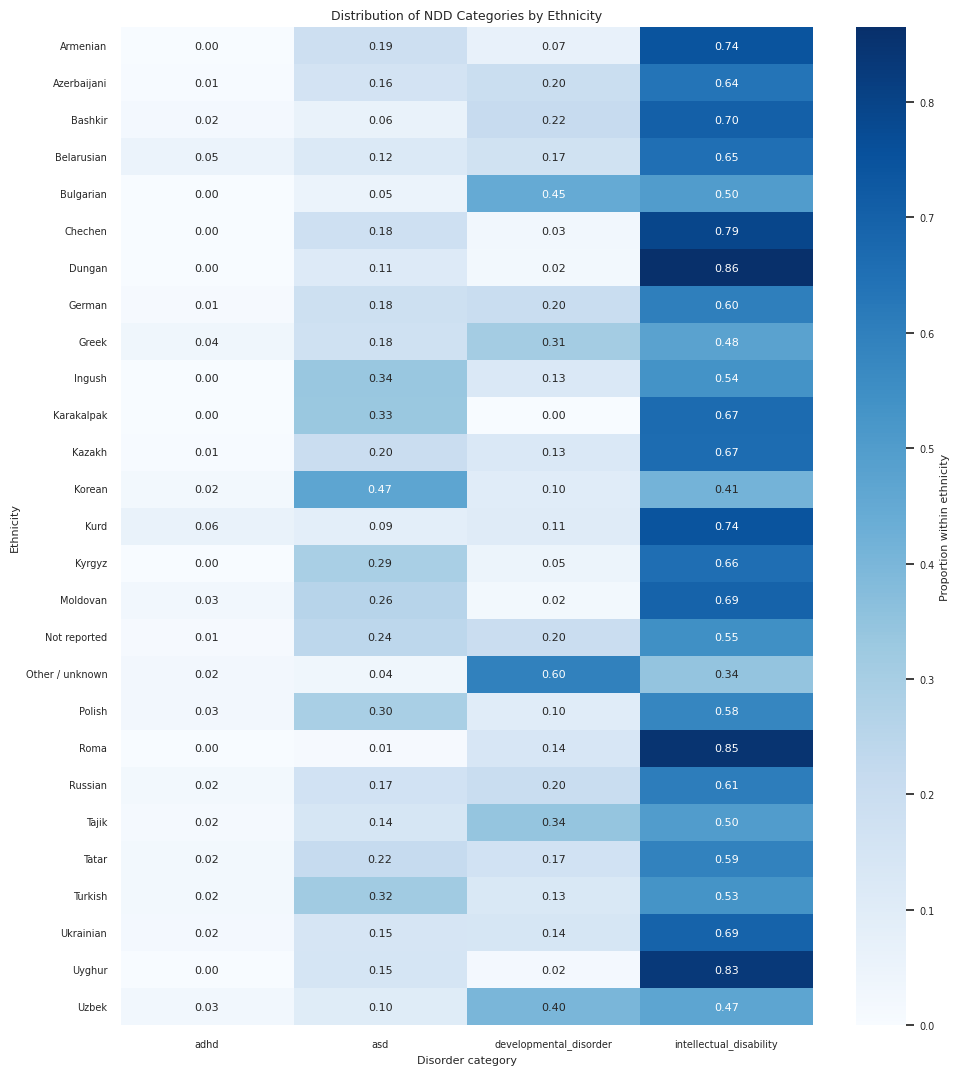

In [ ]:
# ---- 1. Count cases by ethnicity × disorder ----
eth_dis = (
    df.groupby(["ethnicity_std", "disorder_category"])
      .size()
      .rename("n")
      .reset_index()
)

# Optional: drop very small ethnic groups if they clutter
min_n = 50  # adjust threshold
keep_eth = (
    eth_dis.groupby("ethnicity_std")["n"].sum()
           .loc[lambda s: s >= min_n]
           .index
)
eth_dis = eth_dis[eth_dis["ethnicity_std"].isin(keep_eth)]

# ---- 2. Convert to row-normalized proportions ----
heat = eth_dis.pivot_table(
    index="ethnicity_std",
    columns="disorder_category",
    values="n",
    aggfunc="sum",
    fill_value=0
)

heat_prop = heat.div(heat.sum(axis=1), axis=0)  # row-wise proportions

# ---- 3. Plot heatmap ----
plt.figure(figsize=(10, max(4, 0.4 * heat_prop.shape[0])))

sns.heatmap(
    heat_prop,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Proportion within ethnicity"}
)

plt.title("Distribution of NDD Categories by Ethnicity")
plt.xlabel("Disorder category")
plt.ylabel("Ethnicity")
plt.tight_layout()
plt.show()


# Negative Binominal

In [ ]:
registry_total = (
    df
    .groupby(["registry_year", "region_std"])
    .size()
    .rename("registry_total")
    .reset_index()
)

agg = agg.merge(
    registry_total,
    on=["registry_year", "region_std"],
    how="left"
)

assert "registry_total" in agg.columns
assert agg["registry_total"].notna().all()
assert (agg["registry_total"] > 0).all()

agg["offset_log"] = np.log(agg["registry_total"].astype(float))  # or POP_COL if population offset

for s in KEEP_SPECS:
    agg[f"{s}_z"] = (agg[s] - agg[s].mean()) / agg[s].std()




NameError: name 'agg' is not defined

In [ ]:
# ==============================
# A0) SWITCHES / SETTINGS
# ==============================

# Choose denominator source and interpretation:
#   "population" -> models prevalence-rate counts with offset(log(population))
#   "registry_total" -> models composition/intensity with offset(log(total registry N in region-year))
OFFSET_MODE = "registry_total"

# Denominator table (must contain region_std, year, and POP_COL)
# If you don't have under-18 denominators, you may use total population with transparent wording.
DENOM_DF = gov_pop_full.copy()   # <-- change if needed
POP_COL = "total"                # <-- change if needed (e.g., "under18_total")

# Analysis year window
YEAR_MIN, YEAR_MAX = 2014, 2024

# Specialist types to include as region-year composition predictors
# Must match values in df["specialist_group"] exactly.
KEEP_SPECS = ["psychiatrist", "neurologist", "psychologist"]

# Disorders: must match df["disorder_category"] exactly
# We'll map into 4 groups to match your paper framing.
DISORDER_MAP = {
    "asd": "ASD",
    "adhd": "ADHD",
    "intellectual_disability": "ID",
    "developmental_disorder": "OtherNDD",
    "tic_disorder": "OtherNDD",   # fold tics into OtherNDD
    "other": "OtherNDD",
}

# Fit settings (fast vs final)
fit_final2 = dict(
    draws=2000,
    tune=2000,
    chains=2,
    cores=2,
    target_accept=0.99,
    max_treedepth=15,
    random_seed=42,
)
idata_nb = model_nb.fit(**fit_final2)

# ==============================
# A1) CHILDREN-ONLY BASE + DISORDER GROUPING
# ==============================

data = df.copy()

# children only
data = data.loc[data["age_exam_reported"] < 18].copy()

# year window
data = data.loc[(data["registry_year"] >= YEAR_MIN) & (data["registry_year"] <= YEAR_MAX)].copy()

# disorder grouping
data["ndd4"] = data["disorder_category"].map(DISORDER_MAP)
data = data.dropna(subset=["ndd4", "registry_year", "region_std", "specialist_group"])

# ==============================
# A2) AGGREGATE COUNTS: region × year × disorder
# ==============================

counts = (
    data.groupby(["registry_year", "region_std", "ndd4"])
        .size()
        .rename("n_cases")
        .reset_index()
)

# ==============================
# A3) SPECIALIST COMPOSITION: region × year (shares)
# ==============================

spec_counts = (
    data.groupby(["registry_year", "region_std", "specialist_group"])
        .size()
        .rename("n_spec")
        .reset_index()
)

spec_totals = (
    spec_counts.groupby(["registry_year", "region_std"])["n_spec"]
               .sum()
               .rename("n_total_spec")
               .reset_index()
)

spec_shares = spec_counts.merge(spec_totals, on=["registry_year", "region_std"], how="left")
spec_shares["share"] = spec_shares["n_spec"] / spec_shares["n_total_spec"]

spec_wide = (
    spec_shares.pivot_table(
        index=["registry_year", "region_std"],
        columns="specialist_group",
        values="share",
        fill_value=0.0
    )
    .reset_index()
)

# Keep only selected specialist shares; create missing columns as zeros (safe)
for s in KEEP_SPECS:
    if s not in spec_wide.columns:
        spec_wide[s] = 0.0

spec_wide = spec_wide[["registry_year", "region_std"] + KEEP_SPECS]

# Center shares for stability
for s in KEEP_SPECS:
    spec_wide[f"{s}_c"] = spec_wide[s] - spec_wide[s].mean()

# ==============================
# A4) BUILD MODELING TABLE: counts + specialist shares + offset
# ==============================

agg = counts.merge(spec_wide, on=["registry_year", "region_std"], how="left")

# Center year
agg["year_c"] = agg["registry_year"] - agg["registry_year"].mean()

# Offset: population-based (recommended)
if OFFSET_MODE == "population":
    denom = DENOM_DF.copy()
    denom = denom.rename(columns={"year": "registry_year"}) if "year" in denom.columns else denom
    denom = denom.loc[(denom["registry_year"] >= YEAR_MIN) & (denom["registry_year"] <= YEAR_MAX)].copy()

    denom = denom[["registry_year", "region_std", POP_COL]].dropna()
    agg = agg.merge(denom, on=["registry_year", "region_std"], how="left")

    # drop missing denominators
    agg = agg.dropna(subset=[POP_COL]).copy()
    agg["offset_log"] = np.log(agg[POP_COL].astype(float))

elif OFFSET_MODE == "registry_total":
    # denominator is total registry N in region-year (children only)
    reg_tot = (
        data.groupby(["registry_year", "region_std"])
            .size()
            .rename("reg_total")
            .reset_index()
    )
    agg = agg.merge(reg_tot, on=["registry_year", "region_std"], how="left")
    agg["offset_log"] = np.log(agg["reg_total"].astype(float))

else:
    raise ValueError("OFFSET_MODE must be 'population' or 'registry_total'.")

# Ensure categorical dtypes
agg["region_std"] = agg["region_std"].astype("category")
agg["ndd4"] = agg["ndd4"].astype("category")

# Quick sanity checks
print("agg rows:", len(agg))
print("years:", agg["registry_year"].min(), "-", agg["registry_year"].max())
print("ndd4 counts:\n", agg["ndd4"].value_counts())

# ==============================
# A5) FIT NEGATIVE BINOMIAL MLM (core model)
# ==============================

# Base formula (no interaction)
# Add interactions later if needed (see note below)
formula_nb = (
    "n_cases ~ year_c + ndd4 "
    "+ psychiatrist_c + neurologist_c + psychologist_c "
    "+ (1|region_std) + (1|ndd4) "
    "+ offset(offset_log)"
)

model_nb = bmb.Model(
    formula=formula_nb,
    data=agg,
    family="negativebinomial",
)

idata_nb = model_nb.fit(**fit_final)  # swap to fit_fast to iterate quickly


NameError: name 'model_nb' is not defined

In [ ]:
# ==============================
# B1) FIXED EFFECTS TABLE as IRR (rate ratios)
# ==============================

def extract_fixed_effects_irr(idata, label="NB_MLM", decimals=2, hdi=0.95):
    # Pull everything that is NOT a random effect sigma/offset
    # You can narrow var_names if you prefer.
    summ = az.summary(idata, hdi_prob=hdi).reset_index().rename(columns={"index":"term"})

    # Drop nuisance terms commonly present
    drop_contains = ["offset", "_sigma", "1|"]
    mask_drop = summ["term"].apply(lambda t: any(x in t for x in drop_contains))
    fixed = summ.loc[~mask_drop].copy()

    # Convert to IRR (exp on log scale)
    fixed["IRR"] = np.exp(fixed["mean"])
    fixed["IRR_low"] = np.exp(fixed["hdi_2.5%"])
    fixed["IRR_high"] = np.exp(fixed["hdi_97.5%"])

    fixed["IRR (95% CrI)"] = fixed.apply(
        lambda r: f"{r['IRR']:.{decimals}f} ({r['IRR_low']:.{decimals}f}, {r['IRR_high']:.{decimals}f})",
        axis=1
    )

    fixed["Model"] = label
    return fixed[["Model", "term", "IRR (95% CrI)", "ess_bulk", "r_hat"]].sort_values("term")

fixed_irr_table = extract_fixed_effects_irr(idata_nb, label=f"NB_{OFFSET_MODE}")
fixed_irr_table


In [ ]:
# ==============================
# B3) FOREST PLOTS (random intercepts)
# ==============================

# Region random intercept deviations
try:
    az.plot_forest(
        idata_nb,
        var_names=["1|region_std"],
        combined=True,
        figsize=(6, 10),
    )
    plt.title("Region random intercepts (log-rate deviations)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Region forest plot failed. Available vars containing 'region_std':")
    print([v for v in posterior_vars if "region_std" in v])
    raise e

# Disorder random intercept deviations
try:
    az.plot_forest(
        idata_nb,
        var_names=["1|ndd4"],
        combined=True,
        figsize=(6, 6),
    )
    plt.title("Disorder random intercepts (log-rate deviations)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Disorder forest plot failed. Available vars containing 'ndd4':")
    print([v for v in posterior_vars if "ndd4" in v])
    raise e


In [ ]:
# ==============================
# B4) EXPORTS
# ==============================

fixed_irr_table.to_excel(f"nb_mlm_fixed_effects_{OFFSET_MODE}.xlsx", index=False)
re_sigma_table.to_excel(f"nb_mlm_random_effects_sigma_{OFFSET_MODE}.xlsx", index=False)

# Optional: save posterior object for reuse without refitting (ArviZ netcdf)
az.to_netcdf(idata_nb, f"nb_mlm_idata_{OFFSET_MODE}.nc")


# Negative Binominal for Trends

In [ ]:
# ============================================================
# Negative Binomial trend models (children <15): publishing-ready
# - Per-disorder region-year count models with population offset
# - Optional pooled multi-disorder model for comparing slopes
# - Robust handling of denom column names (total vs population)
# - Specialist-share predictors handled as compositional (drop-one ref)
# - Produces:
#     1) fixed_effects_table (IRR, 95% CrI, ESS, R-hat)
#     2) random_effects_table (SDs for region intercept/slope, optional corr)
# - Assumes you already have:
#     df, gov_pop_full (children <15 denominators)
# - Required df cols:
#     registry_year, region_std, disorder_category, specialist_group, age_exam_reported
# ============================================================

import numpy as np
import pandas as pd
import arviz as az
import bambi as bmb

# ------------------------------
# SETTINGS / SWITCHES
# ------------------------------
YEAR_MIN, YEAR_MAX = 2014, 2024
CHILD_AGE_MAX = 15  # children <15 only (aligned to statgov)
OFFSET_MODE = "population"  # "population" (primary) or "registry_total" (secondary)

# Denominator table: children <15
DENOM_DF = gov_pop_full.copy()

# Robust population column
POP_COL = "total" if "total" in DENOM_DF.columns else ("population" if "population" in DENOM_DF.columns else None)
if POP_COL is None:
    raise KeyError("gov_pop_full must contain 'total' or 'population' for denominators.")

# Specialist share predictors (use as region-year composition predictors)
# IMPORTANT: shares are compositional -> we will drop one as reference (default: last)
KEEP_SPECS = ["psychiatrist", "neurologist", "psychologist"]
DROP_SPEC_REF = "psychologist"  # dropped from model to avoid collinearity (reference remainder)

# Disorder grouping (edit keys to match your df["disorder_category"] codes exactly)
DISORDER_MAP = {
    "asd": "ASD",
    "adhd": "ADHD",
    "intellectual_disability": "ID",
    "developmental_disorder": "OtherNDD",
    "tic_disorder": "OtherNDD",
}

USE_EXISTING_GROUP_COL = None  # e.g., "disorder_mlm" if already prepared

# Random effects
INCLUDE_REGION_RANDOM_SLOPE = True  # (1 + year_c | region_std)

# Fit settings (use fast to test; final for reporting)
fit_fast  = dict(draws=800, tune=800, chains=2, cores=2, target_accept=0.95, random_seed=42)
fit_final = dict(draws=2000, tune=2000, chains=2, cores=2, target_accept=0.97, random_seed=42)

# ------------------------------
# HELPERS: tables for publication
# ------------------------------
def _hdi_cols(summary_df: pd.DataFrame):
    cols = [c for c in summary_df.columns if c.startswith("hdi_")]
    if len(cols) < 2:
        raise KeyError("HDI columns not found in az.summary output.")
    # sort by numeric value in col name, e.g., hdi_2.5%, hdi_97.5%
    def _num(c):
        return float(c.replace("hdi_", "").replace("%", ""))
    cols = sorted(cols, key=_num)
    return cols[0], cols[-1]

def _pretty_term(term: str) -> str:
    if term == "Intercept":
        return "Intercept"
    if term == "year_c":
        return "Year (per 1-year increase)"

    # interactions
    if term.startswith("year_c:"):
        t2 = term.split(":", 1)[1]
        if t2 in ["prop_male_c", "prop_city_c", "prop_non_kz_c", "age_mean_c"]:
            return f"Year × {t2.replace('_c','').replace('_',' ')} (centered)"
        if t2.startswith("ses_"):
            return f"Year × SES: {t2.replace('ses_','').replace('_c','').replace('_',' ')} (centered)"
        return f"Year × {t2.replace('_c','').replace('_',' ')} (centered)"

    # main effects
    if term in ["prop_male_c", "prop_city_c", "prop_non_kz_c", "age_mean_c"]:
        pretty = {
            "prop_male_c": "Male composition (centered)",
            "prop_city_c": "Urban composition (centered)",
            "prop_non_kz_c": "Non-citizen composition (centered)",
            "age_mean_c": "Mean age at diagnosis (centered)",
        }
        return pretty[term]

    if term.startswith("ses_"):
        return "SES: " + term.replace("ses_", "").replace("_c", "").replace("_", " ").title() + " (centered)"

    if term.endswith("_c"):
        base = term.replace("_c", "")
        return f"{base} share (centered)"

    return term


def extract_irr_table(idata, keep_regex=None, decimals=2, hdi=0.95) -> pd.DataFrame:
    """
    Extract fixed effects as IRR (95% CrI), plus ESS and R-hat.
    keep_regex: optional list of regex patterns to keep.
    """
    summ = az.summary(idata, hdi_prob=hdi).reset_index().rename(columns={"index": "term"})
    lo, hi = _hdi_cols(summ)

    # Keep fixed effects only
    if keep_regex is None:
        keep_regex = [
            r"^Intercept$",
            r"^year_c$",
            r"_c$",                  # centered shares
            r"^year_c:.*_c$",         # year interactions with shares
            r"^ndd4\[",               # pooled models (if used)
            r"^ndd4\[T\.",            # alternative encoding
            r"^year_c:ndd4\[",        # pooled slopes
            r"^year_c:ndd4\[T\.",     # alt encoding
        ]

    keep_mask = np.zeros(len(summ), dtype=bool)
    for pat in keep_regex:
        keep_mask |= summ["term"].str.contains(pat, regex=True)

    out = summ.loc[keep_mask].copy()

    out["IRR"] = np.exp(out["mean"])
    out["IRR_low"] = np.exp(out[lo])
    out["IRR_high"] = np.exp(out[hi])

    out["IRR (95% CrI)"] = out.apply(
        lambda r: f"{r['IRR']:.{decimals}f} ({r['IRR_low']:.{decimals}f}, {r['IRR_high']:.{decimals}f})",
        axis=1
    )

    out["Predictor"] = out["term"].apply(_pretty_term)

    cols_keep = ["Predictor", "IRR (95% CrI)"]
    if "ess_bulk" in out.columns:
        cols_keep.append("ess_bulk")
    if "r_hat" in out.columns:
        cols_keep.append("r_hat")

    return out[cols_keep].sort_values("Predictor")

def extract_random_effects_table(idata, decimals=2, hdi=0.95) -> pd.DataFrame:
    """
    Extract random-effect SDs (variance components) for region intercept/slope.
    """
    vars_ = list(idata.posterior.data_vars)

    # Bambi naming varies; we search for sigma terms related to region_std
    sigma_vars = [v for v in vars_ if ("sigma" in v) and ("region_std" in v)]
    if len(sigma_vars) == 0:
        # fallback: inspect and report nothing, with hint
        return pd.DataFrame({"Note": ["No region_std sigma variables found; inspect idata.posterior.data_vars"]})

    summ = az.summary(idata, var_names=sigma_vars, hdi_prob=hdi).reset_index().rename(columns={"index": "term"})
    lo, hi = _hdi_cols(summ)

    summ["SD (95% CrI)"] = summ.apply(
        lambda r: f"{r['mean']:.{decimals}f} ({r[lo]:.{decimals}f}, {r[hi]:.{decimals}f})",
        axis=1
    )

    cols_keep = ["term", "SD (95% CrI)"]
    if "ess_bulk" in summ.columns:
        cols_keep.append("ess_bulk")
    if "r_hat" in summ.columns:
        cols_keep.append("r_hat")

    out = summ[cols_keep].copy()

    # Pretty-ish term names
    out["Random effect"] = out["term"].replace({
        "1|region_std_sigma": "Region random intercept SD",
        "year_c|region_std_sigma": "Region random year-slope SD",
    })

    return out[["Random effect", "SD (95% CrI)"] + [c for c in ["ess_bulk", "r_hat"] if c in out.columns]]

# ------------------------------
# 0) PREP: children-only + window + disorder group
# ------------------------------
data = df.copy()

# children only
data = data.loc[data["age_exam_reported"].notna() & (data["age_exam_reported"].astype(float) < CHILD_AGE_MAX)].copy()

# year window
data = data.loc[(data["registry_year"] >= YEAR_MIN) & (data["registry_year"] <= YEAR_MAX)].copy()

req = ["registry_year", "region_std", "specialist_group"]
missing = [c for c in req if c not in data.columns]
if missing:
    raise KeyError(f"Missing required columns in df: {missing}")

if USE_EXISTING_GROUP_COL is not None:
    data["ndd4"] = data[USE_EXISTING_GROUP_COL].copy()
else:
    if "disorder_category" not in data.columns:
        raise KeyError("df must contain 'disorder_category' OR set USE_EXISTING_GROUP_COL.")
    data["ndd4"] = data["disorder_category"].map(DISORDER_MAP)

data = data.dropna(subset=["ndd4", "registry_year", "region_std", "specialist_group"]).copy()

# categoricals
for col in ["region_std", "ndd4", "specialist_group"]:
    data[col] = data[col].astype("category")


# ============================================================
# 1B) Region-year composition predictors (match OR forest model)
# - Demographics: prop_male, prop_city, prop_non_kz, age_mean_c
# - SES: ses_* shares (drop-one reference)
# - Specialist: spec_* shares (already present in your code)
# ============================================================

# ----- Demographics: region-year proportions -----

# Ensure needed columns exist
need_demo = ["sex_std", "location_type", "citizenship_clean", "age_at_diag_final"]
miss_demo = [c for c in need_demo if c not in data.columns]
if miss_demo:
    raise KeyError(f"Missing columns needed for demographic compositions: {miss_demo}")

demo = data[["registry_year", "region_std", "sex_std", "location_type", "citizenship_clean", "age_at_diag_final"]].copy()

# Binary indicators
demo["is_male"] = (demo["sex_std"] == "Male").astype(int)
demo["is_city"] = (demo["location_type"] == "city").astype(int)
demo["is_non_kz"] = (demo["citizenship_clean"] != "kazakhstan").astype(int)

demo_agg = (
    demo.groupby(["registry_year", "region_std"], observed=True)
        .agg(
            prop_male=("is_male", "mean"),
            prop_city=("is_city", "mean"),
            prop_non_kz=("is_non_kz", "mean"),
            age_mean=("age_at_diag_final", "mean"),
        )
        .reset_index()
)

# Center (as in your previous models)
for col in ["prop_male", "prop_city", "prop_non_kz", "age_mean"]:
    demo_agg[f"{col}_c"] = demo_agg[col] - demo_agg[col].mean()

# Age mean is usually centred explicitly; keep naming consistent with your old code
demo_agg = demo_agg.rename(columns={"age_mean_c": "age_mean_c"})  # no-op safeguard
demo_agg["age_mean_c"] = demo_agg["age_mean"] - demo_agg["age_mean"].mean()


# ----- SES: region-year shares (compositional) -----

# SES wide must already exist with raw shares per level
# Columns: registry_year, region_std, <raw SES levels>

id_cols = ["registry_year", "region_std"]
ses_levels_raw = [c for c in ses_wide.columns if c not in id_cols]

# Sanitize names
ses_rename = {raw: safe_name(raw) for raw in ses_levels_raw}
ses_wide = ses_wide.rename(columns=ses_rename)

ses_levels = list(ses_rename.values())

# Choose reference (drop-one)
SES_DROP_REF = ses_levels[-1]

# Create centered SES predictors ONCE
ses_terms = []
ses_int_terms = []

for lev in ses_levels:
    col = f"ses_{lev}"
    ses_wide[col] = ses_wide[lev]          # raw share
    ses_wide[f"{col}_c"] = ses_wide[col] - ses_wide[col].mean()

    if lev != SES_DROP_REF:
        ses_terms.append(f"{col}_c")
        ses_int_terms.append(f"year_c:{col}_c")


# ------------------------------
# 1) Specialist composition: region-year shares (children <15)
# ------------------------------
spec_counts = (
    data.groupby(["registry_year", "region_std", "specialist_group"], observed=True)
        .size().rename("n_spec").reset_index()
)
spec_totals = (
    spec_counts.groupby(["registry_year", "region_std"], observed=True)["n_spec"]
               .sum().rename("n_total_spec").reset_index()
)
spec = spec_counts.merge(spec_totals, on=["registry_year", "region_std"], how="left", validate="many_to_one")
spec["share"] = spec["n_spec"] / spec["n_total_spec"]

# Wide shares
grid = data[["registry_year", "region_std"]].drop_duplicates()

spec_wide = (
    spec.pivot_table(
        index=["registry_year", "region_std"],
        columns="specialist_group",
        values="share",
        aggfunc="mean",
        fill_value=0.0,
        observed=True,
    )
    .reset_index()
)
spec_wide = grid.merge(spec_wide, on=["registry_year", "region_std"], how="left")

for s in KEEP_SPECS:
    if s not in spec_wide.columns:
        spec_wide[s] = 0.0
spec_wide[KEEP_SPECS] = spec_wide[KEEP_SPECS].fillna(0.0)

# Center shares
for s in KEEP_SPECS:
    spec_wide[f"{s}_c"] = spec_wide[s] - spec_wide[s].mean()

# Drop-one reference for composition
spec_terms = [f"{s}_c" for s in KEEP_SPECS if s != DROP_SPEC_REF]
spec_int_terms = [f"year_c:{s}_c" for s in KEEP_SPECS if s != DROP_SPEC_REF]

# ------------------------------
# 2) Denominators / offset (children <15)
# ------------------------------
denom = DENOM_DF.copy()
if "year" in denom.columns and "registry_year" not in denom.columns:
    denom = denom.rename(columns={"year": "registry_year"})

need = ["registry_year", "region_std", POP_COL]
miss = [c for c in need if c not in denom.columns]
if miss:
    raise KeyError(f"DENOM_DF missing columns: {miss}")

denom = denom.loc[(denom["registry_year"] >= YEAR_MIN) & (denom["registry_year"] <= YEAR_MAX), need].copy()
denom[POP_COL] = pd.to_numeric(denom[POP_COL], errors="coerce")
denom = denom.dropna(subset=[POP_COL]).copy()

# ------------------------------
# 3) Build region-year counts per disorder (children <15)
# ------------------------------
counts = (
    data.groupby(["registry_year", "region_std", "ndd4"], observed=True)
        .size()
        .rename("n_cases")
        .reset_index()
)

# Merge modeling frame: counts + specialist shares + denom
agg = (
    counts
    .merge(spec_wide, on=["registry_year", "region_std"], how="left", validate="many_to_one")
    .merge(demo_agg[["registry_year", "region_std",
                     "prop_male_c", "prop_city_c", "prop_non_kz_c", "age_mean_c"]],
           on=["registry_year", "region_std"], how="left", validate="many_to_one")
    .merge(
        ses_wide[["registry_year", "region_std"] + ses_terms],
        on=["registry_year", "region_std"],
        how="left",
        validate="many_to_one"
    )
    .merge(denom, on=["registry_year", "region_std"], how="left", validate="many_to_one")
    .dropna(subset=[POP_COL])
    .copy()
)


# Fill any missing composition predictors with 0 (meaning: equals overall mean after centering)
fill0 = ["prop_male_c", "prop_city_c", "prop_non_kz_c", "age_mean_c"] + ses_terms + spec_terms
for col in fill0:
    if col in agg.columns:
        agg[col] = agg[col].fillna(0.0)


# Center year
agg["year_c"] = agg["registry_year"].astype(float) - agg["registry_year"].astype(float).mean()

# Offsets
if OFFSET_MODE == "population":
    agg["offset_log"] = np.log(agg[POP_COL].astype(float))
elif OFFSET_MODE == "registry_total":
    reg_tot = (
        data.groupby(["registry_year", "region_std"], observed=True)
            .size()
            .rename("reg_total")
            .reset_index()
    )
    agg = agg.merge(reg_tot, on=["registry_year", "region_std"], how="left", validate="many_to_one")
    agg = agg.dropna(subset=["reg_total"])
    agg["offset_log"] = np.log(agg["reg_total"].astype(float))
else:
    raise ValueError("OFFSET_MODE must be 'population' or 'registry_total'.")

# categoricals
agg["region_std"] = agg["region_std"].astype("category")
agg["ndd4"] = agg["ndd4"].astype("category")

print("agg rows:", len(agg))
print("years:", agg["registry_year"].min(), "-", agg["registry_year"].max())
print("ndd4 counts:\n", agg["ndd4"].value_counts())

# ============================================================
# MODEL 1: Per-disorder NB trend models (recommended primary)
# ============================================================
per_disorder_models = {}
per_disorder_idata = {}
per_disorder_tables = {}

# Fixed terms (common)
demo_terms = ["prop_male_c", "age_mean_c", "prop_city_c", "prop_non_kz_c"]
demo_int_terms = [f"year_c:{t}" for t in demo_terms]

fixed_terms_common = (
    ["year_c"]
    + demo_terms
    + ses_terms
    + spec_terms
    + demo_int_terms
    + ses_int_terms
    + spec_int_terms
)


# Random terms
rand = "(1|region_std)"
if INCLUDE_REGION_RANDOM_SLOPE:
    rand = "(1 + year_c|region_std)"

for disorder in sorted(agg["ndd4"].astype(str).unique()):
    df_d = agg.loc[agg["ndd4"].astype(str) == str(disorder)].copy()

    # If too sparse, skip
    if df_d["n_cases"].sum() < 50:
        print(f"Skipping {disorder}: <50 total cases across all years/regions.")
        continue

    fixed_str = " + ".join(fixed_terms_common)
    formula = f"n_cases ~ {fixed_str} + {rand} + offset(offset_log)"

    print("\n--- Per-disorder NB model ---")
    print("Disorder:", disorder)
    print("Formula:", formula)

    model = bmb.Model(formula, data=df_d, family="negativebinomial")
    idata = model.fit(**fit_fast)  # switch to fit_final when stable

    per_disorder_models[disorder] = model
    per_disorder_idata[disorder] = idata

    # Publish-ready tables
    irr = extract_irr_table(idata, decimals=2, hdi=0.95)
    irr.insert(0, "Disorder", disorder)

    re = extract_random_effects_table(idata, decimals=2, hdi=0.95)
    re.insert(0, "Disorder", disorder)

    per_disorder_tables[disorder] = {"fixed": irr, "random": re}

# Combine fixed/random tables (ready to export)
fixed_effects_table = pd.concat([v["fixed"] for v in per_disorder_tables.values()], ignore_index=True) if per_disorder_tables else pd.DataFrame()
random_effects_table = pd.concat([v["random"] for v in per_disorder_tables.values()], ignore_index=True) if per_disorder_tables else pd.DataFrame()

print("\n=== Fixed effects table (all disorders) ===")
print(fixed_effects_table.head(20))

print("\n=== Random effects table (all disorders) ===")
print(random_effects_table.head(20))

# ============================================================
# MODEL 2 (Optional): pooled multi-disorder model (comparison)
# - allows different time slopes by disorder
# ============================================================
RUN_POOLED_MODEL = False

if RUN_POOLED_MODEL:
    fixed_terms = fixed_terms_common + ["ndd4", "year_c:ndd4"]
    fixed_str = " + ".join(fixed_terms)
    formula_pooled = f"n_cases ~ {fixed_str} + {rand} + offset(offset_log)"

    print("\n--- Pooled NB model ---")
    print("Formula:", formula_pooled)

    model_pooled = bmb.Model(formula_pooled, data=agg, family="negativebinomial")
    idata_pooled = model_pooled.fit(**fit_fast)  # switch to fit_final when stable

    pooled_fixed = extract_irr_table(idata_pooled, decimals=2, hdi=0.95)
    pooled_random = extract_random_effects_table(idata_pooled, decimals=2, hdi=0.95)

# ============================================================
# EXPORT (optional)
# ============================================================
fixed_effects_table.to_csv("NB_trend_fixed_effects_IRR_children_u15.csv", index=False)
random_effects_table.to_csv("NB_trend_random_effects_children_u15.csv", index=False)


agg rows: 680
years: 2014 - 2024
ndd4 counts:
 ndd4
ASD         186
ID          186
OtherNDD    178
ADHD        130
Name: count, dtype: int64

--- Per-disorder NB model ---
Disorder: ADHD
Formula: n_cases ~ year_c + prop_male_c + age_mean_c + prop_city_c + prop_non_kz_c + ses_Home_care_c + ses_Other_c + ses_Out_of_home_care_c + ses_Preschool_c + ses_School_age_student_c + ses_ses_Home_care_c_c + ses_ses_Other_c_c + ses_ses_Out_of_home_care_c_c + ses_ses_Preschool_c_c + ses_ses_School_age_student_c_c + ses_ses_ses_Home_care_c_c_c + ses_ses_ses_Other_c_c_c + ses_ses_ses_Out_of_home_care_c_c_c + ses_ses_ses_Preschool_c_c_c + psychiatrist_c + neurologist_c + year_c:prop_male_c + year_c:age_mean_c + year_c:prop_city_c + year_c:prop_non_kz_c + year_c:ses_Home_care_c + year_c:ses_Other_c + year_c:ses_Out_of_home_care_c + year_c:ses_Preschool_c + year_c:ses_School_age_student_c + year_c:ses_ses_Home_care_c_c + year_c:ses_ses_Other_c_c + year_c:ses_ses_Out_of_home_care_c_c + year_c:ses_ses_Pres

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- Per-disorder NB model ---
Disorder: ASD
Formula: n_cases ~ year_c + prop_male_c + age_mean_c + prop_city_c + prop_non_kz_c + ses_Home_care_c + ses_Other_c + ses_Out_of_home_care_c + ses_Preschool_c + ses_School_age_student_c + ses_ses_Home_care_c_c + ses_ses_Other_c_c + ses_ses_Out_of_home_care_c_c + ses_ses_Preschool_c_c + ses_ses_School_age_student_c_c + ses_ses_ses_Home_care_c_c_c + ses_ses_ses_Other_c_c_c + ses_ses_ses_Out_of_home_care_c_c_c + ses_ses_ses_Preschool_c_c_c + psychiatrist_c + neurologist_c + year_c:prop_male_c + year_c:age_mean_c + year_c:prop_city_c + year_c:prop_non_kz_c + year_c:ses_Home_care_c + year_c:ses_Other_c + year_c:ses_Out_of_home_care_c + year_c:ses_Preschool_c + year_c:ses_School_age_student_c + year_c:ses_ses_Home_care_c_c + year_c:ses_ses_Other_c_c + year_c:ses_ses_Out_of_home_care_c_c + year_c:ses_ses_Preschool_c_c + year_c:ses_ses_School_age_student_c_c + year_c:ses_ses_ses_Home_care_c_c_c + year_c:ses_ses_ses_Other_c_c_c + year_c:ses_ses_ses_Ou

Output()

...

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- Per-disorder NB model ---
Disorder: OtherNDD
Formula: n_cases ~ year_c + prop_male_c + age_mean_c + prop_city_c + prop_non_kz_c + ses_Home_care_c + ses_Other_c + ses_Out_of_home_care_c + ses_Preschool_c + ses_School_age_student_c + ses_ses_Home_care_c_c + ses_ses_Other_c_c + ses_ses_Out_of_home_care_c_c + ses_ses_Preschool_c_c + ses_ses_School_age_student_c_c + ses_ses_ses_Home_care_c_c_c + ses_ses_ses_Other_c_c_c + ses_ses_ses_Out_of_home_care_c_c_c + ses_ses_ses_Preschool_c_c_c + psychiatrist_c + neurologist_c + year_c:prop_male_c + year_c:age_mean_c + year_c:prop_city_c + year_c:prop_non_kz_c + year_c:ses_Home_care_c + year_c:ses_Other_c + year_c:ses_Out_of_home_care_c + year_c:ses_Preschool_c + year_c:ses_School_age_student_c + year_c:ses_ses_Home_care_c_c + year_c:ses_ses_Other_c_c + year_c:ses_ses_Out_of_home_care_c_c + year_c:ses_ses_Preschool_c_c + year_c:ses_ses_School_age_student_c_c + year_c:ses_ses_ses_Home_care_c_c_c + year_c:ses_ses_ses_Other_c_c_c + year_c:ses_ses_s

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



=== Fixed effects table (all disorders) ===
   Disorder                           Predictor  \
0      ADHD                           Intercept   
1      ADHD         Male composition (centered)   
2      ADHD    Mean age at diagnosis (centered)   
3      ADHD  Non-citizen composition (centered)   
4      ADHD             SES: Homeare (centered)   
5      ADHD             SES: Homeare (centered)   
6      ADHD             SES: Homeare (centered)   
7      ADHD               SES: Other (centered)   
8      ADHD               SES: Other (centered)   
9      ADHD               SES: Other (centered)   
10     ADHD      SES: Out Of Homeare (centered)   
11     ADHD      SES: Out Of Homeare (centered)   
12     ADHD      SES: Out Of Homeare (centered)   
13     ADHD           SES: Preschool (centered)   
14     ADHD           SES: Preschool (centered)   
15     ADHD           SES: Preschool (centered)   
16     ADHD  SES: School Age Student (centered)   
17     ADHD  SES: School Age Student 

In [ ]:
from google.colab import files

# Download CSV files
files.download("NB_trend_fixed_effects_IRR_children_u15.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-1511120187.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.25, 0.05, 1, 1])


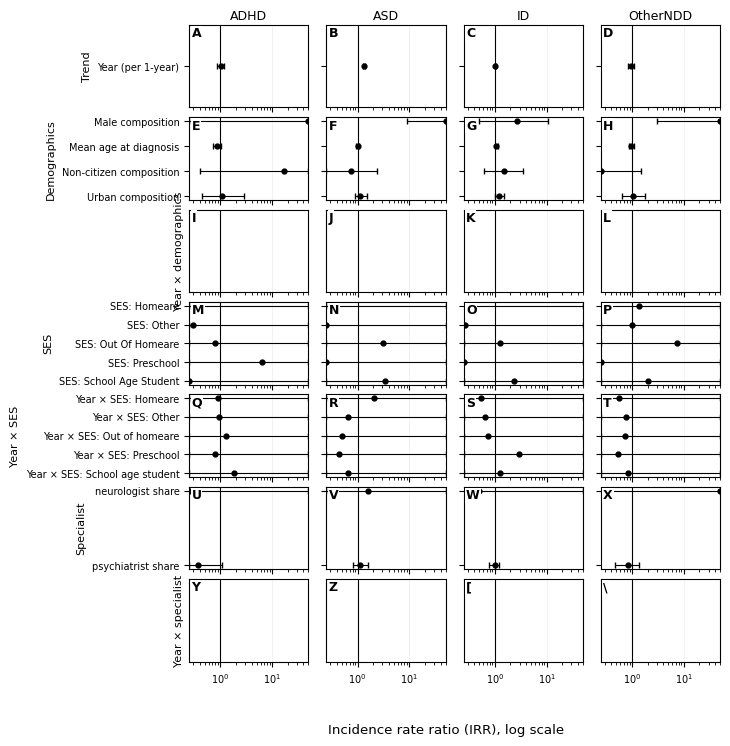

Saved:
- Figure_5_Forest_IRR_NB_Trend_Adjusted.tif
- Figure_5_Forest_IRR_NB_Trend_Adjusted.eps


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Figure: Forest plot with blocks × disorders
# From Bayesian NB mixed models (Bambi):
# Input: fixed_effects_table with columns:
#   - Disorder
#   - Predictor
#   - IRR (95% CrI)
# =========================================================

# -------------------------
# CONFIG (EDIT ONLY HERE)
# -------------------------
FIG_NUM = 5
OUT_BASE = f"Figure_{FIG_NUM}_Forest_IRR_NB_Trend_Adjusted"

# Must match values in fixed_effects_table["Disorder"]
DISORDER_ORDER = ["ADHD", "ASD", "ID", "OtherNDD"]

# Blocks now match your OR forest structure + trend/interactions
BLOCK_ORDER = [
    "Trend",
    "Demographics",
    "Year × demographics",
    "SES",
    "Year × SES",
    "Specialist",
    "Year × specialist",
]

# Cambridge size / export (combination artwork)
FIG_WIDTH_MM = 174
FIG_HEIGHT_MM = 210  # taller for 7 blocks
INCH_PER_MM = 1 / 25.4
FIGSIZE = (FIG_WIDTH_MM * INCH_PER_MM, FIG_HEIGHT_MM * INCH_PER_MM)
DPI_TIFF = 800

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

# -------------------------
# Helpers
# -------------------------
def parse_irr(s):
    """Parse '1.23 (1.01, 1.56)' -> (1.23, 1.01, 1.56)."""
    try:
        s = str(s).strip()
        est = float(s.split(" ", 1)[0])
        inside = s.split("(", 1)[1].split(")", 1)[0]
        lo = float(inside.split(",", 1)[0].strip())
        hi = float(inside.split(",", 1)[1].strip())
        return est, lo, hi
    except Exception:
        return np.nan, np.nan, np.nan

def clip_limits_for_log(lo, hi, q=(0.02, 0.98), hard=(0.05, 50)):
    vals = np.concatenate([np.asarray(lo), np.asarray(hi)])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) == 0:
        return 0.2, 5.0
    xmin = np.exp(np.quantile(np.log(vals), q[0]))
    xmax = np.exp(np.quantile(np.log(vals), q[1]))
    xmin = max(xmin, hard[0])
    xmax = min(xmax, hard[1])
    return float(xmin), float(xmax)

# --- Block classifier for *pretty predictor strings* ---
def block_name(predictor: str) -> str:
    p = str(predictor)

    if p == "Year (per 1-year increase)":
        return "Trend"

    demo_main = {
        "Male composition (centered)",
        "Urban composition (centered)",
        "Non-citizen composition (centered)",
        "Mean age at diagnosis (centered)",
    }
    if p in demo_main:
        return "Demographics"

    if p.startswith("Year × ") and any(
        k in p for k in ["Male composition", "Urban composition", "Non-citizen composition", "Mean age at diagnosis"]
    ):
        return "Year × demographics"

    if p.startswith("SES:"):
        return "SES"
    if p.startswith("Year × SES:"):
        return "Year × SES"

    # Specialist shares (anything with "share (centered)" that isn't SES)
    if ("share (centered)" in p) and (not p.startswith("Year ×")) and (not p.startswith("SES:")):
        return "Specialist"
    if p.startswith("Year ×") and ("share (centered)" in p) and ("SES:" not in p):
        return "Year × specialist"

    return "DROP"

def pretty_predictor(p: str) -> str:
    p = str(p)

    if p == "Year (per 1-year increase)":
        return "Year (per 1-year)"

    # remove "(centered)" everywhere for compact y labels
    p = p.replace(" (centered)", "")
    p = p.replace(" share (centered)", " share")  # in case some still carry it

    return p

# -------------------------
# 0) Build tbl from fixed_effects_table
# -------------------------
need_cols = {"Disorder", "Predictor", "IRR (95% CrI)"}
missing = need_cols - set(fixed_effects_table.columns)
if missing:
    raise KeyError(
        f"fixed_effects_table missing columns: {missing}. "
        f"Available: {list(fixed_effects_table.columns)}"
    )

tbl = fixed_effects_table.copy()

# Drop intercept (not plotted)
tbl = tbl[tbl["Predictor"] != "Intercept"].copy()

# Keep disorders in order
tbl = tbl[tbl["Disorder"].isin(DISORDER_ORDER)].copy()
tbl["Disorder"] = pd.Categorical(tbl["Disorder"], categories=DISORDER_ORDER, ordered=True)

# Parse IRR
tbl[["irr", "lo", "hi"]] = tbl["IRR (95% CrI)"].apply(lambda x: pd.Series(parse_irr(x)))
tbl = tbl.dropna(subset=["irr", "lo", "hi"]).copy()

# Assign blocks
tbl["Block"] = tbl["Predictor"].apply(block_name)
tbl = tbl[tbl["Block"].isin(BLOCK_ORDER)].copy()
tbl["Block"] = pd.Categorical(tbl["Block"], categories=BLOCK_ORDER, ordered=True)

# Pretty y labels
tbl["Predictor_label"] = tbl["Predictor"].apply(pretty_predictor)

# Shared x limits
xmin, xmax = clip_limits_for_log(tbl["lo"].values, tbl["hi"].values)

# Per-block stable order (Predictor is the key; labels are display)
terms_by_block = {}
label_by_predictor = {}

for b in BLOCK_ORDER:
    tmp = (
        tbl.loc[tbl["Block"] == b, ["Predictor", "Predictor_label"]]
           .drop_duplicates()
           .sort_values("Predictor_label")
    )
    terms_by_block[b] = tmp["Predictor"].tolist()
    label_by_predictor.update(dict(zip(tmp["Predictor"], tmp["Predictor_label"])))

# -------------------------
# Plot: rows=blocks, cols=disorders
# -------------------------
nrows = len(BLOCK_ORDER)
ncols = len(DISORDER_ORDER)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=FIGSIZE,
    sharex=True,
    gridspec_kw=dict(wspace=0.15, hspace=0.12)
)
axes = np.atleast_2d(axes)

panel_letters = [chr(ord("A") + i) for i in range(nrows * ncols)]
k = 0

for r, block in enumerate(BLOCK_ORDER):
    terms = terms_by_block[block]
    y = np.arange(len(terms))[::-1]
    term_to_y = {t: y[i] for i, t in enumerate(terms)}

    for c, disorder in enumerate(DISORDER_ORDER):
        ax = axes[r, c]
        sub = tbl[(tbl["Block"] == block) & (tbl["Disorder"] == disorder)].copy()

        # Deduplicate predictors within this panel (Predictor must be unique for reindex)
        # If duplicates exist, keep the row with the narrowest CrI (most precise).
        if not sub.empty and sub["Predictor"].duplicated().any():
            sub = sub.assign(ci_width=sub["hi"] - sub["lo"])
            sub = (
                sub.sort_values(["ci_width"])  # narrowest first
                   .drop_duplicates(subset=["Predictor"], keep="first")
                   .drop(columns=["ci_width"])
            )

        # Reindex to full term list
        sub = sub.set_index("Predictor").reindex(terms).reset_index()
        sub["ypos"] = sub["Predictor"].map(term_to_y)

        # Clip for plotting only
        sub["lo_p"]  = sub["lo"].clip(lower=xmin, upper=xmax)
        sub["hi_p"]  = sub["hi"].clip(lower=xmin, upper=xmax)
        sub["irr_p"] = sub["irr"].clip(lower=xmin, upper=xmax)

        m = np.isfinite(sub["irr_p"]) & np.isfinite(sub["lo_p"]) & np.isfinite(sub["hi_p"])
        if m.any():
            ax.errorbar(
                sub.loc[m, "irr_p"].values,
                sub.loc[m, "ypos"].values,
                xerr=np.vstack([
                    sub.loc[m, "irr_p"].values - sub.loc[m, "lo_p"].values,
                    sub.loc[m, "hi_p"].values - sub.loc[m, "irr_p"].values
                ]),
                fmt="o",
                capsize=2,
                linewidth=0.8,
                markersize=3.5,
                color="0.0",
            )

        ax.axvline(1.0, linewidth=0.8, color="0.0")
        ax.set_xscale("log")
        ax.set_xlim(xmin, xmax)

        if r == 0:
            ax.set_title(disorder, pad=4)

        if c == 0:
            ax.set_yticks(y)
            ax.set_yticklabels([label_by_predictor.get(t, str(t)) for t in terms])
            ax.set_ylabel(block)
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

        ax.grid(axis="x", alpha=0.25, linewidth=0.5)
        ax.grid(False, axis="y")

        ax.text(
            0.02, 0.98, panel_letters[k],
            transform=ax.transAxes, va="top", ha="left",
            fontsize=9, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6)
        )
        k += 1

fig.supxlabel("Incidence rate ratio (IRR), log scale", y=0.02)
plt.tight_layout(rect=[0.25, 0.05, 1, 1])

fig.savefig(f"{OUT_BASE}.tif", dpi=DPI_TIFF, format="tiff", bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.eps", format="eps", bbox_inches="tight")
plt.show()

print("Saved:")
print(f"- {OUT_BASE}.tif")
print(f"- {OUT_BASE}.eps")


In [ ]:
dups = (
    tbl.groupby(["Disorder", "Block", "Predictor"])
       .size()
       .reset_index(name="n")
       .query("n > 1")
       .sort_values(["Disorder", "Block", "n"], ascending=[True, True, False])
)
dups.head(50)


/tmp/ipython-input-2700551227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl.groupby(["Disorder", "Block", "Predictor"])


,Disorder,Block,Predictor,n
54,ADHD,SES,SES: Homeare (centered),3
55,ADHD,SES,SES: Other (centered),3
56,ADHD,SES,SES: Out Of Homeare (centered),3
57,ADHD,SES,SES: Preschool (centered),3
58,ADHD,SES,SES: School Age Student (centered),2
78,ADHD,Year × SES,Year × SES: Homeare (centered),3
79,ADHD,Year × SES,Year × SES: Other (centered),3
80,ADHD,Year × SES,Year × SES: Out of homeare (centered),3
81,ADHD,Year × SES,Year × SES: Preschool (centered),3
82,ADHD,Year × SES,Year × SES: School age student (centered),2


/tmp/ipython-input-46857080.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["registry_year", "region_std", "ndd4"])
/tmp/ipython-input-46857080.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["registry_year", "region_std", "specialist_group"])
/tmp/ipython-input-46857080.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spec_counts.groupby(["registry_year", "region_std"])["n_spec

agg rows: 752
years: 2014 - 2024
ndd4 counts:
 ndd4
ADHD        188
ASD         188
ID          188
OtherNDD    188
Name: count, dtype: int64

Formula:
 n_cases ~ year_c + psychiatrist_c + neurologist_c + psychologist_c + year_c:psychiatrist_c + year_c:neurologist_c + year_c:psychologist_c + ndd4 + year_c:ndd4 + (1 + year_c|region_std) + offset(offset_log)


Output()

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
year_c -0.024  0.033  -0.085    0.036      0.001    0.001    1353.0    1547.0   

        r_hat  
year_c    1.0  

=== Fixed effects (IRR table) ===
                                   term            IRR (95% CrI)  ess_bulk  \
21                            Intercept        0.00 (0.00, 0.00)     717.0   
23                            ndd4[ASD]     41.18 (33.75, 51.94)    2061.0   
24                             ndd4[ID]  159.02 (126.85, 198.15)    1888.0   
25                       ndd4[OtherNDD]     19.01 (15.52, 23.67)    2198.0   
26                        neurologist_c  2.26 (0.00, 3960971.97)    1405.0   
27                       psychiatrist_c        0.87 (0.51, 1.45)    1930.0   
28                       psychologist_c    0.29 (0.00, 30091.56)    2037.0   
29                               year_c        0.98 (0.92, 1.04)    1353.0   
30                     year_c:ndd4[ASD]        1.28 (1.19, 1.37)    

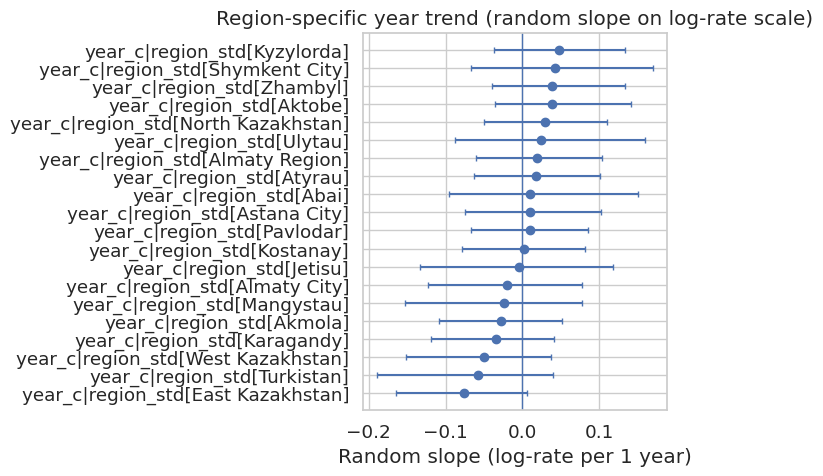

In [ ]:
# ==========================================
# Trend model: region-year disorder counts
# Negative Binomial hierarchical model
# with year interactions for specialist shares
# ==========================================

# ------------------------------
# A0) SWITCHES / SETTINGS
# ------------------------------
YEAR_MIN, YEAR_MAX = 2014, 2024
CHILD_AGE_MAX = 15

# Choose offset interpretation:
#   "population"    -> model prevalence-rate counts with offset(log(population))
#   "registry_total"-> model composition/intensity within registry with offset(log(total registry N in region-year))
OFFSET_MODE = "population"

# Denominator table (must contain region_std, year, and POP_COL)
DENOM_DF = gov_pop_full.copy()
POP_COL = "total"  # change to "under18_total" if you have it

# Specialist groups to include as region-year composition predictors.
# Must match df["specialist_group"] values EXACTLY.
KEEP_SPECS = ["psychiatrist", "neurologist", "psychologist"]

# Map disorder_category into 4 groups (edit keys to match your df values)
DISORDER_MAP = {
    "asd": "ASD",
    "adhd": "ADHD",
    "intellectual_disability": "ID",
    "developmental_disorder": "OtherNDD",
    "tic_disorder": "OtherNDD",  # fold tics into OtherNDD
}

# If your df already has "diagnosis_group" or "disorder_mlm"/"ndd4", set this:
USE_EXISTING_GROUP_COL = None
# e.g. USE_EXISTING_GROUP_COL = "diagnosis_group"
# or USE_EXISTING_GROUP_COL = "disorder_mlm"
# or USE_EXISTING_GROUP_COL = "ndd4"

# Fit settings (increase target_accept if you see divergences)
fit_fast  = dict(draws=1200, tune=1200, chains=2, cores=2, target_accept=0.95, random_seed=42)
fit_final = dict(draws=2500, tune=2500, chains=2, cores=2, target_accept=0.97, random_seed=42)

# Model options
INCLUDE_DISORDER_EFFECTS = True   # pooled multi-disorder model
ALLOW_DISORDER_TRENDS = True      # year_c:ndd4 (different slopes per disorder)
INCLUDE_REGION_RANDOM_SLOPE = True  # (1 + year_c | region_std)

# ------------------------------
# A1) PREP: children-only + year window + grouping
# ------------------------------
data = df.copy()

# children-only
data = data.loc[data["age_exam_reported"].astype(float) < CHILD_AGE_MAX].copy()

# year window
data = data.loc[(data["registry_year"] >= YEAR_MIN) & (data["registry_year"] <= YEAR_MAX)].copy()

# core required cols
req = ["registry_year", "region_std", "specialist_group"]
missing = [c for c in req if c not in data.columns]
if missing:
    raise KeyError(f"Missing required columns in df: {missing}")

# ndd4 grouping
if USE_EXISTING_GROUP_COL is not None:
    data["ndd4"] = data[USE_EXISTING_GROUP_COL].copy()
else:
    if "disorder_category" not in data.columns:
        raise KeyError("df must contain 'disorder_category' OR set USE_EXISTING_GROUP_COL.")
    data["ndd4"] = data["disorder_category"].map(DISORDER_MAP)

data = data.dropna(subset=["ndd4", "registry_year", "region_std", "specialist_group"]).copy()

# standardize types
data["region_std"] = data["region_std"].astype("category")
data["ndd4"] = data["ndd4"].astype("category")
data["specialist_group"] = data["specialist_group"].astype("category")

# ------------------------------
# A2) AGGREGATE COUNTS: region × year × disorder
# ------------------------------
counts = (
    data.groupby(["registry_year", "region_std", "ndd4"])
        .size()
        .rename("n_cases")
        .reset_index()
)

# ------------------------------
# A3) SPECIALIST COMPOSITION: region × year shares
# ------------------------------
# --- A3 robust: specialist shares with complete region-year grid ---
spec_counts = (
    data.groupby(["registry_year", "region_std", "specialist_group"])
        .size().rename("n_spec").reset_index()
)

# total per region-year
spec_totals = (
    spec_counts.groupby(["registry_year", "region_std"])["n_spec"]
               .sum().rename("n_total_spec").reset_index()
)

spec = spec_counts.merge(spec_totals, on=["registry_year","region_std"], how="left")
spec["share"] = spec["n_spec"] / spec["n_total_spec"]

# complete grid of all region-year pairs present in counts table
grid = counts[["registry_year","region_std"]].drop_duplicates()

spec_wide = (
    spec.pivot_table(index=["registry_year","region_std"],
                     columns="specialist_group",
                     values="share",
                     aggfunc="mean")
    .reset_index()
)

spec_wide = grid.merge(spec_wide, on=["registry_year","region_std"], how="left")

# keep selected spec types; if absent, create; then fill NA with 0
for s in KEEP_SPECS:
    if s not in spec_wide.columns:
        spec_wide[s] = 0.0
spec_wide[KEEP_SPECS] = spec_wide[KEEP_SPECS].fillna(0.0)

# center
for s in KEEP_SPECS:
    spec_wide[f"{s}_c"] = spec_wide[s] - spec_wide[s].mean()


# ------------------------------
# A4) BUILD MODEL TABLE: counts + shares + offset
# ------------------------------
agg = counts.merge(spec_wide, on=["registry_year", "region_std"], how="left")

# Center year (global)
agg["year_c"] = agg["registry_year"].astype(float) - agg["registry_year"].astype(float).mean()

# Offsets
if OFFSET_MODE == "population":
    denom = DENOM_DF.copy()
    if "year" in denom.columns and "registry_year" not in denom.columns:
        denom = denom.rename(columns={"year": "registry_year"})
    denom = denom.loc[(denom["registry_year"] >= YEAR_MIN) & (denom["registry_year"] <= YEAR_MAX)].copy()

    need = ["registry_year", "region_std", POP_COL]
    miss = [c for c in need if c not in denom.columns]
    if miss:
        raise KeyError(f"DENOM_DF missing columns: {miss}")

    denom = denom[need].dropna().copy()
    denom[POP_COL] = pd.to_numeric(denom[POP_COL], errors="coerce")
    denom = denom.dropna(subset=[POP_COL]).copy()

    agg = agg.merge(denom, on=["registry_year", "region_std"], how="left")
    agg = agg.dropna(subset=[POP_COL]).copy()
    agg["offset_log"] = np.log(agg[POP_COL].astype(float))

elif OFFSET_MODE == "registry_total":
    reg_tot = (
        data.groupby(["registry_year", "region_std"])
            .size()
            .rename("reg_total")
            .reset_index()
    )
    agg = agg.merge(reg_tot, on=["registry_year", "region_std"], how="left")
    agg["offset_log"] = np.log(agg["reg_total"].astype(float))

else:
    raise ValueError("OFFSET_MODE must be 'population' or 'registry_total'.")

# Categorical dtypes for modeling
agg["region_std"] = agg["region_std"].astype("category")
agg["ndd4"] = agg["ndd4"].astype("category")

# Quick sanity prints
print("agg rows:", len(agg))
print("years:", agg["registry_year"].min(), "-", agg["registry_year"].max())
print("ndd4 counts:\n", agg["ndd4"].value_counts())

# ------------------------------
# A5) MODEL FORMULA
# ------------------------------
# Fixed part
fixed_terms = ["year_c"]
fixed_terms += [f"{s}_c" for s in KEEP_SPECS]
fixed_terms += [f"year_c:{s}_c" for s in KEEP_SPECS]  # interactions

if INCLUDE_DISORDER_EFFECTS:
    fixed_terms += ["ndd4"]
    if ALLOW_DISORDER_TRENDS:
        fixed_terms += ["year_c:ndd4"]

fixed_str = " + ".join(fixed_terms)

# Random part
rand_terms = ["(1|region_std)"]
if INCLUDE_REGION_RANDOM_SLOPE:
    rand_terms = ["(1 + year_c|region_std)"]  # adoption speed by region

# (Optional) shrinkage across disorders (random intercept by disorder)
# If you include ndd4 as fixed, (1|ndd4) is usually redundant; keep OFF by default.
rand_str = " + ".join(rand_terms)

formula_nb = f"n_cases ~ {fixed_str} + {rand_str} + offset(offset_log)"
print("\nFormula:\n", formula_nb)

# ------------------------------
# A6) FIT MODEL
# ------------------------------
model_nb = bmb.Model(formula_nb, data=agg, family="negativebinomial")
idata_nb = model_nb.fit(**fit_fast)  # swap to fit_final when stable

print(az.summary(idata_nb, var_names=["year_c"]))

# ------------------------------
# B1) CLEAN IRR TABLE (fixed effects)
# ------------------------------
def extract_irr_table(idata, terms=None, hdi=0.95, decimals=2):
    if terms is None:
        # Pull all fixed effects Bambi stores under "Intercept" and "..."
        # We'll just request all "b" coefficients (common bambi naming).
        terms = ["Intercept", "year_c"] + [f"{s}_c" for s in KEEP_SPECS] + [f"year_c:{s}_c" for s in KEEP_SPECS]
        if INCLUDE_DISORDER_EFFECTS:
            # Bambi names factor terms like ndd4[ASD], year_c:ndd4[ASD], etc.
            # We'll include "ndd4" and "year_c:ndd4" patterns via regex filter in az.summary:
            pass

    # Grab all coefficients; use filter later
    summ = az.summary(idata, hdi_prob=hdi).reset_index().rename(columns={"index": "term"})
    # Keep fixed effects only (exclude random sd terms etc.)
    # Bambi fixed effects commonly start with: "Intercept", "year_c", "<var>_c", "ndd4[...]", "year_c:ndd4[...]"
    keep_mask = (
        summ["term"].eq("Intercept")
        | summ["term"].str.startswith("year_c")
        | summ["term"].str.endswith("_c")
        | summ["term"].str.contains(r"^ndd4\[", regex=True)
        | summ["term"].str.contains(r"^year_c:ndd4\[", regex=True)
        | summ["term"].str.contains(r":.*_c$", regex=True)
    )
    summ = summ.loc[keep_mask].copy()

    # IRR and interval
    summ["IRR"] = np.exp(summ["mean"])
    summ["IRR_low"] = np.exp(summ[f"hdi_{int((1-hdi)/2*100)}%"] if f"hdi_{int((1-hdi)/2*100)}%" in summ.columns else summ.filter(like="hdi_").iloc[:,0])
    summ["IRR_high"] = np.exp(summ[f"hdi_{int((1+(hdi))/2*100)}%"] if f"hdi_{int((1+(hdi))/2*100)}%" in summ.columns else summ.filter(like="hdi_").iloc[:,1])

    # robust: use explicit common names
    hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
    if len(hdi_cols) >= 2:
        hdi_cols = sorted(hdi_cols, key=lambda x: float(x.replace("hdi_", "").replace("%", "")))
        summ["IRR_low"] = np.exp(summ[hdi_cols[0]])
        summ["IRR_high"] = np.exp(summ[hdi_cols[-1]])

    summ["IRR (95% CrI)"] = summ.apply(
        lambda r: f"{r['IRR']:.{decimals}f} ({r['IRR_low']:.{decimals}f}, {r['IRR_high']:.{decimals}f})",
        axis=1
    )

    out = summ[["term", "IRR (95% CrI)", "ess_bulk", "r_hat"]].copy()
    return out.sort_values("term")

irr_table = extract_irr_table(idata_nb, hdi=0.95, decimals=2)
print("\n=== Fixed effects (IRR table) ===")
print(irr_table)

# ------------------------------
# B2) REGION RANDOM-SLOPE FOREST PLOT (year trend by region)
# ------------------------------
def plot_region_year_slopes(idata, top_n=20):
    # Find the random-slope parameter name (Bambi naming varies a bit)
    candidates = [v for v in idata.posterior.data_vars if "year_c|region_std" in v]
    if len(candidates) == 0:
        raise KeyError("Can't find random-slope term. Print idata.posterior.data_vars to inspect.")
    vname = candidates[0]  # e.g., "year_c|region_std"

    da = idata.posterior[vname]  # dims typically: chain, draw, region_std
    if "region_std" not in da.dims:
        # sometimes the coord name is something like "year_c|region_std_dim"
        region_dim = [d for d in da.dims if "region" in d][0]
    else:
        region_dim = "region_std"

    # Summaries per region
    summ = az.summary(da, hdi_prob=0.95).reset_index().rename(columns={"index": "region"})
    # az.summary returns mean + hdi_2.5%/97.5% (or hdi_3%/97% depending)
    lo_col = [c for c in summ.columns if c.startswith("hdi_")][0]
    hi_col = [c for c in summ.columns if c.startswith("hdi_")][1]

    # pick most extreme slopes
    summ["abs_mean"] = summ["mean"].abs()
    top = summ.sort_values("abs_mean", ascending=False).head(top_n)

    # forest-style plot
    top = top.sort_values("mean")
    y = np.arange(len(top))

    plt.figure(figsize=(7, max(4, 0.25 * len(top))))
    plt.errorbar(
        x=top["mean"].values,
        y=y,
        xerr=np.vstack([top["mean"] - top[lo_col], top[hi_col] - top["mean"]]),
        fmt="o",
        capsize=2,
    )
    plt.yticks(y, top["region"].values)
    plt.axvline(0, linewidth=1)
    plt.title("Region-specific year trend (random slope on log-rate scale)")
    plt.xlabel("Random slope (log-rate per 1 year)")
    plt.tight_layout()
    plt.show()

# call
plot_region_year_slopes(idata_nb, top_n=20)

# ------------------------------
# B3) OPTIONAL: posterior predicted trends for selected regions
# ------------------------------
def plot_predicted_trends(model, idata, regions, disorders=None, years=None, n_draws=300):
    if years is None:
        years = np.arange(YEAR_MIN, YEAR_MAX + 1)

    if disorders is None:
        disorders = sorted(agg["ndd4"].astype(str).unique())

    # Build prediction frame
    rows = []
    for r in regions:
        for d in disorders:
            for y in years:
                rows.append({"region_std": r, "ndd4": d, "registry_year": int(y)})
    new = pd.DataFrame(rows)

    # merge specialist shares (use mean if missing)
    spec_lookup = spec_wide.copy()
    new = new.merge(spec_lookup, on=["registry_year", "region_std"], how="left")
    for s in KEEP_SPECS:
        new[f"{s}_c"] = new[f"{s}_c"].fillna(spec_lookup[f"{s}_c"].mean())

    # offsets
    new["year_c"] = new["registry_year"].astype(float) - agg["registry_year"].astype(float).mean()

    if OFFSET_MODE == "population":
        denom = DENOM_DF.copy()
        if "year" in denom.columns and "registry_year" not in denom.columns:
            denom = denom.rename(columns={"year": "registry_year"})
        denom = denom[["registry_year", "region_std", POP_COL]].copy()
        denom[POP_COL] = pd.to_numeric(denom[POP_COL], errors="coerce")
        new = new.merge(denom, on=["registry_year", "region_std"], how="left")
        new[POP_COL] = new[POP_COL].fillna(np.nanmedian(denom[POP_COL]))
        new["offset_log"] = np.log(new[POP_COL].astype(float))
    else:
        reg_tot = data.groupby(["registry_year", "region_std"]).size().rename("reg_total").reset_index()
        new = new.merge(reg_tot, on=["registry_year", "region_std"], how="left")
        new["reg_total"] = new["reg_total"].fillna(new["reg_total"].median())
        new["offset_log"] = np.log(new["reg_total"].astype(float))

    # categories
    new["region_std"] = new["region_std"].astype("category")
    new["ndd4"] = new["ndd4"].astype("category")

    # Predict expected counts (posterior mean)
    # bambi: use model.predict with kind="mean"
    pred = model.predict(idata, data=new, kind="mean", inplace=False)

    # pred is an xarray; convert
    # We'll take posterior mean over draws for each row.
    # Name usually: "n_cases_mean" but can differ; find first var
    v = list(pred.data_vars)[0]
    arr = pred[v].stack(sample=("chain", "draw"))

    # optionally thin draws
    if arr.sizes["sample"] > n_draws:
        idx = np.random.default_rng(0).choice(arr.sizes["sample"], size=n_draws, replace=False)
        arr = arr.isel(sample=idx)

    mean = arr.mean("sample").values
    new["_mu"] = mean

    # Plot per disorder panels (simple)
    for d in disorders:
        plt.figure(figsize=(8, 4.5))
        for r in regions:
            sub = new[(new["ndd4"].astype(str) == str(d)) & (new["region_std"].astype(str) == str(r))].copy()
            sub = sub.sort_values("registry_year")
            plt.plot(sub["registry_year"], sub["_mu"])
        plt.title(f"Posterior mean expected counts: {d}")
        plt.xlabel("Year")
        plt.ylabel("Expected cases (count scale)")
        plt.tight_layout()
        plt.show()

# Example usage:
# plot_predicted_trends(model_nb, idata_nb, regions=["Astana City", "Almaty City"], disorders=["ASD", "ID"])


# MLM general

In [ ]:
# =========================
# 1. Base table: region-year case counts + population
# =========================

reg_year_counts = (
    df.groupby(["region_std", "registry_year"])
      .size()
      .rename("n_cases")
      .reset_index()
)

mlm_df = reg_year_counts.merge(
    gov_pop_clean.rename(columns={"year": "registry_year"}),
    on=["region_std", "registry_year"],
    how="left"
)

mlm_df = mlm_df.dropna(subset=["total"])

mlm_df["prevalence_per_100k"] = mlm_df["n_cases"] / mlm_df["total"] * 100000
mlm_df["urban_rate"] = mlm_df["urban"] / mlm_df["total"]
mlm_df["rural_rate"] = mlm_df["rural"] / mlm_df["total"]

mlm_df = mlm_df.rename(columns={"registry_year": "year"})


# =========================
# 2. SES composition per region-year (using *grouped* SES_group)
# =========================
# Assumes df['SES_group'] already has the collapsed categories you defined earlier

ses_counts = (
    df.groupby(["region_std", "registry_year", "SES_group"])
      .size()
      .rename("n_ses")
      .reset_index()
)

# Wide: one column per SES_group, values = counts
ses_wide = ses_counts.pivot_table(
    index=["region_std", "registry_year"],
    columns="SES_group",
    values="n_ses",
    fill_value=0
)

# Convert counts → proportions within region-year
ses_wide = ses_wide.div(ses_wide.sum(axis=1), axis=0)

ses_wide = ses_wide.reset_index()
ses_wide.columns.name = None

# Auto-generate clean column names for SES groups
ses_cols = [c for c in ses_wide.columns if c not in ["region_std", "registry_year"]]

ses_rename = {
    c: "SES_" + re.sub(r"[^0-9A-Za-z]+", "_", str(c)).strip("_").lower()
    for c in ses_cols
}

ses_wide = ses_wide.rename(columns=ses_rename)

# Merge into mlm_df
mlm_df = mlm_df.merge(
    ses_wide,
    left_on=["region_std", "year"],
    right_on=["region_std", "registry_year"],
    how="left"
)

mlm_df = mlm_df.drop(columns=["registry_year"], errors="ignore")


# =========================
# 3. Sex composition per region-year
# =========================

sex_counts = (
    df.groupby(["region_std", "registry_year", "sex_std"])
      .size()
      .rename("n_sex")
      .reset_index()
)

sex_wide = sex_counts.pivot_table(
    index=["region_std", "registry_year"],
    columns="sex_std",
    values="n_sex",
    fill_value=0
).reset_index()

sex_wide.columns.name = None

sex_rename = {}
for c in sex_wide.columns:
    if c == "Male":
        sex_rename[c] = "n_male"
    elif c == "Female":
        sex_rename[c] = "n_female"

sex_wide = sex_wide.rename(columns=sex_rename)

if "n_male" in sex_wide.columns and "n_female" in sex_wide.columns:
    sex_wide["n_total_sex"] = sex_wide["n_male"] + sex_wide["n_female"]
    sex_wide["prop_male"] = sex_wide["n_male"] / sex_wide["n_total_sex"]
    sex_wide["prop_female"] = sex_wide["n_female"] / sex_wide["n_total_sex"]

mlm_df = mlm_df.merge(
    sex_wide,
    left_on=["region_std", "year"],
    right_on=["region_std", "registry_year"],
    how="left"
)

mlm_df = mlm_df.drop(columns=["registry_year"], errors="ignore")


# =========================
# 4. Age summary per region-year
# =========================

age_summary = (
    df.groupby(["region_std", "registry_year"])["age_at_diag_final"]
      .agg(
          age_mean="mean",
          age_median="median",
          age_sd="std",
          age_q25=lambda x: x.quantile(0.25),
          age_q75=lambda x: x.quantile(0.75),
      )
      .reset_index()
)

mlm_df = mlm_df.merge(
    age_summary,
    left_on=["region_std", "year"],
    right_on=["region_std", "registry_year"],
    how="left"
)

mlm_df = mlm_df.drop(columns=["registry_year"], errors="ignore")


# =========================
# 5. Disorder composition per region-year (proportions)
# =========================

dis_counts = (
    df.groupby(["region_std", "registry_year", "disorder_category"])
      .size()
      .rename("n_disorder")
      .reset_index()
)

dis_wide = dis_counts.pivot_table(
    index=["region_std", "registry_year"],
    columns="disorder_category",
    values="n_disorder",
    fill_value=0
)

dis_wide = dis_wide.div(dis_wide.sum(axis=1), axis=0).reset_index()
dis_wide.columns.name = None

mlm_df = mlm_df.merge(
    dis_wide,
    left_on=["region_std", "year"],
    right_on=["region_std", "registry_year"],
    how="left"
)

mlm_df = mlm_df.drop(columns=["registry_year"], errors="ignore")


# =========================
# 6. Final cleaning & check
# =========================

mlm_df = mlm_df.dropna(subset=["total"])
mlm_df = mlm_df.sort_values(["region_std", "year"]).reset_index(drop=True)

print("MLM dataframe shape:", mlm_df.shape)
print(mlm_df.filter(regex="^SES_", axis=1).head())  # quick check of SES cols
print(mlm_df.head())


MLM dataframe shape: (182, 31)
   SES_early_childhood  SES_employed_household  SES_other  \
0             0.184397                0.012214   0.359338   
1             0.201337                0.010401   0.327637   
2             0.021700                0.119203   0.647444   
3             0.025289                0.109689   0.638026   
4             0.028489                0.094110   0.628361   

   SES_retired_other_adult  SES_school_age  SES_unemployed_household  \
0                 0.006698        0.053586                  0.108747   
1                 0.005572        0.052377                  0.095468   
2                 0.005054        0.028240                  0.077289   
3                 0.005180        0.042352                  0.075259   
4                 0.005442        0.050576                  0.073303   

   SES_vulnerable  
0        0.275020  
1        0.307207  
2        0.101070  
3        0.104205  
4        0.119718  
  region_std  year  n_cases     total     urban  

In [ ]:
# ---------- 0. Prepare data ----------
mlm = mlm_df.copy()

required_cols = [
    "n_cases", "total", "year", "urban_rate",
    "prop_male", "age_mean"
]
mlm = mlm.dropna(subset=[c for c in required_cols if c in mlm.columns])

# Center year and age
mlm["year_c"] = mlm["year"] - mlm["year"].mean()
mlm["age_mean_c"] = mlm["age_mean"] - mlm["age_mean"].mean()

# Log population (acts as quasi-offset / exposure)
mlm["log_pop"] = np.log(mlm["total"])

# (optional) check SES columns present
ses_cols = []  # fill with your SES_* columns if you want to add them

base_predictors = ["year_c", "urban_rate", "prop_male", "age_mean_c", "log_pop"]
rhs_terms = base_predictors + ses_cols
rhs = " + ".join(rhs_terms)

formula = f"n_cases ~ {rhs} + (1|region_std)"
print("Using formula:")
print(formula)

# ---------- 1. Specify and fit model ----------
model = bmb.Model(
    formula=formula,
    data=mlm,
    family="poisson"
)

idata = model.fit(
    draws=3000,
    chains=4,
    target_accept=0.95,
    init="adapt_diag",
    nuts={"max_treedepth": 15},
)

# ---------- 2. Inspect ----------

# Optional posterior predictive check
ppc = model.predict(idata=idata, kind="pps")

pp_mean = ppc.mean("chain").mean("draw").to_series()

pp_df = pd.DataFrame({
    "region_std": mlm["region_std"].values,
    "year": mlm["year"].values,
    "n_cases_obs": mlm["n_cases"].values,
    "n_cases_pred": pp_mean.values,
})
pp_df.head()


 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.007       1023         9.90 draws/s     0:05:02   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.014       383          5.11 draws/s     0:09:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.013       511          3.67 draws/s     0:13:36   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.012       439          2.98 draws/s     0:16:44   0:00:00

AttributeError: 'Model' object has no attribute 'summary'

In [ ]:
# Full summary of all parameters
az.summary(idata)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|region_std[Abai],0.806,0.123,0.573,1.045,0.004,0.003,1011.0,1438.0,1.00
1|region_std[Akmola],0.313,0.123,0.059,0.533,0.004,0.003,1015.0,1282.0,1.00
1|region_std[Aktobe],-0.164,0.123,-0.405,0.060,0.004,0.003,1010.0,1435.0,1.00
1|region_std[Almaty City],-0.973,0.127,-1.224,-0.743,0.004,0.003,1066.0,1748.0,1.00
1|region_std[Almaty Region],-0.302,0.126,-0.558,-0.077,0.004,0.003,1034.0,1450.0,1.00
1|region_std[Astana City],-0.645,0.126,-0.881,-0.405,0.004,0.003,1046.0,1771.0,1.00
1|region_std[Atyrau],0.629,0.123,0.393,0.861,0.004,0.003,1014.0,1386.0,1.00
1|region_std[East Kazakhstan],0.167,0.123,-0.072,0.394,0.004,0.003,1008.0,1520.0,1.00
1|region_std[Jetisu],-0.014,0.125,-0.243,0.230,0.004,0.003,1060.0,1387.0,1.00
1|region_std[Karagandy],0.108,0.124,-0.129,0.339,0.004,0.003,1022.0,1665.0,1.00


# Spec / Reg + Bernoulli MLM

/tmp/ipython-input-2586970983.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_share)


shares head:
    registry_year region_std specialist_group     n  n_region_total     share
0           2014       Abai  other_physician   577            1959  0.294538
1           2014       Abai     psychiatrist   317            1959  0.161817
2           2014       Abai     psychologist     9            1959  0.004594
3           2014       Abai    public_health  1056            1959  0.539051
4           2014     Akmola        gp_family   256            3364  0.076100

HHI head:
    registry_year     region_std  HHI_specialist_concentration
0           2014           Abai                      0.403534
1           2014         Akmola                      0.355131
2           2014         Aktobe                      0.252165
3           2014    Almaty City                      0.291960
4           2014  Almaty Region                      0.516224

trend head:
   region_std specialist_group  b_share_per_year  n_years
0       Abai        gp_family               NaN      2.0
1       Abai

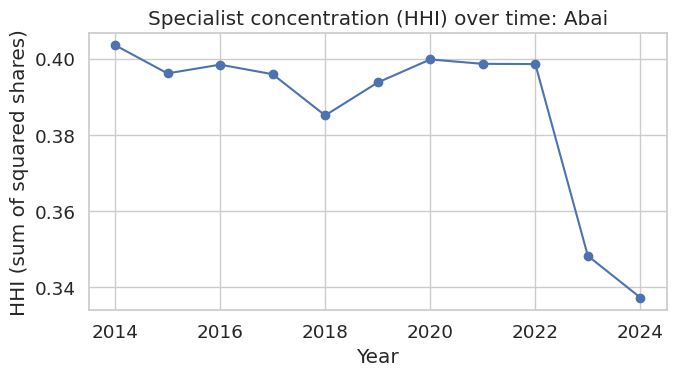

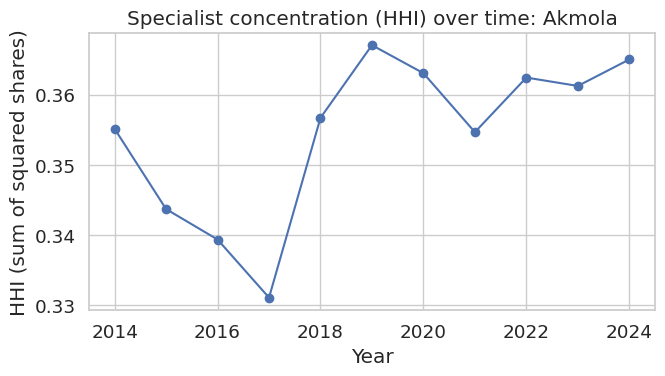

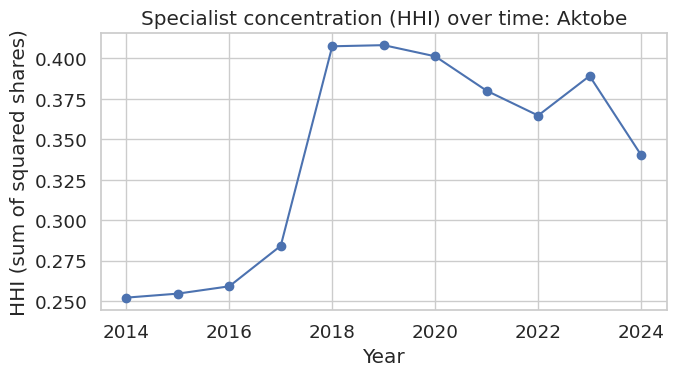

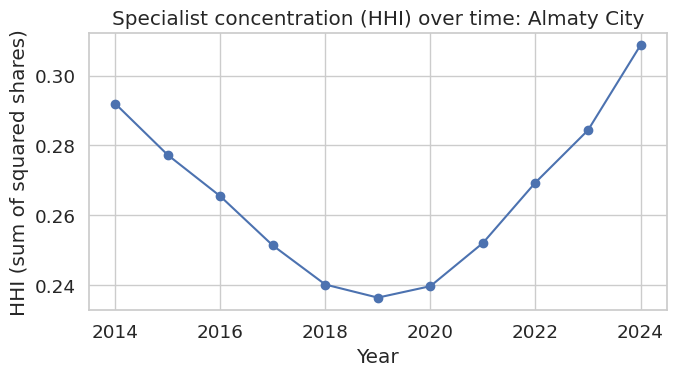

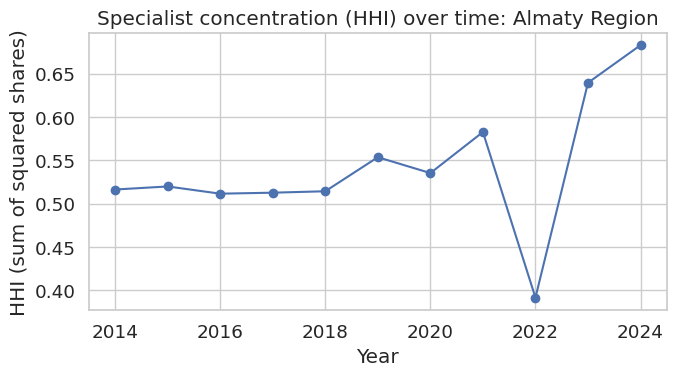

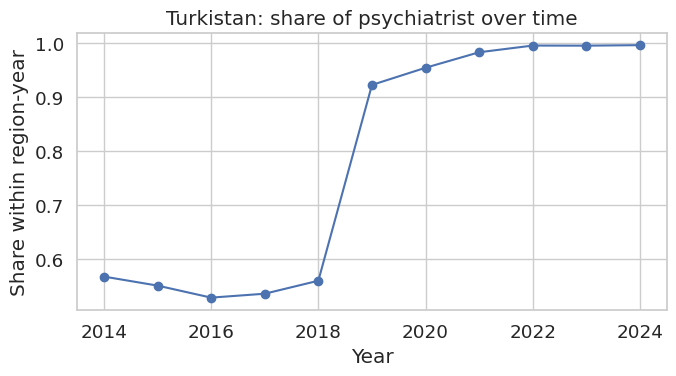

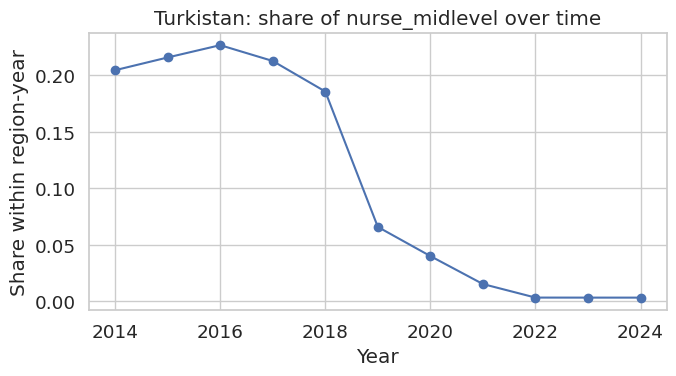

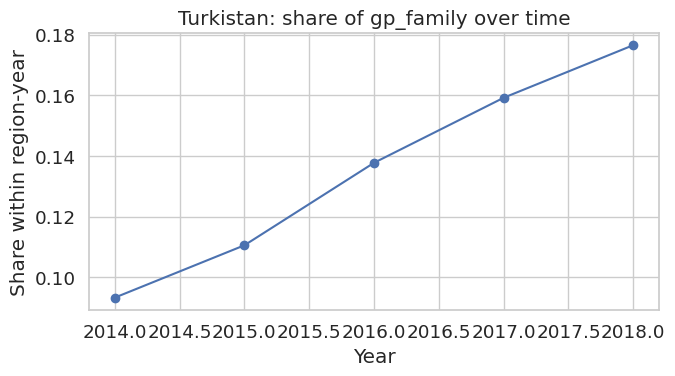

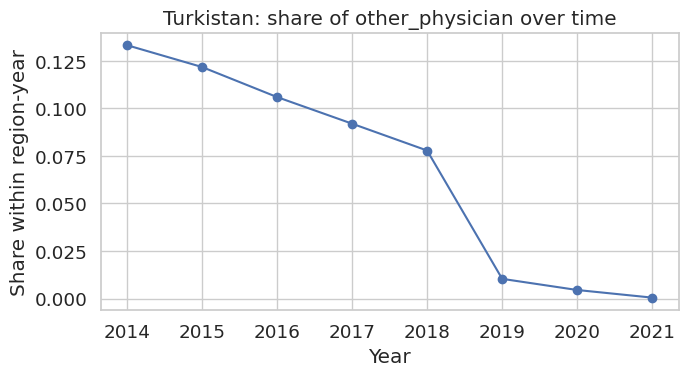

In [ ]:
# Specialist types by region over time:
# 1) counts + within-region shares per year
# 2) change metrics (slope of share vs year)
# 3) quick plots (optional)

# ---- CONFIG ----
YEAR_COL = "registry_year"
REGION_COL = "region_std"
SPEC_COL = "specialist_group"   # or "spec3" if you use collapsed groups

# Optionally restrict to children only
# df_use = df[df["age_exam_reported"] < 18].copy()
df_use = df.copy()

# ---- 1) Counts per year-region-specialist ----
counts = (
    df_use.groupby([YEAR_COL, REGION_COL, SPEC_COL])
          .size()
          .rename("n")
          .reset_index()
)

# ---- 2) Within-region share of each specialist per year ----
region_totals = (
    counts.groupby([YEAR_COL, REGION_COL])["n"]
          .sum()
          .rename("n_region_total")
          .reset_index()
)

shares = counts.merge(region_totals, on=[YEAR_COL, REGION_COL], how="left")
shares["share"] = shares["n"] / shares["n_region_total"]

# ---- 3) Concentration in each region-year: Herfindahl index (optional, descriptive) ----
# Higher = region dominated by fewer specialist types.
hhi = (
    shares.assign(share_sq=lambda x: x["share"] ** 2)
          .groupby([YEAR_COL, REGION_COL])["share_sq"]
          .sum()
          .rename("HHI_specialist_concentration")
          .reset_index()
)

# ---- 4) Trend in specialist share within each region (slope b of share ~ year) ----
def slope_share(g):
    # require >=3 time points for stability
    if g[YEAR_COL].nunique() < 3:
        return pd.Series({"b_share_per_year": np.nan, "n_years": g[YEAR_COL].nunique()})

    x = g[YEAR_COL].values.astype(float)
    y = g["share"].values.astype(float)
    # simple OLS slope
    b = np.polyfit(x, y, 1)[0]
    return pd.Series({"b_share_per_year": b, "n_years": g[YEAR_COL].nunique()})

trend = (
    shares.groupby([REGION_COL, SPEC_COL])
          .apply(slope_share)
          .reset_index()
)

# ---- 5) Identify strongest region-specialist pairings (overall) ----
overall = (
    df_use.groupby([REGION_COL, SPEC_COL]).size().rename("n").reset_index()
)
overall["share_within_region_all_years"] = (
    overall["n"] / overall.groupby(REGION_COL)["n"].transform("sum")
)

top_pairs = overall.sort_values(["share_within_region_all_years"], ascending=False).head(25)

# ---- 6) Wide table for heatmap-like inspection (shares) ----
# Each row: region-year, each column: specialist share
shares_wide = (
    shares.pivot_table(
        index=[YEAR_COL, REGION_COL],
        columns=SPEC_COL,
        values="share",
        fill_value=0.0
    )
    .reset_index()
)

# ---- OUTPUTS ----
# shares: long table with n and share
# hhi: concentration index per region-year
# trend: share trend per region-specialist (b per year)
# top_pairs: strongest region-specialist pairings overall
# shares_wide: ready for heatmap / inspection

print("shares head:\n", shares.head())
print("\nHHI head:\n", hhi.head())
print("\ntrend head:\n", trend.head())
print("\nTop region-specialist pairings:\n", top_pairs.head())

# ---- OPTIONAL QUICK PLOTS (matplotlib, no fixed colors) ----
import matplotlib.pyplot as plt

# A) Plot HHI over years for a few regions (choose any)
example_regions = shares[REGION_COL].dropna().unique()[:5]
tmp = hhi[hhi[REGION_COL].isin(example_regions)].copy()

for r in example_regions:
    g = tmp[tmp[REGION_COL] == r].sort_values(YEAR_COL)
    plt.figure(figsize=(7, 4))
    plt.plot(g[YEAR_COL], g["HHI_specialist_concentration"], marker="o")
    plt.title(f"Specialist concentration (HHI) over time: {r}")
    plt.xlabel("Year")
    plt.ylabel("HHI (sum of squared shares)")
    plt.tight_layout()
    plt.show()

# B) Plot specialist share over years for one region (pick one) and top 4 specialists
region_pick = df_use[REGION_COL].dropna().unique()[0]
g = shares[shares[REGION_COL] == region_pick].copy()
top_specs = (
    g.groupby(SPEC_COL)["n"].sum().sort_values(ascending=False).head(4).index.tolist()
)

for sp in top_specs:
    gg = g[g[SPEC_COL] == sp].sort_values(YEAR_COL)
    plt.figure(figsize=(7, 4))
    plt.plot(gg[YEAR_COL], gg["share"], marker="o")
    plt.title(f"{region_pick}: share of {sp} over time")
    plt.xlabel("Year")
    plt.ylabel("Share within region-year")
    plt.tight_layout()
    plt.show()


In [ ]:
# ---- Region–year specialist composition ----
spec_counts = (
    df.groupby(["registry_year", "region_std", "specialist_group"])
      .size()
      .rename("n")
      .reset_index()
)

region_year_totals = (
    spec_counts.groupby(["registry_year", "region_std"])["n"]
    .sum()
    .rename("n_total")
    .reset_index()
)

spec_shares = spec_counts.merge(
    region_year_totals,
    on=["registry_year", "region_std"],
    how="left"
)

spec_shares["share"] = spec_shares["n"] / spec_shares["n_total"]

# Pivot to wide: one column per specialist share
spec_shares_wide = (
    spec_shares.pivot_table(
        index=["registry_year", "region_std"],
        columns="specialist_group",
        values="share",
        fill_value=0.0
    )
    .reset_index()
)

# Optional: keep only major specialist types
KEEP_SPECS = ["psychiatrist", "neurologist", "psychologist"]
spec_shares_wide = spec_shares_wide[
    ["registry_year", "region_std"] +
    [c for c in KEEP_SPECS if c in spec_shares_wide.columns]
]


In [ ]:
model_base = (
    df
    .loc[df["age_exam_reported"] < 18]   # children only
    .dropna(subset=[
        "registry_year",
        "region_std",
        "age_at_diag_final",
        "sex_std",
        "SES_group",
        "location_type",
        "specialist_group",
        "disorder_mlm",
    ])
    .copy()
)

# Center numerics (again, explicit is good)
model_base["year_c"] = (
    model_base["registry_year"]
    - model_base["registry_year"].mean()
)

model_base["age_at_diag_c"] = (
    model_base["age_at_diag_final"]
    - model_base["age_at_diag_final"].mean()
)

print("model_base N:", len(model_base))


model_base N: 247967


In [ ]:
data_env = model_base.merge(
    spec_shares_wide,
    on=["registry_year", "region_std"],
    how="left"
)

# Center specialist shares (recommended)
for c in KEEP_SPECS:
    if c in data_env.columns:
        data_env[f"{c}_c"] = data_env[c] - data_env[c].mean()


In [ ]:
sampling_plan = {
    "asd": {"k": 5, "max_cases": None},
    "adhd": {"k": 10, "max_cases": None},
    "developmental_disorder": {"k": 5, "max_cases": None},
    "intellectual_disability": {"k": 2, "max_cases": 50000},  # key speed-up
}

def sample_case_control(df, outcome_col="y", controls_per_case=5, max_cases=None, random_state=42):
    cases = df[df[outcome_col] == 1]
    controls = df[df[outcome_col] == 0]

    if max_cases is not None and len(cases) > max_cases:
        cases = cases.sample(n=max_cases, random_state=random_state)

    n_controls_target = min(len(controls), controls_per_case * len(cases))
    sampled_controls = controls.sample(n=n_controls_target, random_state=random_state)

    out = pd.concat([cases, sampled_controls], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out

def make_binary_outcome(df, disorder_name):
    df = df.copy()
    df["y"] = (df["disorder_mlm"] == disorder_name).astype(int)
    return df

formula = (
    "y ~ year_c + age_at_diag_c + sex_std + SES_group + location_type "
    "+ (1|region_std) + (1|specialist_group)"
)

models, idatas = {}, {}

for disorder, cfg in sampling_plan.items():
    print(f"\n=== MLM for {disorder} (children-only) ===")

    df_d = make_binary_outcome(model_base, disorder)
    n_cases = int(df_d["y"].sum())
    print("Cases (full children-only):", n_cases)
    if n_cases < 50:
        print("Skipping (too few).")
        continue

    df_s = sample_case_control(
        df_d,
        outcome_col="y",
        controls_per_case=cfg["k"],
        max_cases=cfg["max_cases"],
        random_state=42,
    )


=== MLM for asd (children-only) ===
Cases (full children-only): 46353

=== MLM for adhd (children-only) ===
Cases (full children-only): 2584

=== MLM for developmental_disorder (children-only) ===
Cases (full children-only): 38279

=== MLM for intellectual_disability (children-only) ===
Cases (full children-only): 160751


In [ ]:
# ---- SWITCH HERE ----
TARGET = "adhd"  # "adhd", "intellectual_disability", "developmental_disorder"

fit_fast = dict(draws=300, tune=300, chains=2, cores=2, target_accept=0.9, random_seed=42)
fit_final = dict(draws=800, tune=800, chains=2, cores=2, target_accept=0.9, random_seed=42)

# Binary outcome
df_d = make_binary_outcome(data_env, TARGET)
print("Cases:", int(df_d["y"].sum()))

# Sampling
df_s = sample_case_control(
    df_d,
    outcome_col="y",
    controls_per_case=5,
    max_cases=None,
    random_state=42,
)

# Formula with specialist environment
formula_env = (
    "y ~ year_c + age_at_diag_c + sex_std + SES_group + location_type "
    "+ psychiatrist_c + neurologist_c + psychologist_c "
    "+ (1 | region_std)"
)

model_env = bmb.Model(
    formula=formula_env,
    data=df_s,
    family="bernoulli",
)

idata_env = model_env.fit(**fit_final)


Cases: 2584


Output()

In [ ]:
def extract_fixed_table_env(idata, disorder):
    summ = az.summary(
        idata,
        var_names=[
            "year_c",
            "age_at_diag_c",
            "sex_std",
            "SES_group",
            "location_type",
            "psychiatrist_c",
            "neurologist_c",
            "psychologist_c",
        ],
        hdi_prob=0.95,
    ).reset_index().rename(columns={"index": "term"})

    summ["OR"] = np.exp(summ["mean"])
    summ["OR_low"] = np.exp(summ["hdi_2.5%"])
    summ["OR_high"] = np.exp(summ["hdi_97.5%"])

    summ["OR (95% CrI)"] = summ.apply(
        lambda r: f"{r.OR:.2f} ({r.OR_low:.2f}, {r.OR_high:.2f})",
        axis=1
    )

    summ["Disorder"] = disorder.upper()

    return summ[
        ["Disorder", "term", "OR (95% CrI)", "ess_bulk", "r_hat"]
    ]

fixed_env_table = extract_fixed_table_env(idata_env, TARGET)
fixed_env_table


,Disorder,term,OR (95% CrI),ess_bulk,r_hat
0,ADHD,year_c,"0.89 (0.87, 0.92)",1223.0,1.00
1,ADHD,age_at_diag_c,"1.04 (1.02, 1.06)",2063.0,1.01
2,ADHD,sex_std[Male],"2.41 (2.17, 2.71)",1973.0,1.00
3,ADHD,SES_group[Employed household],"1.90 (0.76, 4.28)",1533.0,1.00
4,ADHD,SES_group[Other],"0.80 (0.71, 0.91)",1648.0,1.00
5,ADHD,SES_group[Retired/other adult],"0.92 (0.14, 6.96)",1839.0,1.01
6,ADHD,SES_group[School-age],"1.73 (1.50, 1.99)",1196.0,1.00
7,ADHD,SES_group[Unemployed household],"0.25 (0.14, 0.41)",1940.0,1.00
8,ADHD,SES_group[Vulnerable],"0.34 (0.07, 1.60)",1654.0,1.00
9,ADHD,location_type[rural],"0.89 (0.76, 1.04)",1433.0,1.00


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

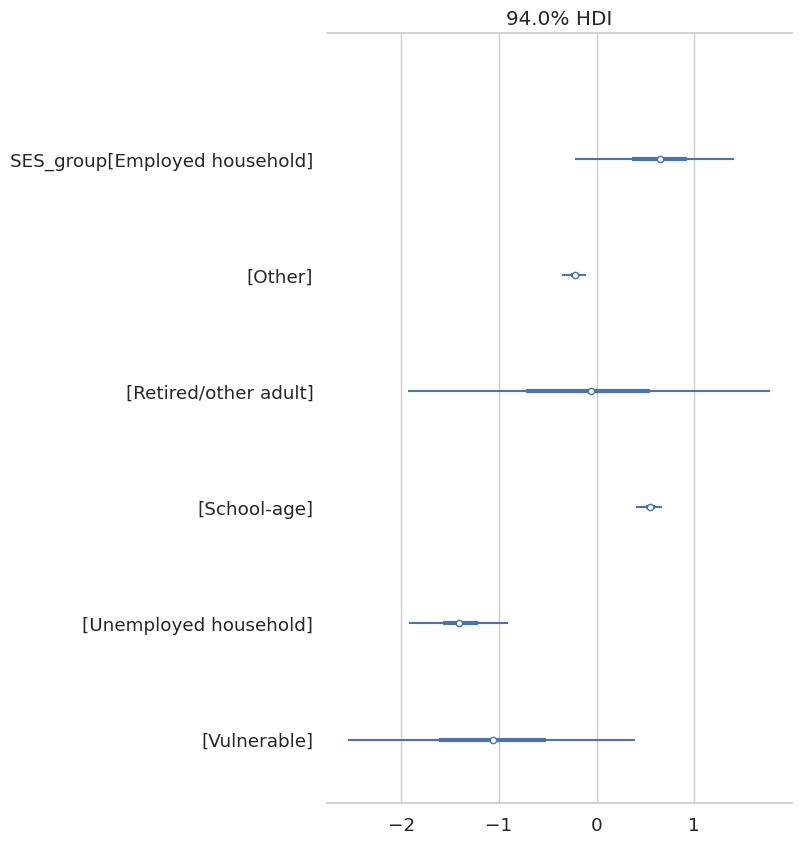

In [ ]:
az.plot_forest(
    idata_env,
    var_names=["SES_group"],
    combined=True,
    figsize=(6, 10),
)


In [ ]:
fixed_env_table.to_excel(f"mlm_env_fixed_effects_{TARGET}.xlsx", index=False)

from google.colab import files
files.download("mlm_env_fixed_effects_asd.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>